In [ ]:
from pathlib import Path
import json
import re
import sys
import unicodedata
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression
from sklearn.metrics import balanced_accuracy_score, silhouette_score
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "src").exists() and (candidate / "README.md").exists():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break

from src.config import PROJECT_ROOT, ensure_default_directories
from src.utils import clean_country_code
from src.validation import assert_exported, assert_non_empty, assert_required_columns

ensure_default_directories()

FINAL_ANALYSIS_DIR = PROJECT_ROOT / "7 Final Analysis"
COUNTRY_DIR = PROJECT_ROOT / "6 Country level variables"
LLM_WIKIPEDIA_DIR = PROJECT_ROOT / "5 LLM Wikipedia analysis"
OUTPUTS_DIR = FINAL_ANALYSIS_DIR / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures"
TABLES_DIR = OUTPUTS_DIR / "tables"

for folder in [OUTPUTS_DIR, FIGURES_DIR, TABLES_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

DEMOGRAPHY_PATH_CANDIDATES = [
    COUNTRY_DIR / "outputs" / "tables" / "demography_country_year.csv",
    COUNTRY_DIR / "demography_country_year.csv",
]
EXTRACTED_POLARISATION_PATH_CANDIDATES = [
    LLM_WIKIPEDIA_DIR / "outputs" / "tables" / "extracted_polarisation_final.xlsx",
    LLM_WIKIPEDIA_DIR / "extracted_polarisation_final.xlsx",
]

DEMOGRAPHY_PATH = next((p for p in DEMOGRAPHY_PATH_CANDIDATES if p.exists()), DEMOGRAPHY_PATH_CANDIDATES[0])
EXTRACTED_POLARISATION_PATH = next((p for p in EXTRACTED_POLARISATION_PATH_CANDIDATES if p.exists()), EXTRACTED_POLARISATION_PATH_CANDIDATES[0])
MERGED_OUTPUT_PATH = TABLES_DIR / "polarisation_with_demography.xlsx"

assert DEMOGRAPHY_PATH.exists(), f"Demography file missing: {DEMOGRAPHY_PATH}"
assert EXTRACTED_POLARISATION_PATH.exists(), f"Extraction file missing: {EXTRACTED_POLARISATION_PATH}"

print(f"Project root: {PROJECT_ROOT}")
print(f"Demography file: {DEMOGRAPHY_PATH}")
print(f"Extraction file: {EXTRACTED_POLARISATION_PATH}")
print(f"Tables dir: {TABLES_DIR}")

Project root: C:\Users\Gebruiker\OneDrive - Università Commerciale Luigi Bocconi\Master 2\Semester I\Population dynamics and economics\Group work\Population\Analysis Population Dynamics
Demography file: C:\Users\Gebruiker\OneDrive - Università Commerciale Luigi Bocconi\Master 2\Semester I\Population dynamics and economics\Group work\Population\Analysis Population Dynamics\6 Country level variables\outputs\tables\demography_country_year.csv
Extraction file: C:\Users\Gebruiker\OneDrive - Università Commerciale Luigi Bocconi\Master 2\Semester I\Population dynamics and economics\Group work\Population\Analysis Population Dynamics\5 LLM Wikipedia analysis\outputs\tables\extracted_polarisation_final.xlsx
Tables dir: C:\Users\Gebruiker\OneDrive - Università Commerciale Luigi Bocconi\Master 2\Semester I\Population dynamics and economics\Group work\Population\Analysis Population Dynamics\7 Final Analysis\outputs\tables


# Final Regression Analysis

This notebook combines cleaned MEP-level extraction outputs with country-level variables and runs descriptive and regression analyses.

Run from top to bottom. Paths are configured once in the next cell for portability and future GitHub use.

What this section does:
- Clarifies the purpose of this section and how it connects to the next steps.
- Summarizes expected inputs and outputs to make reruns easier to follow.


## Data loading and merge setup

This section prepares the two main source files and builds the merged analysis dataset:
1. Country-year demography panel.
2. Final extracted MEP-level polarisation file.

What this section does:
- Clarifies the purpose of this section and how it connects to the next steps.
- Summarizes expected inputs and outputs to make reruns easier to follow.


In [2]:
demography_country_year = pd.read_csv(DEMOGRAPHY_PATH)
copy_extracted_polarisation_final = pd.read_excel(EXTRACTED_POLARISATION_PATH)

assert_non_empty(demography_country_year, "demography_country_year")
assert_non_empty(copy_extracted_polarisation_final, "copy_extracted_polarisation_final")
assert_required_columns(demography_country_year, ["country"], "demography_country_year")
assert_required_columns(copy_extracted_polarisation_final, ["Country"], "copy_extracted_polarisation_final")

year_col = next((c for c in ["year", "Year", "YEAR"] if c in demography_country_year.columns), None)
if year_col is None:
    raise ValueError(f"Could not find a year column in demography_country_year. Columns: {list(demography_country_year.columns)}")

demography_2010_2025 = demography_country_year[
    demography_country_year[year_col].between(2010, 2025, inclusive="both")
].copy()
assert_non_empty(demography_2010_2025, "demography_2010_2025")

demography_country_year["country_clean"] = demography_country_year["country"].map(clean_country_code)
copy_extracted_polarisation_final["country_clean"] = copy_extracted_polarisation_final["Country"].map(clean_country_code)

numeric_cols = demography_2010_2025.select_dtypes(include="number").columns.tolist()
numeric_cols = [c for c in numeric_cols if c != year_col]

if not numeric_cols:
    raise ValueError("No numeric demography columns found for averaging.")

# Groupby mean uses available observations and ignores NaN values by default.
demography_country_avg = (
    demography_2010_2025.assign(country_clean=demography_2010_2025["country"].map(clean_country_code))
    .groupby("country_clean", as_index=False)[numeric_cols]
    .mean(numeric_only=True)
)
assert_non_empty(demography_country_avg, "demography_country_avg")

dup_left = copy_extracted_polarisation_final.duplicated(["country_clean"]).sum()
dup_right = demography_country_avg.duplicated(["country_clean"]).sum()

left_before = len(copy_extracted_polarisation_final)
merge_probe = copy_extracted_polarisation_final.merge(
    demography_country_avg,
    on="country_clean",
    how="left",
    indicator=True,
)

matched = int((merge_probe["_merge"] == "both").sum())
left_only = int((merge_probe["_merge"] == "left_only").sum())
rows_lost = left_before - matched
rows_lost_pct = (rows_lost / left_before * 100.0) if left_before else 0.0

unmatched_countries = sorted(
    merge_probe.loc[merge_probe["_merge"] == "left_only", "country_clean"]
    .dropna()
    .astype(str)
    .unique()
    .tolist()
)

display(pd.DataFrame([
    {
        "rows_before_merge": left_before,
        "rows_after_merge": len(merge_probe),
        "matched_rows": matched,
        "unmatched_rows": left_only,
        "rows_lost_vs_matched": rows_lost,
        "rows_lost_pct": round(rows_lost_pct, 3),
        "duplicate_keys_left_country_clean": int(dup_left),
        "duplicate_keys_right_country_clean": int(dup_right),
        "n_unmatched_countries": len(unmatched_countries),
    }
]))

if unmatched_countries:
    print("Unmatched countries (country_clean):", unmatched_countries)

polarisation_with_demography = merge_probe.drop(columns=["_merge"])
assert_non_empty(polarisation_with_demography, "polarisation_with_demography")

print("demography_country_year:", demography_country_year.shape)
print("demography_2010_2025:", demography_2010_2025.shape)
print("demography_country_avg:", demography_country_avg.shape)
print("copy_extracted_polarisation_final:", copy_extracted_polarisation_final.shape)
print("polarisation_with_demography:", polarisation_with_demography.shape)

,rows_before_merge,rows_after_merge,matched_rows,unmatched_rows,rows_lost_vs_matched,rows_lost_pct,duplicate_keys_left_country_clean,duplicate_keys_right_country_clean,n_unmatched_countries
0,158,158,157,1,1,0.633,130,0,1


Unmatched countries (country_clean): ['nan']
demography_country_year: (3873, 19)
demography_2010_2025: (448, 18)
demography_country_avg: (28, 17)
copy_extracted_polarisation_final: (158, 88)
polarisation_with_demography: (158, 104)


In [26]:

# Filter to MEP-only rows for downstream analysis.
if "MEP" not in polarisation_with_demography.columns:
    raise ValueError("Could not find a MEP column in the merged dataframe.")

mep_only_polarisation_with_demography = polarisation_with_demography.loc[
    polarisation_with_demography["MEP"].astype(str).str.upper().eq("TRUE")
].copy()

analysis_df = mep_only_polarisation_with_demography.copy()

print("MEP-only dataframe shape:", mep_only_polarisation_with_demography.shape)
print("Rows retained:", len(mep_only_polarisation_with_demography))

MEP-only dataframe shape: (0, 98)
Rows retained: 0


In [3]:
# Rebuild the analysis dataframe in an idempotent way.
# If the MEP flag is unusable, fall back to the full merged dataset instead of collapsing to zero rows.

if "polarisation_with_demography" not in globals():
    raise RuntimeError("polarisation_with_demography is missing. Run the merge cell first.")

mep_candidate = polarisation_with_demography.copy()

if "MEP" in mep_candidate.columns:
    mep_mask = mep_candidate["MEP"].astype(str).str.strip().str.upper().isin(["TRUE", "1", "YES", "Y"])
    mep_only_polarisation_with_demography = mep_candidate.loc[mep_mask].copy()
    if mep_only_polarisation_with_demography.empty:
        print("MEP filter produced 0 rows; using the full merged dataset instead.")
        mep_only_polarisation_with_demography = mep_candidate.copy()
else:
    print("MEP column not found; using the full merged dataset.")
    mep_only_polarisation_with_demography = mep_candidate.copy()

analysis_df = mep_only_polarisation_with_demography.copy()

# Preserve a couple of compatibility columns expected later in the notebook.
if "country_clean" in analysis_df.columns and "country_clean_final" not in analysis_df.columns:
    analysis_df["country_clean_final"] = analysis_df["country_clean"]
elif "Country" in analysis_df.columns and "country_clean_final" not in analysis_df.columns:
    analysis_df["country_clean_final"] = analysis_df["Country"]

if "region_bucket" in analysis_df.columns and "region_clean" not in analysis_df.columns:
    region_map = {
        "eastern europe": "Central & Eastern Europe",
        "central and eastern europe": "Central & Eastern Europe",
        "central & eastern europe": "Central & Eastern Europe",
        "baltic": "Baltic",
        "northern europe": "Northern Europe",
        "western europe": "Western Europe",
        "southern europe": "Southern Europe",
    }
    norm_region = analysis_df["region_bucket"].map(lambda v: "" if pd.isna(v) else str(v).strip().lower())
    analysis_df["region_clean"] = norm_region.map(region_map).fillna(analysis_df["region_bucket"])

if "ep_group_extracted" in analysis_df.columns:
    def _normalize_ep_group_text(value):
        if pd.isna(value):
            return ""
        text = str(value).strip()
        text = text.replace("&", " and ")
        text = unicodedata.normalize("NFKD", text).encode("ascii", "ignore").decode("ascii")
        text = text.lower()
        text = re.sub(r"[\\/_.(),;:+\-]+", " ", text)
        text = re.sub(r"\s+", " ", text).strip()
        return text

    ep_group_rules = [
        ("EPP", [r"\bepp\b", r"\bppe\b", r"european people'?s party", r"christian democrats"]),
        ("S&D", [r"s and d", r"progressive alliance of socialists and democrats", r"socialists and democrats", r"socialist group"]),
        ("Renew/ALDE", [r"\balde\b", r"renew europe", r"liberal democrats"]),
        ("Greens/EFA", [r"greens efa", r"greens european free alliance"]),
        ("ECR", [r"\becr\b", r"european conservatives and reformists"]),
        ("The Left/GUE-NGL", [r"gue ngl", r"european united left", r"the left"]),
        ("ID/ENF/PfE", [r"\benf\b", r"identity and democracy", r"patriots for europe"]),
        ("EFD/EFDD", [r"europe of freedom and direct democracy", r"\befd\b", r"\befdd\b"]),
        ("Non-Inscrits", [r"non inscrit", r"non inscript", r"non inscrits", r"non attached", r"non-attached"]),
    ]

    def _clean_ep_group(value):
        original_label = "" if pd.isna(value) else str(value).strip()
        normalized = _normalize_ep_group_text(value)
        if not normalized:
            return "Unknown"
        for canonical_label, patterns in ep_group_rules:
            for pattern in patterns:
                if re.search(pattern, normalized, flags=re.IGNORECASE):
                    return canonical_label
        return original_label

    analysis_df["ep_group_clean"] = analysis_df["ep_group_extracted"].map(_clean_ep_group)

sample_tracking = pd.DataFrame([
    {"step": "merged_raw", "n_rows": len(polarisation_with_demography)},
    {"step": "analysis_ready", "n_rows": len(analysis_df)},
])

display(sample_tracking)
print("analysis_df shape:", analysis_df.shape)
print("Rows with polarisation_score:", int(analysis_df["polarisation_score"].notna().sum()) if "polarisation_score" in analysis_df.columns else 0)
print("Rows with ep_group_extracted:", int(analysis_df["ep_group_extracted"].notna().sum()) if "ep_group_extracted" in analysis_df.columns else 0)


,step,n_rows
0,merged_raw,158
1,analysis_ready,139


analysis_df shape: (139, 107)
Rows with polarisation_score: 139
Rows with ep_group_extracted: 118


In [4]:

# Additional dataframe cleaning with safe rerun behavior.
# This cell preserves original columns and creates new *_clean / *_flag columns.


created_columns = []
summary_rows = []


def _add_summary(original_column, new_column, status, before_unique=np.nan, after_unique=np.nan):
    summary_rows.append(
        {
            "original_column": original_column,
            "new_column": new_column,
            "status": status,
            "number_unique_before": before_unique,
            "number_unique_after": after_unique,
        }
    )


def _norm_text(value):
    if pd.isna(value):
        return ""
    text = str(value).strip().lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


# 1) Country cleaning
country_base_col = "country_clean" if "country_clean" in analysis_df.columns else ("Country" if "Country" in analysis_df.columns else None)

if country_base_col is not None:
    country_alias = {
        "sp": "es",
        "es": "es",
        "sw": "se",
        "se": "se",
        "gr": "el",
        "el": "el",
        "greece": "el",
        "spain": "es",
        "sweden": "se",
    }

    known_country_codes = {
        "at", "be", "bg", "cy", "cz", "de", "dk", "ee", "el", "es", "fi", "fr", "hr", "hu", "ie", "it",
        "lt", "lu", "lv", "mt", "nl", "pl", "pt", "ro", "se", "si", "sk", "gb"
    }

    before_counts = (
        analysis_df[country_base_col]
        .fillna("<NA>")
        .astype(str)
        .str.strip()
        .value_counts(dropna=False)
        .rename_axis("value")
        .reset_index(name="count")
    )
    print("\n[Country] Counts before cleaning:")
    display(before_counts)

    def _clean_country(value):
        token = _norm_text(value)
        if token == "":
            return np.nan
        if token in country_alias:
            return country_alias[token]
        if len(token) == 2 and token.isalpha():
            return token
        return token

    analysis_df["country_clean_final"] = analysis_df[country_base_col].map(_clean_country)
    created_columns.append("country_clean_final")

    if "Country" in analysis_df.columns and "country_clean" in analysis_df.columns:
        left = analysis_df["Country"].map(_clean_country)
        right = analysis_df["country_clean"].map(_clean_country)
        mismatch_mask = left.notna() & right.notna() & (left != right)
        mismatch_n = int(mismatch_mask.sum())
        print(f"[Country] Merge alignment check (Country vs country_clean): {mismatch_n} mismatched non-null rows")
        if mismatch_n > 0:
            mismatch_preview = analysis_df.loc[mismatch_mask, ["Country", "country_clean", "country_clean_final"]].head(20)
            display(mismatch_preview)

    after_counts = (
        analysis_df["country_clean_final"]
        .fillna("<NA>")
        .astype(str)
        .value_counts(dropna=False)
        .rename_axis("value")
        .reset_index(name="count")
    )
    print("[Country] Counts after cleaning:")
    display(after_counts)

    unresolved = (
        analysis_df["country_clean_final"]
        .dropna()
        .astype(str)
        .str.strip()
        .loc[lambda s: ~s.isin(known_country_codes)]
        .value_counts()
        .rename_axis("unresolved_value")
        .reset_index(name="count")
    )
    print("[Country] Values not confidently standardised:")
    if unresolved.empty:
        print("None")
    else:
        display(unresolved)

    _add_summary(
        country_base_col,
        "country_clean_final",
        "created",
        analysis_df[country_base_col].nunique(dropna=True),
        analysis_df["country_clean_final"].nunique(dropna=True),
    )
else:
    print("\n[Country] Skipped: neither 'country_clean' nor 'Country' is present.")
    _add_summary("country_clean|Country", "country_clean_final", "skipped_missing_source")


# 2) Region cleaning
if "region_bucket" in analysis_df.columns:
    region_map = {
        "eastern europe": "Central & Eastern Europe",
        "central and eastern europe": "Central & Eastern Europe",
        "central & eastern europe": "Central & Eastern Europe",
        "baltic": "Baltic",
        "northern europe": "Northern Europe",
        "western europe": "Western Europe",
        "southern europe": "Southern Europe",
    }

    print("\n[Region] Counts before cleaning:")
    display(analysis_df["region_bucket"].fillna("<NA>").value_counts(dropna=False).rename_axis("value").reset_index(name="count"))

    norm_region = analysis_df["region_bucket"].map(_norm_text)
    analysis_df["region_clean"] = np.where(
        norm_region.eq(""),
        np.nan,
        norm_region.map(region_map).fillna(analysis_df["region_bucket"]),
    )
    created_columns.append("region_clean")

    unmatched_region = (
        pd.Series(norm_region.unique())
        .dropna()
        .loc[lambda s: (s != "") & (~s.isin(region_map.keys()))]
        .sort_values()
        .reset_index(drop=True)
    )
    print("[Region] Unmatched values (left unchanged):")
    if len(unmatched_region) == 0:
        print("None")
    else:
        display(unmatched_region.to_frame("unmatched_region"))

    print("[Region] Counts after cleaning:")
    display(analysis_df["region_clean"].fillna("<NA>").value_counts(dropna=False).rename_axis("value").reset_index(name="count"))

    _add_summary(
        "region_bucket",
        "region_clean",
        "created",
        analysis_df["region_bucket"].nunique(dropna=True),
        analysis_df["region_clean"].nunique(dropna=True),
    )
else:
    print("\n[Region] Skipped: 'region_bucket' not present.")
    _add_summary("region_bucket", "region_clean", "skipped_missing_source")


# 3) Dominant topic cleaning
if "dominant_cluster" in analysis_df.columns:
    analysis_df["dominant_topic"] = analysis_df["dominant_cluster"].copy()
    created_columns.append("dominant_topic")
    print("\n[Dominant Topic] Counts for dominant_topic:")
    display(analysis_df["dominant_topic"].fillna("<NA>").value_counts(dropna=False).rename_axis("value").reset_index(name="count"))

    _add_summary(
        "dominant_cluster",
        "dominant_topic",
        "created",
        analysis_df["dominant_cluster"].nunique(dropna=True),
        analysis_df["dominant_topic"].nunique(dropna=True),
    )
else:
    print("\n[Dominant Topic] Skipped: 'dominant_cluster' not present.")
    _add_summary("dominant_cluster", "dominant_topic", "skipped_missing_source")

if "dominant_cluster_score" in analysis_df.columns:
    s = analysis_df["dominant_cluster_score"]
    non_null = s.notna().sum()
    numeric_share = pd.to_numeric(s, errors="coerce").notna().mean() if non_null > 0 else 1.0
    if non_null > 0 and numeric_share < 0.7:
        print("[Dominant Topic] WARNING: dominant_cluster_score appears to contain text labels and may be mislabelled; do not treat as numeric.")


# 4) Professional background consolidation
if "professional_background_bucket" in analysis_df.columns:
    pb_map = {
        "public administration": "Politics / Public Administration",
        "career politician": "Politics / Public Administration",
        "academia or research": "Academia / Education",
        "education sector": "Academia / Education",
        "business or finance": "Business / Finance",
        "journalism or media": "Media / Journalism",
        "law": "Law",
        "health sector": "Other / Specialist",
        "ngo or civil society": "Other / Specialist",
        "other or unclear": "Other / Unclear",
    }

    print("\n[Professional Background] Counts before cleaning:")
    display(analysis_df["professional_background_bucket"].fillna("<NA>").value_counts(dropna=False).rename_axis("value").reset_index(name="count"))

    pb_norm = analysis_df["professional_background_bucket"].map(_norm_text)
    analysis_df["professional_background_clean"] = np.where(
        pb_norm.eq(""),
        np.nan,
        pb_norm.map(pb_map).fillna(analysis_df["professional_background_bucket"]),
    )
    created_columns.append("professional_background_clean")

    unmatched_pb = (
        pd.Series(pb_norm.unique())
        .dropna()
        .loc[lambda s: (s != "") & (~s.isin(pb_map.keys()))]
        .sort_values()
        .reset_index(drop=True)
    )
    print("[Professional Background] Unmatched values (left unchanged):")
    if len(unmatched_pb) == 0:
        print("None")
    else:
        display(unmatched_pb.to_frame("unmatched_professional_background"))

    print("[Professional Background] Counts after cleaning:")
    display(analysis_df["professional_background_clean"].fillna("<NA>").value_counts(dropna=False).rename_axis("value").reset_index(name="count"))

    _add_summary(
        "professional_background_bucket",
        "professional_background_clean",
        "created",
        analysis_df["professional_background_bucket"].nunique(dropna=True),
        analysis_df["professional_background_clean"].nunique(dropna=True),
    )
else:
    print("\n[Professional Background] Skipped: 'professional_background_bucket' not present.")
    _add_summary("professional_background_bucket", "professional_background_clean", "skipped_missing_source")


# 5) International experience flag
if "international_experience_bucket" in analysis_df.columns:
    ie_map = {
        "none significant mentioned": "No",
        "studied abroad": "Yes",
        "worked abroad": "Yes",
        "eu institutional career": "Yes",
    }
    ie_norm = analysis_df["international_experience_bucket"].map(_norm_text)
    analysis_df["international_experience_flag"] = ie_norm.map(ie_map).fillna("Unknown")
    analysis_df.loc[ie_norm.eq(""), "international_experience_flag"] = "Unknown"
    created_columns.append("international_experience_flag")

    print("\n[International Experience] Counts:")
    display(analysis_df["international_experience_flag"].value_counts(dropna=False).rename_axis("value").reset_index(name="count"))

    _add_summary(
        "international_experience_bucket",
        "international_experience_flag",
        "created",
        analysis_df["international_experience_bucket"].nunique(dropna=True),
        analysis_df["international_experience_flag"].nunique(dropna=True),
    )
else:
    print("\n[International Experience] Skipped: 'international_experience_bucket' not present.")
    _add_summary("international_experience_bucket", "international_experience_flag", "skipped_missing_source")


# 6) Migration background flag
if "migration_background_bucket" in analysis_df.columns:
    mb_map = {
        "none mentioned": "No",
        "born abroad": "Yes",
        "parent foreign born": "Yes",
    }
    mb_norm = analysis_df["migration_background_bucket"].map(_norm_text)
    analysis_df["migration_background_flag"] = mb_norm.map(mb_map).fillna("Unknown")
    analysis_df.loc[mb_norm.eq(""), "migration_background_flag"] = "Unknown"
    created_columns.append("migration_background_flag")

    print("\n[Migration Background] Counts:")
    display(analysis_df["migration_background_flag"].value_counts(dropna=False).rename_axis("value").reset_index(name="count"))

    _add_summary(
        "migration_background_bucket",
        "migration_background_flag",
        "created",
        analysis_df["migration_background_bucket"].nunique(dropna=True),
        analysis_df["migration_background_flag"].nunique(dropna=True),
    )
else:
    print("\n[Migration Background] Skipped: 'migration_background_bucket' not present.")
    _add_summary("migration_background_bucket", "migration_background_flag", "skipped_missing_source")


# 7) Military background flag
if "military_background_bucket" in analysis_df.columns:
    mil_map = {
        "not mentioned": "No",
        "yes": "Yes",
    }
    mil_norm = analysis_df["military_background_bucket"].map(_norm_text)
    analysis_df["military_background_flag"] = mil_norm.map(mil_map).fillna("Unknown")
    analysis_df.loc[mil_norm.eq(""), "military_background_flag"] = "Unknown"
    created_columns.append("military_background_flag")

    print("\n[Military Background] Counts:")
    display(analysis_df["military_background_flag"].value_counts(dropna=False).rename_axis("value").reset_index(name="count"))

    _add_summary(
        "military_background_bucket",
        "military_background_flag",
        "created",
        analysis_df["military_background_bucket"].nunique(dropna=True),
        analysis_df["military_background_flag"].nunique(dropna=True),
    )
else:
    print("\n[Military Background] Skipped: 'military_background_bucket' not present.")
    _add_summary("military_background_bucket", "military_background_flag", "skipped_missing_source")


# 8) Parental status caution variables
if "parental_status_bucket" in analysis_df.columns:
    ps_norm = analysis_df["parental_status_bucket"].map(_norm_text)

    analysis_df["parental_status_known"] = "Unknown"
    analysis_df["has_children_if_known"] = "Unknown"

    analysis_df.loc[ps_norm.eq("has children"), ["parental_status_known", "has_children_if_known"]] = ["Yes", "Yes"]
    analysis_df.loc[ps_norm.eq("no children"), ["parental_status_known", "has_children_if_known"]] = ["Yes", "No"]
    analysis_df.loc[ps_norm.eq("not mentioned"), ["parental_status_known", "has_children_if_known"]] = ["No", "Unknown"]

    created_columns.extend(["parental_status_known", "has_children_if_known"])

    print("\n[Parental Status] Counts for parental_status_known:")
    display(analysis_df["parental_status_known"].value_counts(dropna=False).rename_axis("value").reset_index(name="count"))
    print("[Parental Status] Counts for has_children_if_known:")
    display(analysis_df["has_children_if_known"].value_counts(dropna=False).rename_axis("value").reset_index(name="count"))

    _add_summary(
        "parental_status_bucket",
        "parental_status_known",
        "created",
        analysis_df["parental_status_bucket"].nunique(dropna=True),
        analysis_df["parental_status_known"].nunique(dropna=True),
    )
    _add_summary(
        "parental_status_bucket",
        "has_children_if_known",
        "created",
        analysis_df["parental_status_bucket"].nunique(dropna=True),
        analysis_df["has_children_if_known"].nunique(dropna=True),
    )
else:
    print("\n[Parental Status] Skipped: 'parental_status_bucket' not present.")
    _add_summary("parental_status_bucket", "parental_status_known", "skipped_missing_source")
    _add_summary("parental_status_bucket", "has_children_if_known", "skipped_missing_source")


# 9) Religion caution variable
if "religion_bucket" in analysis_df.columns:
    rel_map = {
        "not mentioned": "No",
        "christian": "Yes",
        "other religion": "Yes",
    }
    rel_norm = analysis_df["religion_bucket"].map(_norm_text)
    analysis_df["religion_mentioned_flag"] = rel_norm.map(rel_map).fillna("Unknown")
    analysis_df.loc[rel_norm.eq(""), "religion_mentioned_flag"] = "Unknown"
    created_columns.append("religion_mentioned_flag")

    print("\n[Religion] Counts:")
    display(analysis_df["religion_mentioned_flag"].value_counts(dropna=False).rename_axis("value").reset_index(name="count"))

    _add_summary(
        "religion_bucket",
        "religion_mentioned_flag",
        "created",
        analysis_df["religion_bucket"].nunique(dropna=True),
        analysis_df["religion_mentioned_flag"].nunique(dropna=True),
    )
else:
    print("\n[Religion] Skipped: 'religion_bucket' not present.")
    _add_summary("religion_bucket", "religion_mentioned_flag", "skipped_missing_source")


# 10) Education field consolidation
if "education_field_bucket" in analysis_df.columns:
    edu_map = {
        "law": "Law",
        "economics or business": "Economics / Business",
        "stem": "STEM",
        "political or social sciences": "Politics / Social Sciences",
        "humanities": "Humanities / Education / Health",
        "education or teaching": "Humanities / Education / Health",
        "medicine or health": "Humanities / Education / Health",
        "other or unclear": "Other / Unclear",
    }

    print("\n[Education Field] Counts before cleaning:")
    display(analysis_df["education_field_bucket"].fillna("<NA>").value_counts(dropna=False).rename_axis("value").reset_index(name="count"))

    edu_norm = analysis_df["education_field_bucket"].map(_norm_text)
    analysis_df["education_field_clean"] = np.where(
        edu_norm.eq(""),
        np.nan,
        edu_norm.map(edu_map).fillna(analysis_df["education_field_bucket"]),
    )
    created_columns.append("education_field_clean")

    unmatched_edu = (
        pd.Series(edu_norm.unique())
        .dropna()
        .loc[lambda s: (s != "") & (~s.isin(edu_map.keys()))]
        .sort_values()
        .reset_index(drop=True)
    )
    print("[Education Field] Unmatched values (left unchanged):")
    if len(unmatched_edu) == 0:
        print("None")
    else:
        display(unmatched_edu.to_frame("unmatched_education_field"))

    print("[Education Field] Counts after cleaning:")
    display(analysis_df["education_field_clean"].fillna("<NA>").value_counts(dropna=False).rename_axis("value").reset_index(name="count"))

    _add_summary(
        "education_field_bucket",
        "education_field_clean",
        "created",
        analysis_df["education_field_bucket"].nunique(dropna=True),
        analysis_df["education_field_clean"].nunique(dropna=True),
    )
else:
    print("\n[Education Field] Skipped: 'education_field_bucket' not present.")
    _add_summary("education_field_bucket", "education_field_clean", "skipped_missing_source")


# 11) Optional age and tenure groups
if "age_approx_2020" in analysis_df.columns:
    age_numeric = pd.to_numeric(analysis_df["age_approx_2020"], errors="coerce")
    analysis_df["age_group"] = pd.cut(
        age_numeric,
        bins=[-np.inf, 39, 49, 59, np.inf],
        labels=["Under 40", "40-49", "50-59", "60+"],
    )
    analysis_df["age_group"] = analysis_df["age_group"].astype(object).where(age_numeric.notna(), "Unknown")
    created_columns.append("age_group")

    print("\n[Age Group] Counts:")
    display(analysis_df["age_group"].fillna("Unknown").value_counts(dropna=False).rename_axis("value").reset_index(name="count"))

    _add_summary(
        "age_approx_2020",
        "age_group",
        "created",
        analysis_df["age_approx_2020"].nunique(dropna=True),
        analysis_df["age_group"].nunique(dropna=True),
    )
else:
    print("\n[Age Group] Skipped: 'age_approx_2020' not present.")
    _add_summary("age_approx_2020", "age_group", "skipped_missing_source")

if "mep_tenure_approx_2020" in analysis_df.columns:
    tenure_numeric = pd.to_numeric(analysis_df["mep_tenure_approx_2020"], errors="coerce")
    analysis_df["tenure_group"] = pd.cut(
        tenure_numeric,
        bins=[-np.inf, 5, 10, np.inf],
        labels=["0-5 years", "6-10 years", "11+ years"],
    )
    analysis_df["tenure_group"] = analysis_df["tenure_group"].astype(object).where(tenure_numeric.notna(), "Unknown")
    created_columns.append("tenure_group")

    print("\n[Tenure Group] Counts:")
    display(analysis_df["tenure_group"].fillna("Unknown").value_counts(dropna=False).rename_axis("value").reset_index(name="count"))

    _add_summary(
        "mep_tenure_approx_2020",
        "tenure_group",
        "created",
        analysis_df["mep_tenure_approx_2020"].nunique(dropna=True),
        analysis_df["tenure_group"].nunique(dropna=True),
    )
else:
    print("\n[Tenure Group] Skipped: 'mep_tenure_approx_2020' not present.")
    _add_summary("mep_tenure_approx_2020", "tenure_group", "skipped_missing_source")


# 12) Final cleaning report
cleaning_summary = pd.DataFrame(summary_rows)

print("\n=== Final Cleaning Report ===")
print("Created columns:", sorted(set(created_columns)) if created_columns else "None")
display(cleaning_summary)



[Country] Counts before cleaning:


,value,count
0,pl,14
1,it,13
2,ro,12
3,es,11
4,de,10
5,fr,9
6,pt,7
7,hr,7
8,si,6
9,gb,5


[Country] Merge alignment check (Country vs country_clean): 0 mismatched non-null rows
[Country] Counts after cleaning:


,value,count
0,pl,14
1,it,13
2,ro,12
3,es,11
4,de,10
5,fr,9
6,pt,7
7,hr,7
8,si,6
9,gb,5


[Country] Values not confidently standardised:
None

[Region] Counts before cleaning:


...

,unmatched_education_field
0,political science or public administration
1,sociology or demography or social sciences


[Education Field] Counts after cleaning:


,value,count
0,Economics / Business,26
1,Other / Unclear,26
2,Law,23
3,Humanities / Education / Health,18
4,Political Science or Public Administration,18
5,STEM,17
6,Sociology or Demography or Social Sciences,7
7,<NA>,4



[Age Group] Skipped: 'age_approx_2020' not present.

[Tenure Group] Skipped: 'mep_tenure_approx_2020' not present.

=== Final Cleaning Report ===
Created columns: ['country_clean_final', 'dominant_topic', 'education_field_clean', 'has_children_if_known', 'international_experience_flag', 'migration_background_flag', 'military_background_flag', 'parental_status_known', 'professional_background_clean', 'region_clean', 'religion_mentioned_flag']


,original_column,new_column,status,number_unique_before,number_unique_after
0,country_clean,country_clean_final,created,27.0,27.0
1,region_bucket,region_clean,created,6.0,5.0
2,dominant_cluster,dominant_topic,created,11.0,11.0
3,professional_background_bucket,professional_background_clean,created,10.0,7.0
4,international_experience_bucket,international_experience_flag,created,4.0,3.0
5,migration_background_bucket,migration_background_flag,created,3.0,3.0
6,military_background_bucket,military_background_flag,created,2.0,3.0
7,parental_status_bucket,parental_status_known,created,3.0,3.0
8,parental_status_bucket,has_children_if_known,created,3.0,3.0
9,religion_bucket,religion_mentioned_flag,created,3.0,3.0


In [55]:

# Print only the merged dataframe column titles.
print(list(polarisation_with_demography.columns))

['mep_name_clean', 'mep_name_raw', 'n_documents', 'Ageing & Pensions', 'Borderline: Economic governance and employment', 'Borderline: Island regions and cohesion', 'Borderline: Labour market and social policy', 'Borderline: Regional development policy', 'Borderline: Youth / demographic future (weak signal)', 'Fertility, Families & Gender', 'Health & Care Services', 'Housing & Living Conditions', 'Migration & Population Change', 'Population Growth & Sustainability', 'Regional Depopulation & Territorial Cohesion', 'Youth & Future Generations', 'Other', 'dominant_cluster', 'model_used', 'n_relevant_speeches', 'polarisation_score', 'confidence', 'us_vs_them', 'emotional_intensity', 'moral_absolutism', 'hostility_to_opponents', 'summary', 'evidence_quotes', 'mep_name_old_from_extracted', 'name', 'wikipedia_language', 'page_title', 'page_url', 'wikipedia_content_html', 'wikipedia_content_wikitext', 'page_title_en', 'page_url_en', 'wikipedia_content_html_en', 'wikipedia_content_wikitext_en', 

In [56]:

# Print missing values per column for the cleaned MEP dataframe.
print(analysis_df.isna().sum().to_string())

# Save analysis_df (includes all *_clean / *_flag columns created by the cleaning block).
analysis_df.to_excel(MERGED_OUTPUT_PATH, index=False)
print(f"Saved cleaned dataset to: {MERGED_OUTPUT_PATH}")
print(f"Columns saved: {list(analysis_df.columns)}")

mep_name_clean                                            0
mep_name_raw                                              0
n_documents                                               0
Ageing & Pensions                                         0
Borderline: Economic governance and employment            0
Borderline: Island regions and cohesion                   0
Borderline: Labour market and social policy               0
Borderline: Regional development policy                   0
Borderline: Youth / demographic future (weak signal)      0
Fertility, Families & Gender                              0
Health & Care Services                                    0
Housing & Living Conditions                               0
Migration & Population Change                             0
Population Growth & Sustainability                        0
Regional Depopulation & Territorial Cohesion              0
Youth & Future Generations                                0
Other                                   

In [57]:

# Show which countries in the polarisation file still do not match the averaged demography table.
demography_country_set = set(demography_country_avg["country_clean"].dropna().astype(str).str.strip().str.lower().tolist())
polarisation_country_set = set(x for x in copy_extracted_polarisation_final["country_clean"].dropna().astype(str).str.strip().str.lower().tolist() if x)
unmatched_countries = sorted(polarisation_country_set - demography_country_set)
print(unmatched_countries)
print("Number of unmatched countries:", len(unmatched_countries))

['nan']
Number of unmatched countries: 1


In [58]:

# Inspect normalized country values in both inputs.
print("Demography country_clean values:", sorted(demography_country_avg["country_clean"].dropna().astype(str).str.strip().str.lower().unique().tolist()))
print("Polarisation country_clean values:", sorted(copy_extracted_polarisation_final["country_clean"].dropna().astype(str).str.strip().str.lower().unique().tolist()))

Demography country_clean values: ['at', 'be', 'bg', 'cy', 'cz', 'de', 'dk', 'ee', 'el', 'es', 'fi', 'fr', 'gb', 'hr', 'hu', 'ie', 'it', 'lt', 'lu', 'lv', 'mt', 'nl', 'pl', 'pt', 'ro', 'se', 'si', 'sk']
Polarisation country_clean values: ['at', 'be', 'bg', 'cz', 'de', 'dk', 'ee', 'el', 'es', 'fi', 'fr', 'gb', 'hr', 'hu', 'ie', 'it', 'lt', 'lu', 'lv', 'mt', 'nan', 'nl', 'pl', 'pt', 'ro', 'se', 'si', 'sk']


## Influence Analysis: Polarisation vs Individual + Country Characteristics

This block estimates how strongly individual and country-level characteristics are associated with each polarisation variable.

Approach used:
- Missing-aware preprocessing (median/mode imputation).
- One-hot encoding for categorical predictors.
- Random Forest models for flexible associations.
- 5-fold cross-validated $R^2$ for continuous outcomes.
- Balanced accuracy for `dominant_cluster` (classification).
- Permutation importance to rank drivers.

What this section does:
- Clarifies the purpose of this section and how it connects to the next steps.
- Summarizes expected inputs and outputs to make reruns easier to follow.


In [59]:



# Only (re)set analysis_df if the cleaned columns from the cleaning block are absent.

if 'analysis_df' not in globals() or not isinstance(analysis_df, pd.DataFrame) or 'ep_group_clean' not in analysis_df.columns:

    analysis_df = mep_only_polarisation_with_demography.copy()

FIGURE_OUTPUT_DIR = FIGURES_DIR

FIGURE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)



def _compact_fig_name(filename):
    stem = Path(filename).stem.lower()
    stem = re.sub(r"[^a-z0-9]+", "_", stem).strip("_")
    token_map = {
        "descriptive": "desc", "polarisation": "pol", "correlation": "corr",
        "random": "rf", "forest": "rf", "association": "assoc", "strength": "str",
        "feature": "feat", "importance": "imp", "cluster": "cl", "country": "cty",
        "topic": "tp", "group": "grp", "party": "pty", "profile": "prof",
        "interaction": "int", "interactions": "ints", "composition": "comp",
        "prevalence": "prev", "outcome": "out", "outcomes": "outs",
        "distribution": "dist", "distributions": "dists", "heatmap": "hm",
        "scatter": "scat", "ranking": "rank", "silhouette": "sil",
        "high": "hi", "low": "lo", "absolute": "abs", "professional": "prof",
        "background": "bg",
    }
    parts = [token_map.get(p, p[:4]) for p in stem.split("_") if p]
    compact = "_".join(parts)
    compact = (compact[:48].rstrip("_") or "fig")
    return f"{compact}.png"

def save_figure(filename):
    plt.savefig(FIGURE_OUTPUT_DIR / _compact_fig_name(filename), dpi=300, bbox_inches="tight")



polarisation_targets_continuous = [

    "n_relevant_speeches",

    "dominant_cluster_score",

    "polarisation_score",

    "confidence",

    "us_vs_them",

    "emotional_intensity",

    "moral_absolutism",

    "hostility_to_opponents",

]

polarisation_target_class = "dominant_cluster"



individual_predictors = [

    "birth_date_extracted",

    "place_of_birth_extracted",

    "country_of_origin_extracted",

    "ep_group_clean",

    "ep_group_extracted",

    "mep_since_extracted",

    "occupations_extracted",

    "parties_extracted",

    "education_extracted",

    "gender_bucket",

    "region_clean",

    "region_bucket",

    "education_level_bucket",

    "education_field_clean",

    "education_field_bucket",

    "professional_background_clean",

    "professional_background_bucket",

    "religion_mentioned_flag",

    "religion_bucket",

    "parental_status_known",

    "has_children_if_known",

    "parental_status_bucket",

    "migration_background_flag",

    "migration_background_bucket",

    "international_experience_flag",

    "international_experience_bucket",

    "military_background_flag",

    "military_background_bucket",

    "prior_political_level_bucket",

]



country_predictors = [

    "fertility_rate",

    "old_age_dependency_ratio",

    "median_age",

    "life_expectancy",

    "net_migration",

    "population_change",

    "gdp_per_capita_index_eu27_100",

    "employment_rate_55_64",

    "youth_unemployment",

    "debt_to_gdp",

]



available_predictors = [c for c in (individual_predictors + country_predictors) if c in analysis_df.columns]

missing_predictors = [c for c in (individual_predictors + country_predictors) if c not in analysis_df.columns]



analysis_df["birth_year_extracted"] = (

    analysis_df.get("birth_date_extracted", pd.Series(index=analysis_df.index))

    .astype(str)

    .str.extract(r"(\d{4})", expand=False)

    .pipe(pd.to_numeric, errors="coerce")

)

analysis_df["age_approx_2020"] = 2020 - analysis_df["birth_year_extracted"]



analysis_df["mep_since_year"] = (

    analysis_df.get("mep_since_extracted", pd.Series(index=analysis_df.index))

    .astype(str)

    .str.extract(r"(\d{4})", expand=False)

    .pipe(pd.to_numeric, errors="coerce")

)

analysis_df["mep_tenure_approx_2020"] = 2020 - analysis_df["mep_since_year"]



def _safe_list_len(x):

    if pd.isna(x):

        return np.nan

    s = str(x).strip()

    if not s:

        return np.nan

    try:

        val = json.loads(s)

        if isinstance(val, list):

            return float(len(val))

    except Exception:

        pass

    return np.nan



for c in ["occupations_extracted", "parties_extracted", "education_extracted"]:

    if c in analysis_df.columns:

        analysis_df[f"{c}_n_items"] = analysis_df[c].map(_safe_list_len)



engineered_predictors = [

    "age_approx_2020",

    "mep_tenure_approx_2020",

    "occupations_extracted_n_items",

    "parties_extracted_n_items",

    "education_extracted_n_items",

]

engineered_predictors = [c for c in engineered_predictors if c in analysis_df.columns]



topic_regex = re.compile(r"topic|cluster|theme|subject", flags=re.IGNORECASE)

exclude_topic_cols = set([

    polarisation_target_class,

    "dominant_cluster_score",

    "polarisation_score",

    "confidence",

    "us_vs_them",

    "emotional_intensity",

    "moral_absolutism",

    "hostility_to_opponents",

    "n_relevant_speeches",

])



topic_candidate_cols = [

    c for c in analysis_df.columns

    if topic_regex.search(str(c)) and c not in exclude_topic_cols

]



topic_candidate_cols = [

    c for c in topic_candidate_cols

    if analysis_df[c].notna().sum() > 0

]



topic_numeric_cols = []

topic_categorical_cols = []

for c in topic_candidate_cols:

    if pd.api.types.is_numeric_dtype(analysis_df[c]):

        topic_numeric_cols.append(c)

    else:

        topic_categorical_cols.append(c)



topic_share_cols = [

    c for c in topic_numeric_cols

    if re.search(r"share|prop|pct|percent|weight|prob|topic_\d+|cluster_\d+", str(c), flags=re.IGNORECASE)

]



topic_engineered_predictors = []

if len(topic_share_cols) >= 2:

    analysis_df["topic_most_talked"] = analysis_df[topic_share_cols].idxmax(axis=1)

    topic_engineered_predictors.append("topic_most_talked")



    analysis_df["topic_most_talked_share"] = analysis_df[topic_share_cols].max(axis=1)

    topic_engineered_predictors.append("topic_most_talked_share")



    row_sums = analysis_df[topic_share_cols].sum(axis=1).replace(0, np.nan)

    norm_topic = analysis_df[topic_share_cols].div(row_sums, axis=0)

    analysis_df["topic_focus_hhi"] = (norm_topic ** 2).sum(axis=1)

    topic_engineered_predictors.append("topic_focus_hhi")



    eps = 1e-12

    analysis_df["topic_entropy"] = -(norm_topic.fillna(0) * np.log(norm_topic.fillna(0) + eps)).sum(axis=1)

    topic_engineered_predictors.append("topic_entropy")



    for base_col in ["us_vs_them", "emotional_intensity", "moral_absolutism", "hostility_to_opponents"]:

        if base_col in analysis_df.columns:

            inter_col = f"{base_col}_x_topic_focus"

            analysis_df[inter_col] = pd.to_numeric(analysis_df[base_col], errors="coerce") * analysis_df["topic_focus_hhi"]

            topic_engineered_predictors.append(inter_col)



topic_predictors_all = topic_numeric_cols + topic_categorical_cols + topic_engineered_predictors

topic_predictors_all = [c for c in topic_predictors_all if c in analysis_df.columns]



predictors = available_predictors + engineered_predictors + topic_predictors_all

predictors = list(dict.fromkeys(predictors))



numeric_features = [c for c in predictors if pd.api.types.is_numeric_dtype(analysis_df[c])]

categorical_features = [c for c in predictors if c not in numeric_features]



print("Predictors used:", len(predictors))

print(" - Numeric:", len(numeric_features))

print(" - Categorical:", len(categorical_features))

print("Topic predictors used:", len(topic_predictors_all))

if topic_predictors_all:

    print("Topic-related columns included:", topic_predictors_all)

if missing_predictors:

    print("Predictors not found in dataframe:", missing_predictors)

Predictors used: 62
 - Numeric: 31
 - Categorical: 31
Topic predictors used: 18
Topic-related columns included: ['z_topic_share_ageing_pensions', 'z_topic_share_migration_population', 'z_topic_share_fertility_family', 'z_topic_share_youth_future', 'int_topic_ageing_dependency', 'int_topic_migration_foreign_born', 'int_topic_migration_net_migration', 'int_topic_fertility_rate', 'int_topic_youth_unemployment', 'dominant_topic', 'topic_most_talked', 'topic_most_talked_share', 'topic_focus_hhi', 'topic_entropy', 'us_vs_them_x_topic_focus', 'emotional_intensity_x_topic_focus', 'moral_absolutism_x_topic_focus', 'hostility_to_opponents_x_topic_focus']


c:\Users\Gebruiker\anaconda3\Lib\site-packages\pandas\core\internals\blocks.py:393: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


In [60]:

# --- Model-based association analysis ---
preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), numeric_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(handle_unknown="ignore")),
        ]), categorical_features),
    ],
    remainder="drop",
)

cv = KFold(n_splits=5, shuffle=True, random_state=42)
association_results = []
importance_tables = {}

# Continuous outcomes
for target in polarisation_targets_continuous:
    if target not in analysis_df.columns:
        continue

    data = analysis_df[predictors + [target]].copy()
    data[target] = pd.to_numeric(data[target], errors="coerce")
    data = data.dropna(subset=[target])

    if len(data) < 40:
        association_results.append({
            "target": target,
            "task": "regression",
            "n_rows": len(data),
            "cv_score_mean": np.nan,
            "cv_score_std": np.nan,
            "note": "Too few rows for reliable CV.",
        })
        continue

    X = data[predictors]
    y = data[target]

    model = Pipeline([
        ("prep", preprocessor),
        ("rf", RandomForestRegressor(
            n_estimators=800,
            random_state=42,
            min_samples_leaf=3,
            n_jobs=-1,
        )),
    ])

    scores = cross_val_score(model, X, y, cv=cv, scoring="r2")
    association_results.append({
        "target": target,
        "task": "regression",
        "n_rows": len(data),
        "cv_score_mean": float(np.mean(scores)),
        "cv_score_std": float(np.std(scores)),
        "note": "CV R2 (higher means stronger explainable association).",
    })

    # Permutation importance on a held-out set for interpretability.
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42
    )
    model.fit(X_train, y_train)
    perm = permutation_importance(
        model, X_test, y_test, n_repeats=20, random_state=42, n_jobs=-1, scoring="r2"
    )
    imp = pd.DataFrame({
        "feature": X.columns,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std,
    }).sort_values("importance_mean", ascending=False)
    importance_tables[target] = imp

# Categorical outcome (dominant cluster)
if polarisation_target_class in analysis_df.columns:
    data = analysis_df[predictors + [polarisation_target_class]].copy()
    data = data.dropna(subset=[polarisation_target_class])

    if data[polarisation_target_class].nunique() > 1 and len(data) >= 40:
        X = data[predictors]
        y = data[polarisation_target_class].astype(str)

        model_cls = Pipeline([
            ("prep", preprocessor),
            ("rf", RandomForestClassifier(
                n_estimators=800,
                random_state=42,
                min_samples_leaf=2,
                class_weight="balanced",
                n_jobs=-1,
            )),
        ])

        # Fit once and report holdout balanced accuracy for an interpretable scale.
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.25, random_state=42, stratify=y
        )
        model_cls.fit(X_train, y_train)
        y_pred = model_cls.predict(X_test)
        bal_acc = balanced_accuracy_score(y_test, y_pred)

        association_results.append({
            "target": polarisation_target_class,
            "task": "classification",
            "n_rows": len(data),
            "cv_score_mean": float(bal_acc),
            "cv_score_std": np.nan,
            "note": "Holdout balanced accuracy (higher means better separability by characteristics).",
        })

# Present summary table
association_summary_df = pd.DataFrame(association_results).sort_values(["task", "cv_score_mean"], ascending=[True, False])
display(association_summary_df)

# Show top drivers per continuous target
for target, imp_df in importance_tables.items():
    print(f"\nTop predictors for {target}:")
    display(imp_df.head(12))

ValueError: The least populated class in y has only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2.

In [ ]:

# --- Visualize Random Forest outputs ---



# Make plots readable in notebook output.

sns.set_theme(style="whitegrid", context="notebook")



FIGURE_OUTPUT_DIR = globals().get("FIGURE_OUTPUT_DIR", PROJECT_ROOT / "7 Final Analysis" / "figures")

FIGURE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)



def _compact_fig_name(filename):
    stem = Path(filename).stem.lower()
    stem = re.sub(r"[^a-z0-9]+", "_", stem).strip("_")
    token_map = {
        "descriptive": "desc", "polarisation": "pol", "correlation": "corr",
        "random": "rf", "forest": "rf", "association": "assoc", "strength": "str",
        "feature": "feat", "importance": "imp", "cluster": "cl", "country": "cty",
        "topic": "tp", "group": "grp", "party": "pty", "profile": "prof",
        "interaction": "int", "interactions": "ints", "composition": "comp",
        "prevalence": "prev", "outcome": "out", "outcomes": "outs",
        "distribution": "dist", "distributions": "dists", "heatmap": "hm",
        "scatter": "scat", "ranking": "rank", "silhouette": "sil",
        "high": "hi", "low": "lo", "absolute": "abs", "professional": "prof",
        "background": "bg",
    }
    parts = [token_map.get(p, p[:4]) for p in stem.split("_") if p]
    compact = "_".join(parts)
    compact = (compact[:48].rstrip("_") or "fig")
    return f"{compact}.png"

def save_figure(filename):
    plt.savefig(FIGURE_OUTPUT_DIR / _compact_fig_name(filename), dpi=300, bbox_inches="tight")



if "association_summary_df" not in globals() or "importance_tables" not in globals():

    raise RuntimeError("Please run the Random Forest block above first to generate outputs.")



# 1) Model-level performance summary plot.

rf_summary_plot = association_summary_df.copy()

rf_summary_plot = rf_summary_plot.dropna(subset=["cv_score_mean"])



if not rf_summary_plot.empty:

    plt.figure(figsize=(10, max(4, 0.45 * len(rf_summary_plot))))

    order = rf_summary_plot.sort_values("cv_score_mean", ascending=True)["target"]

    ax = sns.barplot(

        data=rf_summary_plot,

        y="target",

        x="cv_score_mean",

        hue="task",

        order=order,

        dodge=False,

        palette={"regression": "#1f77b4", "classification": "#ff7f0e"},

    )

    ax.set_title("Random Forest Association Strength by Outcome")

    ax.set_xlabel("Score (CV R2 for regression, balanced accuracy for classification)")

    ax.set_ylabel("Outcome")

    ax.legend(title="Task", loc="lower right")

    plt.tight_layout()

    save_figure("random_forest_association_strength_by_outcome.png")

    plt.show()

else:

    print("No non-null scores found in association_summary_df.")



# 2) Top feature importances by outcome (small multiples).

if len(importance_tables) == 0:

    print("No feature importance tables found. Ensure the Random Forest block completed successfully.")

else:

    outcomes = list(importance_tables.keys())

    n_outcomes = len(outcomes)

    n_cols = 2

    n_rows = int(np.ceil(n_outcomes / n_cols))



    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4.0 * n_rows), squeeze=False)

    axes_flat = axes.flatten()



    for idx, outcome in enumerate(outcomes):

        imp_df = importance_tables[outcome].copy()

        imp_top = imp_df.head(8).sort_values("importance_mean", ascending=True)

        ax = axes_flat[idx]

        sns.barplot(

            data=imp_top,

            x="importance_mean",

            y="feature",

            ax=ax,

            color="#2ca02c",

        )

        ax.set_title(f"Top RF Drivers: {outcome}")

        ax.set_xlabel("Permutation importance (mean)")

        ax.set_ylabel("Feature")



    # Hide unused subplot panels if outcomes are odd.

    for j in range(n_outcomes, len(axes_flat)):

        axes_flat[j].axis("off")



    plt.tight_layout()

    save_figure("random_forest_top_feature_importances.png")

    plt.show()



# 3) Compact heatmap: top-5 features per outcome, for cross-outcome comparison.

rows = []

for outcome, imp_df in importance_tables.items():

    tmp = imp_df.head(5).copy()

    tmp["outcome"] = outcome

    rows.append(tmp[["outcome", "feature", "importance_mean"]])



if rows:

    top_matrix = pd.concat(rows, ignore_index=True)

    heat_df = top_matrix.pivot_table(

        index="feature",

        columns="outcome",

        values="importance_mean",

        aggfunc="mean",

        fill_value=0.0,

    )



    # Keep the most globally important features for readability.

    keep_n = min(20, len(heat_df))

    ordered_features = heat_df.mean(axis=1).sort_values(ascending=False).head(keep_n).index

    heat_df = heat_df.loc[ordered_features]



    plt.figure(figsize=(12, max(5, 0.35 * len(heat_df))))

    sns.heatmap(heat_df, cmap="YlGnBu", linewidths=0.3, cbar_kws={"label": "Importance"})

    plt.title("Random Forest Importance Heatmap (Top Features Across Outcomes)")

    plt.xlabel("Outcome")

    plt.ylabel("Feature")

    plt.tight_layout()

    save_figure("random_forest_importance_heatmap.png")

    plt.show()



# 4) Topic-specific importance summary (explicitly isolates topic effects).

if "topic_predictors_all" in globals() and len(topic_predictors_all) > 0:

    topic_rows = []

    for outcome, imp_df in importance_tables.items():

        topic_imp = imp_df[imp_df["feature"].isin(topic_predictors_all)].copy()

        if topic_imp.empty:

            continue

        topic_imp = topic_imp.sort_values("importance_mean", ascending=False).head(10)

        topic_imp["outcome"] = outcome

        topic_rows.append(topic_imp[["outcome", "feature", "importance_mean", "importance_std"]])



    if topic_rows:

        topic_importance_summary = pd.concat(topic_rows, ignore_index=True)

        print("Top topic-related predictors by outcome:")

        display(topic_importance_summary)

    else:

        print("Topic features were detected, but they did not appear among top permutation importances.")

else:

    print("No topic feature set was detected in the feature-engineering block.")

No non-null scores found in association_summary_df.
No feature importance tables found. Ensure the Random Forest block completed successfully.
No topic feature set was detected in the feature-engineering block.


## Cluster Analysis: Polarisation + Topic Profiles

This section identifies latent MEP profiles using a cluster model that combines:
- Polarisation dimensions (`us_vs_them`, `emotional_intensity`, `moral_absolutism`, `hostility_to_opponents`, `polarisation_score`).
- Topic-related features (including "most talked" proxies when available).

What this adds beyond Random Forest:
- Unsupervised structure discovery (who looks similar in discourse profile).
- Interpretable cluster profiles by polarisation and topic mix.
- Data-driven cluster count selection with silhouette scores.

Note: this is exploratory clustering, not causal inference.

What this section does:
- Clarifies the purpose of this section and how it connects to the next steps.
- Summarizes expected inputs and outputs to make reruns easier to follow.


In [ ]:

# --- Topic-aware cluster analysis ---



# 1) Build clustering feature set: polarisation outcomes + topic features.

cluster_base_features = [

    c for c in [

        "us_vs_them",

        "emotional_intensity",

        "moral_absolutism",

        "hostility_to_opponents",

        "polarisation_score",

    ]

    if c in analysis_df.columns

]



topic_numeric_for_cluster = []

if "topic_predictors_all" in globals():

    topic_numeric_for_cluster = [

        c for c in topic_predictors_all

        if c in analysis_df.columns and pd.api.types.is_numeric_dtype(analysis_df[c])

    ]



cluster_features = list(dict.fromkeys(cluster_base_features + topic_numeric_for_cluster))

if len(cluster_features) < 2:

    raise RuntimeError(

        "Not enough clustering features found. Need at least 2 numeric polarisation/topic features."

    )



cluster_df = analysis_df[cluster_features].copy()



# Median impute for clustering (keeps observations with partial data).

cluster_df = cluster_df.apply(pd.to_numeric, errors="coerce")

cluster_df = cluster_df.fillna(cluster_df.median(numeric_only=True))



# Remove rows that are still fully missing after imputation edge-cases.

cluster_df = cluster_df.dropna(how="all")

if len(cluster_df) < 30:

    raise RuntimeError("Too few rows for stable clustering after filtering.")



# 2) Standardize features for fair distance-based clustering.

scaler = StandardScaler()

X_cluster = scaler.fit_transform(cluster_df)



# 3) Select number of clusters k via silhouette score.

k_candidates = list(range(2, min(9, len(cluster_df) - 1)))

cluster_eval_rows = []

for k in k_candidates:

    km = KMeans(n_clusters=k, random_state=42, n_init=20)

    labels = km.fit_predict(X_cluster)

    sil = silhouette_score(X_cluster, labels)

    cluster_eval_rows.append({"k": k, "silhouette": sil})



cluster_eval_df = pd.DataFrame(cluster_eval_rows).sort_values("silhouette", ascending=False)

best_k = int(cluster_eval_df.iloc[0]["k"])

print("Best k by silhouette:", best_k)

display(cluster_eval_df.sort_values("k"))



# 4) Fit final model using best k and store labels in analysis_df.

kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=30)

final_labels = kmeans_final.fit_predict(X_cluster)



# Align labels back to original index.

cluster_result = pd.Series(final_labels, index=cluster_df.index, name="topic_polarisation_cluster")

analysis_df["topic_polarisation_cluster"] = np.nan

analysis_df.loc[cluster_result.index, "topic_polarisation_cluster"] = cluster_result



# 5) Cluster profile table: means by cluster for all clustering features.

cluster_profile = (

    analysis_df.loc[cluster_result.index, cluster_features + ["topic_polarisation_cluster"]]

    .groupby("topic_polarisation_cluster", as_index=True)

    .mean(numeric_only=True)

    .round(3)

)

cluster_sizes = analysis_df.loc[cluster_result.index, "topic_polarisation_cluster"].value_counts().sort_index()

display(cluster_sizes.rename("n_obs").to_frame())

display(cluster_profile)



# 6) Visual diagnostics: silhouette curve + PCA scatter + cluster profile heatmap.



sns.set_theme(style="whitegrid", context="notebook")

FIGURE_OUTPUT_DIR = globals().get("FIGURE_OUTPUT_DIR", PROJECT_ROOT / "8 Final regression" / "figures")

FIGURE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)



def _compact_fig_name(filename):
    stem = Path(filename).stem.lower()
    stem = re.sub(r"[^a-z0-9]+", "_", stem).strip("_")
    token_map = {
        "descriptive": "desc", "polarisation": "pol", "correlation": "corr",
        "random": "rf", "forest": "rf", "association": "assoc", "strength": "str",
        "feature": "feat", "importance": "imp", "cluster": "cl", "country": "cty",
        "topic": "tp", "group": "grp", "party": "pty", "profile": "prof",
        "interaction": "int", "interactions": "ints", "composition": "comp",
        "prevalence": "prev", "outcome": "out", "outcomes": "outs",
        "distribution": "dist", "distributions": "dists", "heatmap": "hm",
        "scatter": "scat", "ranking": "rank", "silhouette": "sil",
        "high": "hi", "low": "lo", "absolute": "abs", "professional": "prof",
        "background": "bg",
    }
    parts = [token_map.get(p, p[:4]) for p in stem.split("_") if p]
    compact = "_".join(parts)
    compact = (compact[:48].rstrip("_") or "fig")
    return f"{compact}.png"

def save_figure(filename):
    plt.savefig(FIGURE_OUTPUT_DIR / _compact_fig_name(filename), dpi=300, bbox_inches="tight")





# Silhouette by k

plt.figure(figsize=(7, 4))

sns.lineplot(data=cluster_eval_df.sort_values("k"), x="k", y="silhouette", marker="o")

plt.title("Silhouette Score by Number of Clusters")

plt.xlabel("k")

plt.ylabel("Silhouette score")

plt.tight_layout()

save_figure("cluster_silhouette_curve.png")

plt.show()



# PCA projection for 2D visualization

pca = PCA(n_components=2, random_state=42)

coords = pca.fit_transform(X_cluster)

pca_df = pd.DataFrame({

    "PC1": coords[:, 0],

    "PC2": coords[:, 1],

    "cluster": final_labels.astype(int),

})



plt.figure(figsize=(8, 6))

sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="cluster", palette="tab10", alpha=0.8)

plt.title("KMeans Clusters in PCA Space (Polarisation + Topics)")

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% var)")

plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% var)")

plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()

save_figure("cluster_pca_scatter.png")

plt.show()



# Heatmap of standardized cluster profiles for easier comparison

profile_z = (cluster_profile - cluster_profile.mean(axis=0)) / cluster_profile.std(axis=0).replace(0, np.nan)

plt.figure(figsize=(max(10, 0.35 * len(cluster_features)), 4 + 0.25 * best_k))

sns.heatmap(profile_z, cmap="RdBu_r", center=0, linewidths=0.2, cbar_kws={"label": "z-score"})

plt.title("Cluster Profiles (Standardized): Polarisation + Topic Features")

plt.xlabel("Feature")

plt.ylabel("Cluster")

plt.tight_layout()

save_figure("cluster_profile_heatmap.png")

plt.show()

RuntimeError: Too few rows for stable clustering after filtering.

## Complementary Regression Models (Interpretable Baselines)

This section adds **regression-first models** to complement the Random Forest association block above.

Why add this:
- Random Forest is strong for nonlinear prediction, but less transparent for effect direction.
- Regression baselines provide coefficient-based interpretation and easier communication of results.

Models included in the cells below:
- **Elastic Net** for continuous polarisation outcomes (regularized linear regression).
- **Poisson regression** for the count outcome `n_relevant_speeches` (non-negative count target).
- **Multinomial logistic regression** for `dominant_cluster` (categorical outcome).

Notes:
- These models estimate **associations**, not causal effects.
- Country-level structure can still bias inference if not modeled hierarchically; treat results as baseline evidence.
- Keep this block unexecuted until you are ready.

What this section does:
- Clarifies the purpose of this section and how it connects to the next steps.
- Summarizes expected inputs and outputs to make reruns easier to follow.


In [ ]:

# Regression imports for standard linear models with dummies and interactions.

REG_FAST_MODE = True
REG_N_SPLITS = 3 if REG_FAST_MODE else 5

reg_cv = KFold(
    n_splits=REG_N_SPLITS,
    shuffle=True,
    random_state=42
)

print(f"Regression block configured. FAST_MODE={REG_FAST_MODE}, CV folds={REG_N_SPLITS}")

Regression block configured. FAST_MODE=True, CV folds=3


In [ ]:

# --- Standard linear regression baseline (dummies + explicit interactions) ---

required_vars = ["analysis_df"]
missing_required = [v for v in required_vars if v not in globals()]

if missing_required:
    raise RuntimeError(
        "Please run the feature-engineering block first. Missing variables: "
        + ", ".join(missing_required)
    )

reg_df = analysis_df.copy()

topic_flag_patterns = {
    "topic_is_pensions_like": r"pension|retire|old age|welfare|social security",
    "topic_is_immigration_like": r"immigr|migrant|asylum|border",
}

if "topic_most_talked" in reg_df.columns:
    topic_text = reg_df["topic_most_talked"].astype(str).str.lower()
    topic_flags_df = pd.DataFrame(
        {
            col: topic_text.str.contains(pattern, regex=True, na=False).astype(float)
            for col, pattern in topic_flag_patterns.items()
        },
        index=reg_df.index,
    )
else:
    topic_flags_df = pd.DataFrame(
        {
            col: pd.Series(0.0, index=reg_df.index)
            for col in topic_flag_patterns
        },
        index=reg_df.index,
    )

reg_df = pd.concat([reg_df, topic_flags_df], axis=1)

outcomes = [
    c
    for c in [
        "polarisation_score",
        "emotional_intensity",
        "us_vs_them",
        "moral_absolutism",
        "hostility_to_opponents",
    ]
    if c in reg_df.columns
]

if not outcomes:
    raise RuntimeError("No continuous outcomes available for standard linear regression.")

base_numeric = [
    "age_approx_2020",
    "mep_tenure_approx_2020",
    "median_age",
    "old_age_dependency_ratio",
    "net_migration",
    "youth_unemployment",
    "debt_to_gdp",
    "gdp_per_capita_index_eu27_100",
    "topic_is_pensions_like",
    "topic_is_immigration_like",
]

base_numeric = [c for c in base_numeric if c in reg_df.columns]

base_categorical = [
    "gender_bucket",
    "region_bucket",
    "education_level_bucket",
    "ep_group_clean",
    "topic_most_talked",
]

base_categorical = [c for c in base_categorical if c in reg_df.columns]

summary_rows = []
coef_rows = []
interaction_rows = []

for outcome in outcomes:
    work = reg_df[base_numeric + base_categorical + [outcome]].copy()
    work[outcome] = pd.to_numeric(work[outcome], errors="coerce")
    work = work.dropna(subset=[outcome])

    for c in base_numeric:
        work[c] = pd.to_numeric(work[c], errors="coerce")

    if base_numeric:
        work = work.dropna(subset=base_numeric)

    if len(work) < 40:
        summary_rows.append(
            {
                "outcome": outcome,
                "model": "OLS_dummies_interactions",
                "n_rows": len(work),
                "cv_r2_mean": np.nan,
                "cv_r2_std": np.nan,
                "note": "Too few rows.",
            }
        )
        continue

    X = pd.get_dummies(
        work[base_numeric + base_categorical],
        columns=base_categorical,
        drop_first=True,
        dummy_na=False,
    )

    y = work[outcome]

    if "age_approx_2020" in X.columns and "net_migration" in X.columns:
        X["old_mep_x_high_migration"] = X["age_approx_2020"] * X["net_migration"]

    if "topic_is_pensions_like" in X.columns and "old_age_dependency_ratio" in X.columns:
        X["pensions_topic_x_old_age_country"] = (
            X["topic_is_pensions_like"] * X["old_age_dependency_ratio"]
        )

    if "topic_is_immigration_like" in X.columns and "net_migration" in X.columns:
        X["immigration_topic_x_net_migration"] = (
            X["topic_is_immigration_like"] * X["net_migration"]
        )

    X = X.apply(pd.to_numeric, errors="coerce").fillna(0.0)

    model = LinearRegression()

    scores = cross_val_score(
        model,
        X,
        y,
        cv=reg_cv,
        scoring="r2",
    )

    model.fit(X, y)

    summary_rows.append(
        {
            "outcome": outcome,
            "model": "OLS_dummies_interactions",
            "n_rows": len(work),
            "cv_r2_mean": float(np.mean(scores)),
            "cv_r2_std": float(np.std(scores)),
            "note": f"n_features={X.shape[1]} (dummies + interactions)",
        }
    )

    coef_df = pd.DataFrame(
        {
            "outcome": outcome,
            "feature": X.columns,
            "coef": model.coef_,
        }
    )

    coef_df["abs_coef"] = coef_df["coef"].abs()
    coef_rows.append(coef_df.sort_values("abs_coef", ascending=False).head(15))

    for inter_col in [
        "old_mep_x_high_migration",
        "pensions_topic_x_old_age_country",
        "immigration_topic_x_net_migration",
    ]:
        if inter_col in X.columns:
            interaction_rows.append(
                {
                    "outcome": outcome,
                    "interaction_term": inter_col,
                    "coef": float(
                        coef_df.loc[coef_df["feature"] == inter_col, "coef"].iloc[0]
                    ),
                }
            )

ols_dummy_interaction_summary = pd.DataFrame(summary_rows).sort_values(
    "cv_r2_mean",
    ascending=False,
)

display(ols_dummy_interaction_summary)

if interaction_rows:
    interaction_coef_table = pd.DataFrame(interaction_rows).sort_values(
        ["outcome", "interaction_term"]
    )

    print("\nInteraction coefficients (OLS with dummies):")
    display(interaction_coef_table)

if coef_rows:
    top_ols_coefs = pd.concat(coef_rows, ignore_index=True)

    print("\nTop absolute coefficients per outcome (OLS with dummies + interactions):")
    display(
        top_ols_coefs.sort_values(
            ["outcome", "abs_coef"],
            ascending=[True, False],
        )
    )

,outcome,model,n_rows,cv_r2_mean,cv_r2_std,note
1,emotional_intensity,OLS_dummies_interactions,130,-0.361303,0.049243,n_features=32 (dummies + interactions)
3,moral_absolutism,OLS_dummies_interactions,130,-0.425512,0.135528,n_features=32 (dummies + interactions)
0,polarisation_score,OLS_dummies_interactions,130,-0.462850,0.114294,n_features=32 (dummies + interactions)
2,us_vs_them,OLS_dummies_interactions,130,-0.496495,0.150556,n_features=32 (dummies + interactions)
4,hostility_to_opponents,OLS_dummies_interactions,130,-0.553106,0.261684,n_features=32 (dummies + interactions)



Interaction coefficients (OLS with dummies):


,outcome,interaction_term,coef
5,emotional_intensity,immigration_topic_x_net_migration,0.000000
3,emotional_intensity,old_mep_x_high_migration,0.003044
4,emotional_intensity,pensions_topic_x_old_age_country,0.000000
14,hostility_to_opponents,immigration_topic_x_net_migration,0.000000
12,hostility_to_opponents,old_mep_x_high_migration,0.001631
13,hostility_to_opponents,pensions_topic_x_old_age_country,0.000000
11,moral_absolutism,immigration_topic_x_net_migration,0.000000
9,moral_absolutism,old_mep_x_high_migration,0.000230
10,moral_absolutism,pensions_topic_x_old_age_country,0.000000
2,polarisation_score,immigration_topic_x_net_migration,0.000000



Top absolute coefficients per outcome (OLS with dummies + interactions):


,outcome,feature,coef,abs_coef
15,emotional_intensity,ep_group_clean_Non-Inscrits,5.096904,5.096904
16,emotional_intensity,region_bucket_Northern Europe,2.090913,2.090913
17,emotional_intensity,ep_group_clean_The Left/GUE-NGL,1.989400,1.989400
18,emotional_intensity,ep_group_clean_EFD/EFDD,-1.798106,1.798106
19,emotional_intensity,region_bucket_Western Europe,1.709826,1.709826
...,...,...,...,...
40,us_vs_them,ep_group_clean_EPP,-0.716738,0.716738
41,us_vs_them,old_age_dependency_ratio,-0.501061,0.501061
42,us_vs_them,ep_group_clean_S&D,-0.397570,0.397570
43,us_vs_them,gender_bucket_Male,0.348065,0.348065


In [ ]:

# --- Copy-paste-ready regression results ---

def df_to_markdown_clean(df, float_digits=3):
    clean = df.copy()

    for col in clean.columns:
        if pd.api.types.is_numeric_dtype(clean[col]):
            clean[col] = clean[col].round(float_digits)

    return clean.to_markdown(index=False)


print("\n\n=== COPY-PASTE READY: OLS SUMMARY ===\n")
print(df_to_markdown_clean(ols_dummy_interaction_summary))


if "interaction_coef_table" in globals():
    print("\n\n=== COPY-PASTE READY: INTERACTION COEFFICIENTS ===\n")
    print(df_to_markdown_clean(interaction_coef_table))


if "top_ols_coefs" in globals():
    print("\n\n=== COPY-PASTE READY: TOP COEFFICIENTS ===\n")
    top_coefs_export = top_ols_coefs[
        ["outcome", "feature", "coef", "abs_coef"]
    ].sort_values(["outcome", "abs_coef"], ascending=[True, False])

    print(df_to_markdown_clean(top_coefs_export))



=== COPY-PASTE READY: OLS SUMMARY ===

| outcome                | model                    |   n_rows |   cv_r2_mean |   cv_r2_std | note                                   |
|:-----------------------|:-------------------------|---------:|-------------:|------------:|:---------------------------------------|
| emotional_intensity    | OLS_dummies_interactions |      130 |       -0.361 |       0.049 | n_features=32 (dummies + interactions) |
| moral_absolutism       | OLS_dummies_interactions |      130 |       -0.426 |       0.136 | n_features=32 (dummies + interactions) |
| polarisation_score     | OLS_dummies_interactions |      130 |       -0.463 |       0.114 | n_features=32 (dummies + interactions) |
| us_vs_them             | OLS_dummies_interactions |      130 |       -0.496 |       0.151 | n_features=32 (dummies + interactions) |
| hostility_to_opponents | OLS_dummies_interactions |      130 |       -0.553 |       0.262 | n_features=32 (dummies + interactions) |


=== COPY-PAS

## Interaction Analysis: Country Context ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â MEP Characteristics

This section asks whether country-level conditions change how MEP characteristics relate to polarisation.

Examples of the kind of patterns this can capture:
- Older MEPs in older countries being more polarising on pensions or welfare topics.
- Longer-tenure MEPs behaving differently in high-unemployment countries.
- Topic-specific effects varying across countries rather than being constant everywhere.

This is an exploratory interaction block, not a causal design.

What this section does:
- Clarifies the purpose of this section and how it connects to the next steps.
- Summarizes expected inputs and outputs to make reruns easier to follow.


,outcome,mep_or_topic_feature,country_feature,interaction,n_rows,interaction_coef,abs_interaction_coef,cv_r2_base,cv_r2_with_interaction,delta_cv_r2
0,n_relevant_speeches,age_approx_2020,net_migration,age_approx_2020 x net_migration,137,0.119177,0.119177,-0.195485,-0.155285,4.020029e-02
1,hostility_to_opponents,mep_tenure_approx_2020,median_age,mep_tenure_approx_2020 x median_age,134,-0.156629,0.156629,-2.191107,-2.153293,3.781379e-02
2,hostility_to_opponents,age_approx_2020,fertility_rate,age_approx_2020 x fertility_rate,137,0.454676,0.454676,-0.069726,-0.044250,2.547537e-02
3,emotional_intensity,age_approx_2020,fertility_rate,age_approx_2020 x fertility_rate,137,0.454785,0.454785,-0.048052,-0.025676,2.237510e-02
4,us_vs_them,age_approx_2020,fertility_rate,age_approx_2020 x fertility_rate,137,0.454232,0.454232,-0.077434,-0.059092,1.834166e-02
5,polarisation_score,age_approx_2020,fertility_rate,age_approx_2020 x fertility_rate,137,0.361207,0.361207,-0.089859,-0.077702,1.215675e-02
6,confidence,mep_tenure_approx_2020,net_migration,mep_tenure_approx_2020 x net_migration,134,-0.004261,0.004261,-0.063950,-0.052008,1.194235e-02
7,n_relevant_speeches,topic_is_pensions_like,old_age_dependency_ratio,topic_is_pensions_like x old_age_dependency_ratio,139,0.034231,0.034231,-0.122971,-0.111564,1.140693e-02
8,hostility_to_opponents,topic_is_pensions_like,gdp_per_capita_index_eu27_100,topic_is_pensions_like x gdp_per_capita_index_...,134,0.175734,0.175734,-0.069037,-0.058580,1.045690e-02
9,us_vs_them,topic_is_pensions_like,gdp_per_capita_index_eu27_100,topic_is_pensions_like x gdp_per_capita_index_...,134,0.181972,0.181972,-0.078776,-0.068887,9.888604e-03



Top interactions for confidence:


,interaction,n_rows,interaction_coef,delta_cv_r2,cv_r2_with_interaction
6,mep_tenure_approx_2020 x net_migration,134,-0.004261,0.011942,-0.052008
88,topic_is_immigration_like x median_age,139,0.000000,0.000000,-0.042551
89,topic_is_immigration_like x old_age_dependency...,139,0.000000,0.000000,-0.037873
90,topic_is_immigration_like x life_expectancy,139,0.000000,0.000000,-0.043342
91,topic_is_immigration_like x fertility_rate,139,0.000000,0.000000,-0.072606
92,topic_is_immigration_like x gdp_per_capita_ind...,134,0.000000,0.000000,-0.005995
93,topic_is_immigration_like x youth_unemployment,134,0.000000,0.000000,0.006834
94,topic_is_immigration_like x debt_to_gdp,134,0.000000,0.000000,-0.005442
95,topic_is_immigration_like x net_migration,139,0.000000,0.000000,-0.040145
96,topic_is_economy_like x median_age,139,0.000000,0.000000,-0.042551



Top interactions for emotional_intensity:


,interaction,n_rows,interaction_coef,delta_cv_r2,cv_r2_with_interaction
3,age_approx_2020 x fertility_rate,137,0.454785,0.022375,-0.025676
19,topic_is_pensions_like x gdp_per_capita_index_...,134,0.218442,0.004513,-0.050617
20,topic_is_pensions_like x life_expectancy,139,0.255247,0.004052,-0.214087
21,age_approx_2020 x net_migration,137,0.284654,0.003893,-0.045112
152,topic_is_immigration_like x median_age,139,0.000000,0.000000,-0.209068
153,topic_is_immigration_like x old_age_dependency...,139,0.000000,0.000000,-0.186486
154,topic_is_immigration_like x life_expectancy,139,0.000000,0.000000,-0.209570
155,topic_is_immigration_like x fertility_rate,139,0.000000,0.000000,-0.216107
156,topic_is_immigration_like x gdp_per_capita_ind...,134,0.000000,0.000000,-0.047176
157,topic_is_immigration_like x youth_unemployment,134,0.000000,0.000000,-0.056551


...

,interaction,n_rows,interaction_coef,delta_cv_r2,cv_r2_with_interaction
0,age_approx_2020 x net_migration,137,0.119177,4.020029e-02,-0.155285
7,topic_is_pensions_like x old_age_dependency_ratio,139,0.034231,1.140693e-02,-0.111564
24,topic_is_immigration_like x life_expectancy,139,0.000000,5.551115e-17,-0.139003
25,topic_is_economy_like x life_expectancy,139,0.000000,5.551115e-17,-0.139003
26,topic_is_identity_like x life_expectancy,139,0.000000,5.551115e-17,-0.139003
27,topic_is_health_like x life_expectancy,139,0.000000,5.551115e-17,-0.139003
28,topic_is_immigration_like x median_age,139,0.000000,4.163336e-17,-0.107197
29,topic_is_economy_like x median_age,139,0.000000,4.163336e-17,-0.107197
30,topic_is_identity_like x median_age,139,0.000000,4.163336e-17,-0.107197
31,topic_is_health_like x median_age,139,0.000000,4.163336e-17,-0.107197



Top interactions for polarisation_score:


,interaction,n_rows,interaction_coef,delta_cv_r2,cv_r2_with_interaction
5,age_approx_2020 x fertility_rate,137,0.361207,1.215675e-02,-0.077702
11,topic_is_pensions_like x life_expectancy,139,0.243414,7.750144e-03,-0.122072
12,topic_is_pensions_like x gdp_per_capita_index_...,134,0.207436,5.446868e-03,-0.062669
18,age_approx_2020 x net_migration,137,0.224192,4.532032e-03,-0.087449
32,topic_is_immigration_like x life_expectancy,139,0.000000,1.387779e-17,-0.120146
33,topic_is_economy_like x life_expectancy,139,0.000000,1.387779e-17,-0.120146
34,topic_is_identity_like x life_expectancy,139,0.000000,1.387779e-17,-0.120146
35,topic_is_health_like x life_expectancy,139,0.000000,1.387779e-17,-0.120146
60,topic_is_immigration_like x median_age,139,0.000000,0.000000e+00,-0.126231
61,topic_is_immigration_like x old_age_dependency...,139,0.000000,0.000000e+00,-0.106819



Top interactions for us_vs_them:


,interaction,n_rows,interaction_coef,delta_cv_r2,cv_r2_with_interaction
4,age_approx_2020 x fertility_rate,137,0.454232,0.018342,-0.059092
9,topic_is_pensions_like x gdp_per_capita_index_...,134,0.181972,0.009889,-0.068887
13,mep_tenure_approx_2020 x median_age,134,-0.177369,0.005411,-0.909822
15,age_approx_2020 x net_migration,137,0.209231,0.005074,-0.069413
22,topic_is_pensions_like x life_expectancy,139,0.226769,0.002841,-0.309748
120,topic_is_immigration_like x median_age,139,0.000000,0.000000,-0.304116
121,topic_is_immigration_like x old_age_dependency...,139,0.000000,0.000000,-0.252033
122,topic_is_immigration_like x life_expectancy,139,0.000000,0.000000,-0.319761
123,topic_is_immigration_like x fertility_rate,139,0.000000,0.000000,-0.312233
124,topic_is_immigration_like x gdp_per_capita_ind...,134,0.000000,0.000000,-0.059058


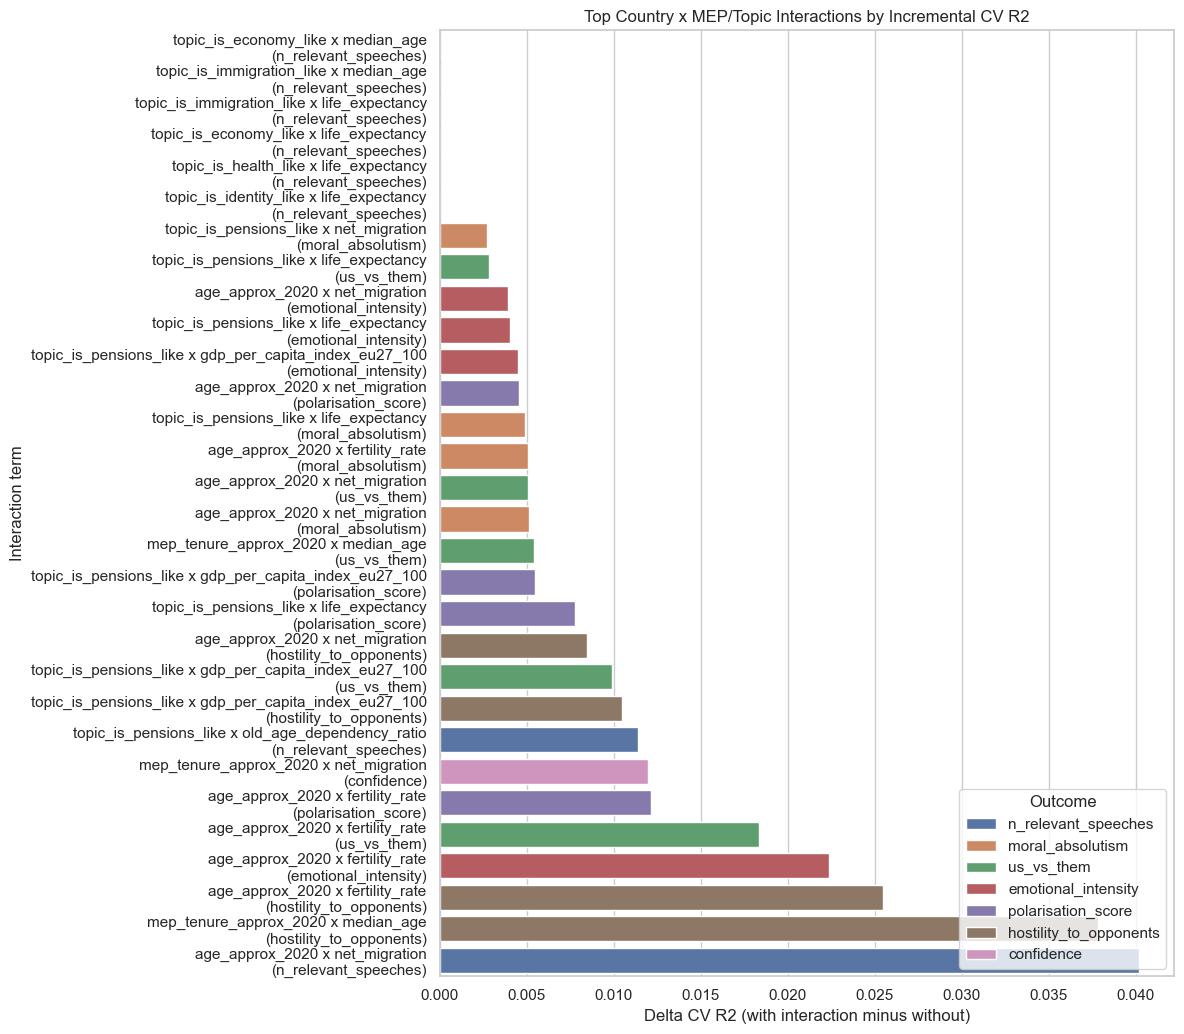

In [61]:

# --- Country x MEP interaction screening (stable, low-warning approach) ---



sns.set_theme(style="whitegrid", context="notebook")

FIGURE_OUTPUT_DIR = globals().get("FIGURE_OUTPUT_DIR", FIGURES_DIR)

FIGURE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)



def _compact_fig_name(filename):
    stem = Path(filename).stem.lower()
    stem = re.sub(r"[^a-z0-9]+", "_", stem).strip("_")
    token_map = {
        "descriptive": "desc", "polarisation": "pol", "correlation": "corr",
        "random": "rf", "forest": "rf", "association": "assoc", "strength": "str",
        "feature": "feat", "importance": "imp", "cluster": "cl", "country": "cty",
        "topic": "tp", "group": "grp", "party": "pty", "profile": "prof",
        "interaction": "int", "interactions": "ints", "composition": "comp",
        "prevalence": "prev", "outcome": "out", "outcomes": "outs",
        "distribution": "dist", "distributions": "dists", "heatmap": "hm",
        "scatter": "scat", "ranking": "rank", "silhouette": "sil",
        "high": "hi", "low": "lo", "absolute": "abs", "professional": "prof",
        "background": "bg",
    }
    parts = [token_map.get(p, p[:4]) for p in stem.split("_") if p]
    compact = "_".join(parts)
    compact = (compact[:48].rstrip("_") or "fig")
    return f"{compact}.png"

def save_figure(filename):
    plt.savefig(FIGURE_OUTPUT_DIR / _compact_fig_name(filename), dpi=300, bbox_inches="tight")



required_interaction_vars = [

    "analysis_df",

    "polarisation_targets_continuous",

]

missing_interaction_vars = [v for v in required_interaction_vars if v not in globals()]

if missing_interaction_vars:

    raise RuntimeError(

        "Please run the feature-engineering cells first. Missing: " + ", ".join(missing_interaction_vars)

    )



country_context_vars = [

    "median_age",

    "old_age_dependency_ratio",

    "life_expectancy",

    "fertility_rate",

    "gdp_per_capita_index_eu27_100",

    "youth_unemployment",

    "debt_to_gdp",

    "net_migration",

]

country_context_vars = [c for c in country_context_vars if c in analysis_df.columns]



mep_numeric_vars = [

    "age_approx_2020",

    "mep_tenure_approx_2020",

]

mep_numeric_vars = [c for c in mep_numeric_vars if c in analysis_df.columns]



topic_flag_patterns = {

    "topic_is_pensions_like": r"pension|retire|old age|welfare|social security",

    "topic_is_immigration_like": r"immigr|migrant|asylum|border",

    "topic_is_economy_like": r"econom|budget|finance|tax|fiscal",

    "topic_is_identity_like": r"identity|culture|values|religion|gender",

    "topic_is_health_like": r"health|hospital|medical|care",

}



interaction_df = analysis_df.copy()

if "topic_most_talked" in interaction_df.columns:

    topic_text = interaction_df["topic_most_talked"].astype(str).str.lower()

    topic_flag_data = {

        flag_name: topic_text.str.contains(pattern, regex=True, na=False).astype(float)

        for flag_name, pattern in topic_flag_patterns.items()

    }

else:

    topic_flag_data = {flag_name: pd.Series(0.0, index=interaction_df.index) for flag_name in topic_flag_patterns}



interaction_df = pd.concat([interaction_df, pd.DataFrame(topic_flag_data, index=interaction_df.index)], axis=1)

topic_flags = list(topic_flag_patterns.keys())



interaction_terms = []

for mep_var in mep_numeric_vars + topic_flags:

    for country_var in country_context_vars:

        interaction_terms.append((mep_var, country_var))



if len(interaction_terms) == 0:

    raise RuntimeError("No valid interaction term candidates were found.")



cv_inter = KFold(n_splits=5, shuffle=True, random_state=42)

interaction_rows = []



for target in [t for t in polarisation_targets_continuous if t in interaction_df.columns]:

    y_all = pd.to_numeric(interaction_df[target], errors="coerce")



    for mep_var, country_var in interaction_terms:

        a = pd.to_numeric(interaction_df[mep_var], errors="coerce")

        b = pd.to_numeric(interaction_df[country_var], errors="coerce")



        tmp = pd.DataFrame({

            "a": a,

            "b": b,

            "y": y_all,

        }).dropna()



        if len(tmp) < 40:

            continue



        a_std = (tmp["a"] - tmp["a"].mean()) / (tmp["a"].std(ddof=0) + 1e-12)

        b_std = (tmp["b"] - tmp["b"].mean()) / (tmp["b"].std(ddof=0) + 1e-12)

        inter_std = a_std * b_std



        X_base = pd.DataFrame({"a": a_std, "b": b_std})

        X_full = pd.DataFrame({

            "a": a_std,

            "b": b_std,

            "a_x_b": inter_std,

        })

        y = tmp["y"]



        base_scores = cross_val_score(LinearRegression(), X_base, y, cv=cv_inter, scoring="r2")

        full_scores = cross_val_score(LinearRegression(), X_full, y, cv=cv_inter, scoring="r2")

        delta_r2 = float(np.mean(full_scores) - np.mean(base_scores))



        model = LinearRegression()

        model.fit(X_full, y)

        coef_inter = float(model.coef_[2])



        interaction_rows.append({

            "outcome": target,

            "mep_or_topic_feature": mep_var,

            "country_feature": country_var,

            "interaction": f"{mep_var} x {country_var}",

            "n_rows": int(len(tmp)),

            "interaction_coef": coef_inter,

            "abs_interaction_coef": abs(coef_inter),

            "cv_r2_base": float(np.mean(base_scores)),

            "cv_r2_with_interaction": float(np.mean(full_scores)),

            "delta_cv_r2": delta_r2,

        })



if len(interaction_rows) == 0:

    print("No interaction results available (likely too many missing values in candidate variables).")

else:

    interaction_screen_df = pd.DataFrame(interaction_rows)



    interaction_summary_table = (

        interaction_screen_df

        .sort_values(["delta_cv_r2", "abs_interaction_coef"], ascending=[False, False])

        .reset_index(drop=True)

)

    display(interaction_summary_table.head(40))



    # Note: final_matched_file.xlsx export intentionally removed.



    for outcome in sorted(interaction_summary_table["outcome"].unique().tolist()):

        print(f"\nTop interactions for {outcome}:")

        display(

            interaction_summary_table[interaction_summary_table["outcome"] == outcome]

            .head(10)

            [[

                "interaction",

                "n_rows",

                "interaction_coef",

                "delta_cv_r2",

                "cv_r2_with_interaction",

            ]]

        )



    top_plot = interaction_summary_table.head(30).copy()

    top_plot["label"] = top_plot["interaction"] + "\n(" + top_plot["outcome"] + ")"

    top_plot = top_plot.sort_values("delta_cv_r2", ascending=True)



    plt.figure(figsize=(12, max(6, 0.35 * len(top_plot))))

    sns.barplot(data=top_plot, x="delta_cv_r2", y="label", hue="outcome", dodge=False)

    plt.title("Top Country x MEP/Topic Interactions by Incremental CV R2")

    plt.xlabel("Delta CV R2 (with interaction minus without)")

    plt.ylabel("Interaction term")

    plt.legend(title="Outcome", loc="lower right")

    plt.tight_layout()

    save_figure("country_mep_topic_interactions.png")

    plt.show()

In [42]:

# --- Final correlation table ---
# Builds a compact table of correlations between the main outcomes and the requested direct/topic/interaction variables.

if "analysis_df" not in globals():
    raise RuntimeError("Please run the earlier notebook cells first so analysis_df exists.")

outcome_vars = [
    "polarisation_score",
    "us_vs_them",
    "emotional_intensity",
    "moral_absolutism",
    "hostility_to_opponents",
]

direct_vars = [
    "age_approx_2020",
    "mep_tenure_approx_2020",
    "median_age",
    "old_age_dependency_ratio",
    "fertility_rate",
    "net_migration",
    "population_change",
    "youth_unemployment",
    "debt_to_gdp",
    "gdp_per_capita_index_eu27_100",
]

topic_vars = [
    "Ageing & Pensions",
    "Migration & Population Change",
    "Fertility & Family Formation",
    "Youth & Future Generations",
    "Labour Force & Workforce",
    "Regional Depopulation",
    "Health & Care Services",
    "Housing & Living Conditions",
    "Population Growth & Sustainability",
]

interaction_specs = {
    "ageing_topic_x_old_age_dependency": (
        "Ageing & Pensions",
        "old_age_dependency_ratio",
    ),
    "ageing_topic_x_median_age": (
        "Ageing & Pensions",
        "median_age",
    ),
    "migration_topic_x_net_migration": (
        "Migration & Population Change",
        "net_migration",
    ),
    "fertility_topic_x_fertility_rate": (
        "Fertility & Family Formation",
        "fertility_rate",
    ),
    "youth_topic_x_youth_unemployment": (
        "Youth & Future Generations",
        "youth_unemployment",
    ),
    "depopulation_topic_x_population_change": (
        "Regional Depopulation",
        "population_change",
    ),
}

topic_vars = [c for c in topic_vars if c in analysis_df.columns]
topic_vars = list(dict.fromkeys(topic_vars + [
    c for c in analysis_df.columns
    if str(c).startswith("Borderline:") or c in ["Fertility, Families & Gender", "Regional Depopulation & Territorial Cohesion"]
]))
correlation_predictors = direct_vars + topic_vars + list(interaction_specs.keys())

corr_df = analysis_df.copy()

# Create the requested interaction columns when both inputs exist.
for interaction_name, (topic_col, direct_col) in interaction_specs.items():
    if topic_col in corr_df.columns and direct_col in corr_df.columns:
        corr_df[interaction_name] = pd.to_numeric(corr_df[topic_col], errors="coerce") * pd.to_numeric(corr_df[direct_col], errors="coerce")

available_outcomes = [c for c in outcome_vars if c in corr_df.columns]
available_predictors = [c for c in correlation_predictors if c in corr_df.columns]

if not available_outcomes:
    raise RuntimeError("No outcome variables were found in analysis_df.")

if not available_predictors:
    raise RuntimeError("None of the requested correlation predictors were found in analysis_df.")

correlation_rows = []
for outcome in available_outcomes:
    for predictor in available_predictors:
        pair = corr_df[[outcome, predictor]].apply(pd.to_numeric, errors="coerce").dropna()
        if len(pair) < 3:
            continue

        corr_value = pair[outcome].corr(pair[predictor])
        correlation_rows.append({
            "outcome": outcome,
            "predictor": predictor,
            "correlation": corr_value,
            "abs_correlation": abs(corr_value),
            "n_obs": len(pair),
        })

correlation_table = pd.DataFrame(correlation_rows).sort_values(
    ["outcome", "abs_correlation"],
    ascending=[True, False],
).reset_index(drop=True)

display(correlation_table)
print("Rows in correlation table:", len(correlation_table))

,outcome,predictor,correlation,abs_correlation,n_obs
0,emotional_intensity,Borderline: Regional development policy,-0.140031,0.140031,139
1,emotional_intensity,Housing & Living Conditions,0.132990,0.132990,139
2,emotional_intensity,Health & Care Services,-0.131462,0.131462,139
3,emotional_intensity,Borderline: Island regions and cohesion,-0.119357,0.119357,139
4,emotional_intensity,youth_topic_x_youth_unemployment,0.087495,0.087495,134
...,...,...,...,...,...
120,us_vs_them,Borderline: Labour market and social policy,-0.010779,0.010779,139
121,us_vs_them,population_change,0.008076,0.008076,139
122,us_vs_them,Migration & Population Change,-0.007099,0.007099,139
123,us_vs_them,"Fertility, Families & Gender",0.004496,0.004496,139


Rows in correlation table: 125


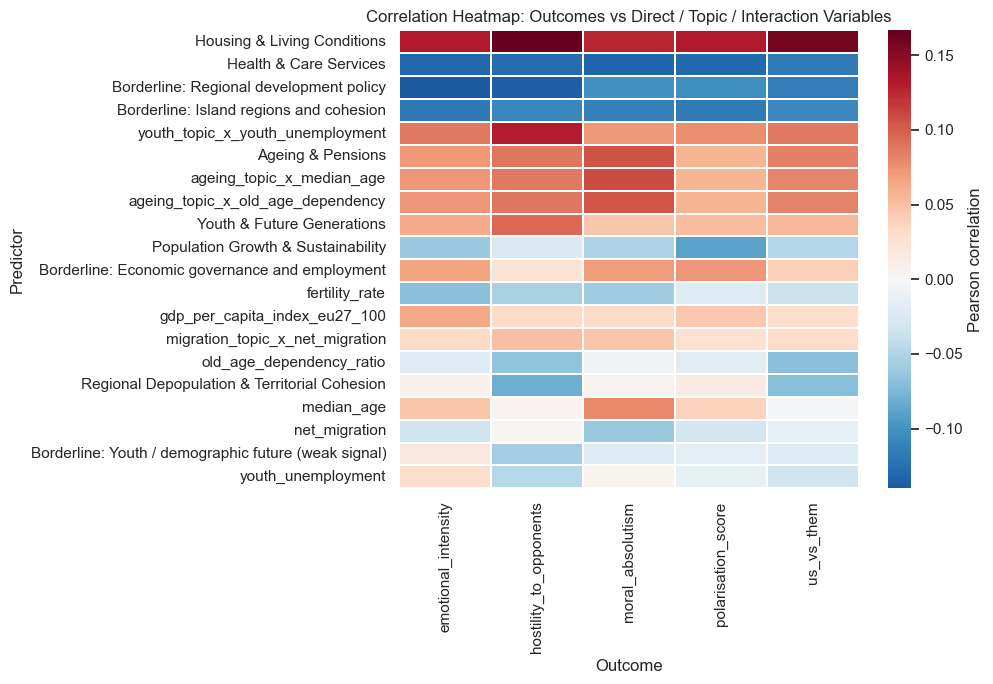

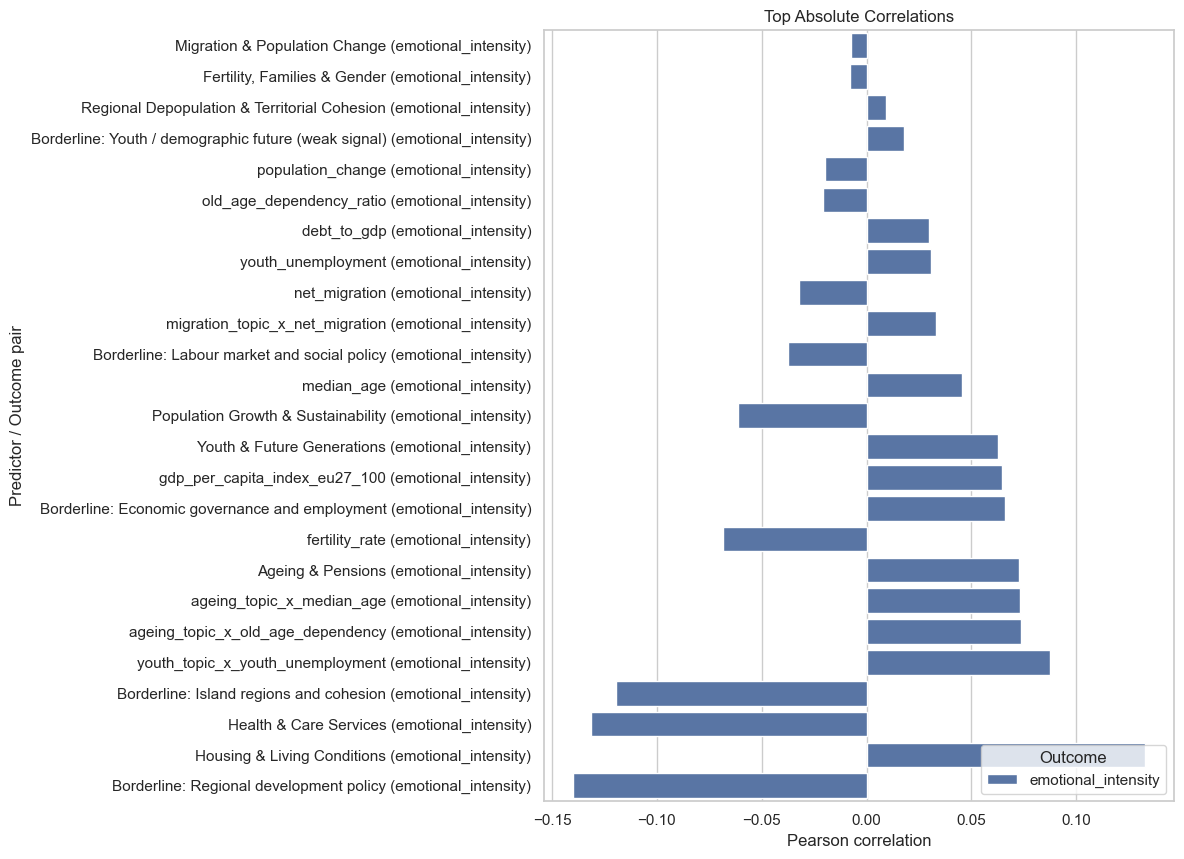

In [62]:

# --- Correlation visualization ---



FIGURE_OUTPUT_DIR = globals().get("FIGURE_OUTPUT_DIR", PROJECT_ROOT / "8 Final regression" / "figures")

FIGURE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)



def _compact_fig_name(filename):
    stem = Path(filename).stem.lower()
    stem = re.sub(r"[^a-z0-9]+", "_", stem).strip("_")
    token_map = {
        "descriptive": "desc", "polarisation": "pol", "correlation": "corr",
        "random": "rf", "forest": "rf", "association": "assoc", "strength": "str",
        "feature": "feat", "importance": "imp", "cluster": "cl", "country": "cty",
        "topic": "tp", "group": "grp", "party": "pty", "profile": "prof",
        "interaction": "int", "interactions": "ints", "composition": "comp",
        "prevalence": "prev", "outcome": "out", "outcomes": "outs",
        "distribution": "dist", "distributions": "dists", "heatmap": "hm",
        "scatter": "scat", "ranking": "rank", "silhouette": "sil",
        "high": "hi", "low": "lo", "absolute": "abs", "professional": "prof",
        "background": "bg",
    }
    parts = [token_map.get(p, p[:4]) for p in stem.split("_") if p]
    compact = "_".join(parts)
    compact = (compact[:48].rstrip("_") or "fig")
    return f"{compact}.png"

def save_figure(filename):
    plt.savefig(FIGURE_OUTPUT_DIR / _compact_fig_name(filename), dpi=300, bbox_inches="tight")



if "correlation_table" not in globals():

    raise RuntimeError("Please run the correlation table cell first.")



sns.set_theme(style="whitegrid", context="notebook")



# Pivot the long-form table into an outcome-by-predictor matrix.

correlation_heatmap_df = correlation_table.pivot_table(

    index="predictor",

    columns="outcome",

    values="correlation",

    aggfunc="mean",

)



# Keep the strongest overall correlations for readability.

if not correlation_heatmap_df.empty:

    top_n = min(20, len(correlation_heatmap_df))

    strongest_predictors = correlation_heatmap_df.abs().mean(axis=1).sort_values(ascending=False).head(top_n).index

    correlation_heatmap_df = correlation_heatmap_df.loc[strongest_predictors]



    plt.figure(figsize=(10, max(6, 0.35 * len(correlation_heatmap_df))))

    sns.heatmap(

        correlation_heatmap_df,

        cmap="RdBu_r",

        center=0,

        linewidths=0.3,

        cbar_kws={"label": "Pearson correlation"},

    )

    plt.title("Correlation Heatmap: Outcomes vs Direct / Topic / Interaction Variables")

    plt.xlabel("Outcome")

    plt.ylabel("Predictor")

    plt.tight_layout()

    save_figure("correlation_heatmap.png")

    plt.show()



# Also show a compact bar chart of the strongest absolute correlations.

plot_df = correlation_table.head(25).copy()

if not plot_df.empty:

    plot_df["label"] = plot_df["predictor"] + " (" + plot_df["outcome"] + ")"

    plot_df = plot_df.sort_values("abs_correlation", ascending=True)



    plt.figure(figsize=(12, max(6, 0.35 * len(plot_df))))

    sns.barplot(data=plot_df, x="correlation", y="label", hue="outcome", dodge=False)

    plt.title("Top Absolute Correlations")

    plt.xlabel("Pearson correlation")

    plt.ylabel("Predictor / Outcome pair")

    plt.legend(title="Outcome", loc="lower right")

    plt.tight_layout()

    save_figure("correlation_top_absolute_bars.png")

    plt.show()

## Descriptive Profiles for Thesis Figures

This section focuses on interpretability rather than prediction. It compares high- and low-polarisation cases, EP group patterns, topic composition, interaction-style bubble plots, and distributions of the main outcomes.

What this section does:
- Clarifies the purpose of this section and how it connects to the next steps.
- Summarizes expected inputs and outputs to make reruns easier to follow.


In [ ]:
_original_heatmap = sns.heatmap


def _safe_heatmap(data, *args, **kwargs):
    if hasattr(data, "empty") and data.empty:
        print("Skipping heatmap: empty data.")
        return None
    try:
        return _original_heatmap(data, *args, **kwargs)
    except ValueError as exc:
        if "zero-size array" in str(exc):
            print("Skipping heatmap: empty data.")
            return None
        raise


sns.heatmap = _safe_heatmap
print("Installed safe heatmap guard for empty matrices.")

Installed safe heatmap guard for empty matrices.


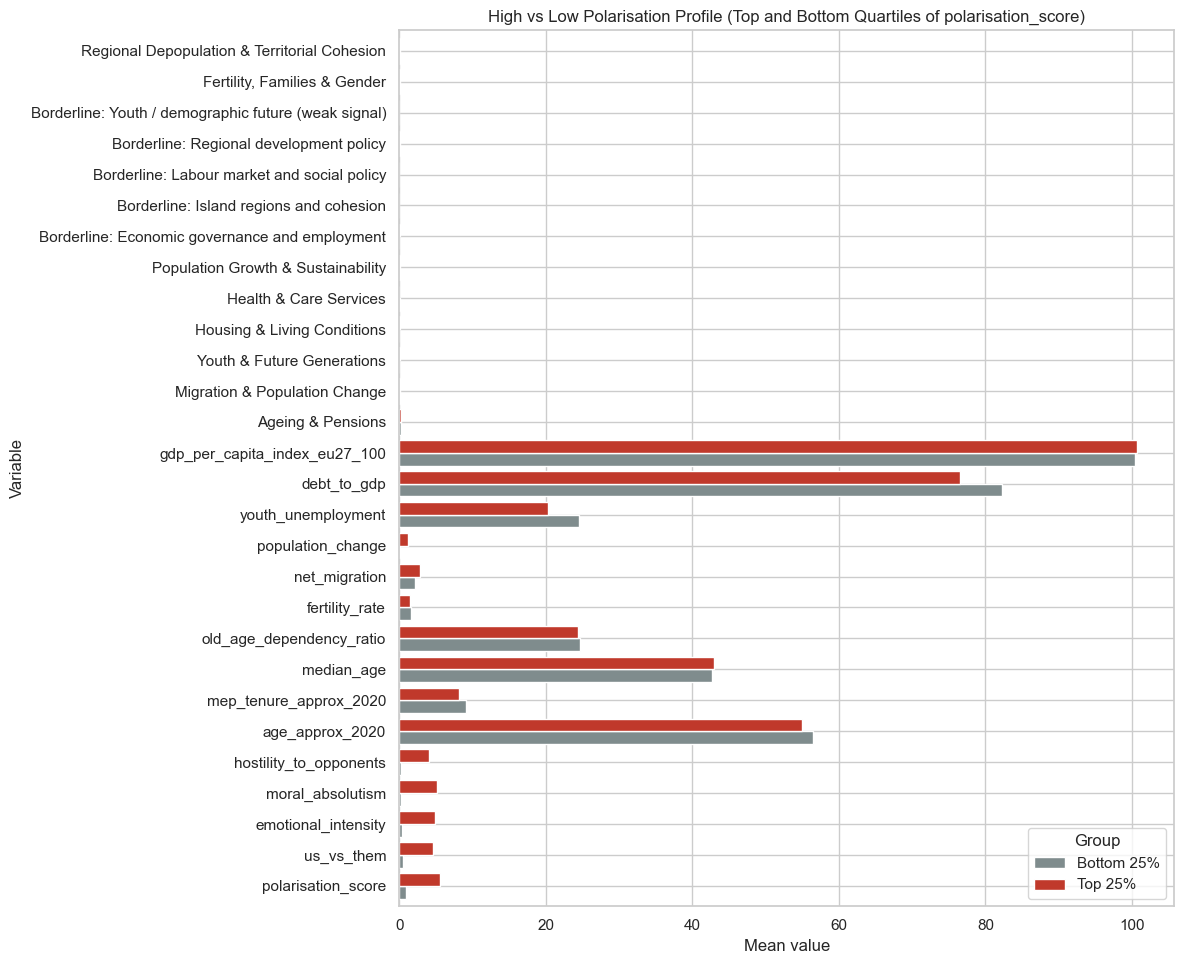

,ep_group_clean,mean_polarisation_score,n_obs
13,The Left/GUE-NGL,4.900000,5
6,ID/ENF/PfE,4.500000,3
3,Greens/EFA,3.750000,4
0,ECR,3.511111,9
4,Greens–European Free Alliance,3.400000,3
11,Renew/ALDE,2.862500,8
12,S&D,2.394286,35
2,EPP,2.175556,45
14,Unknown,2.047619,21


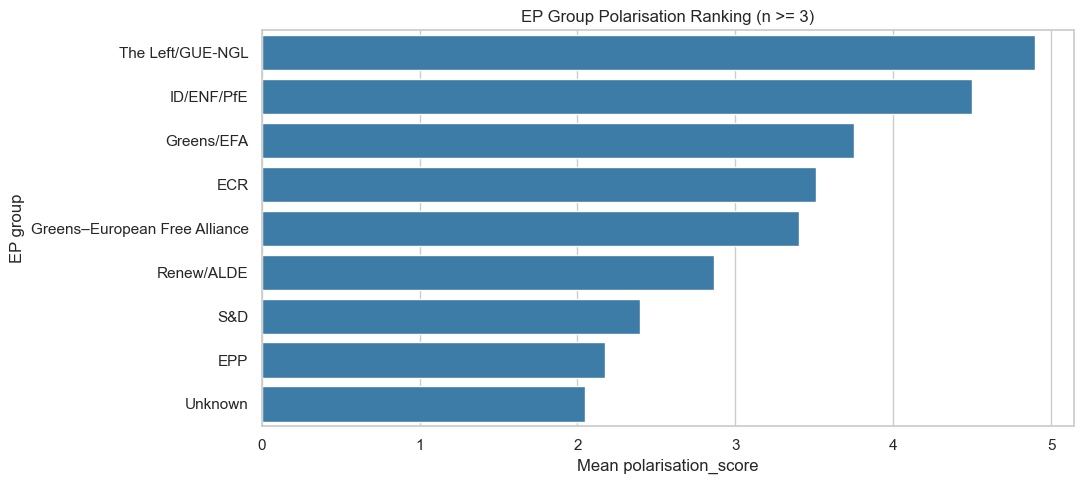

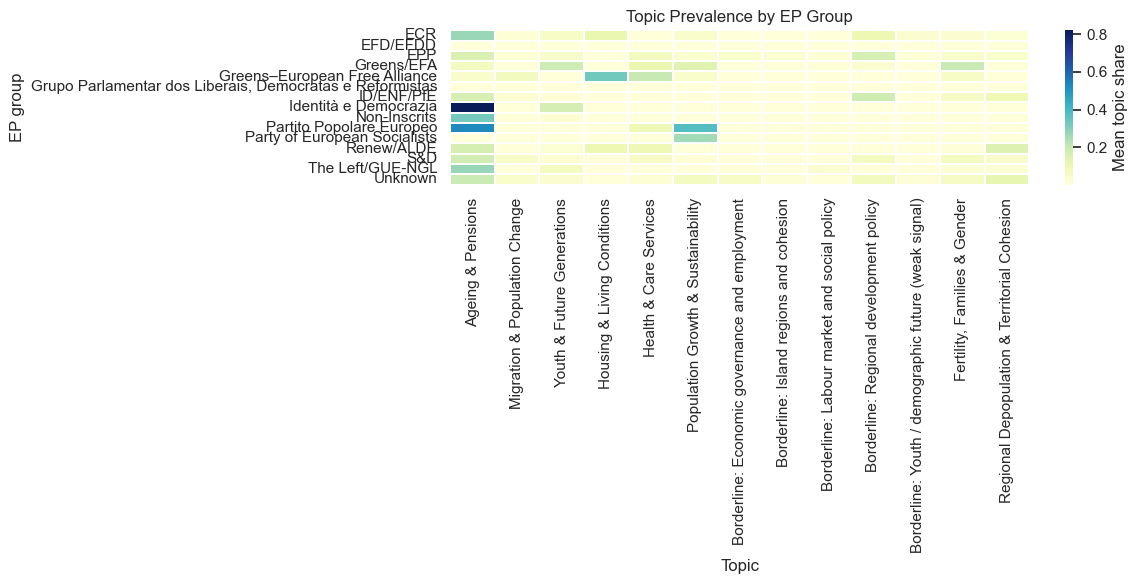

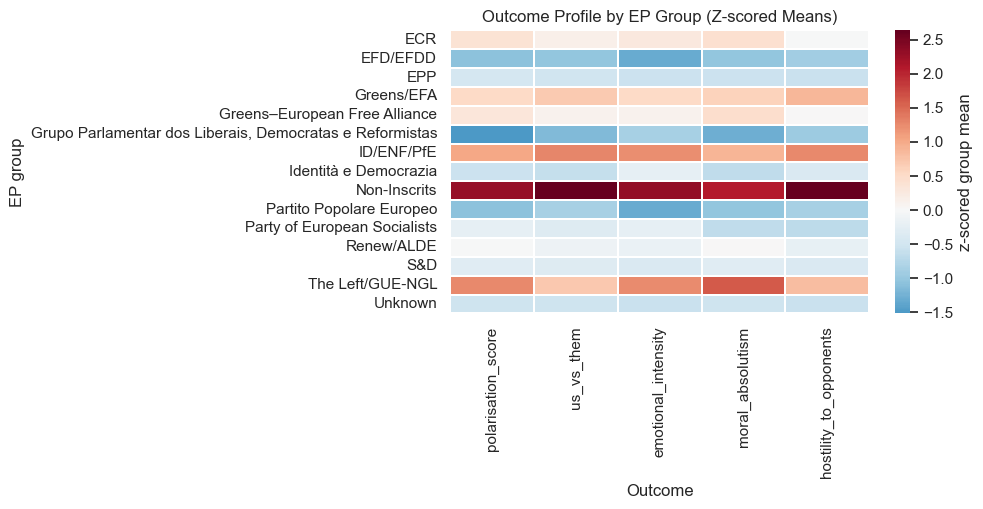

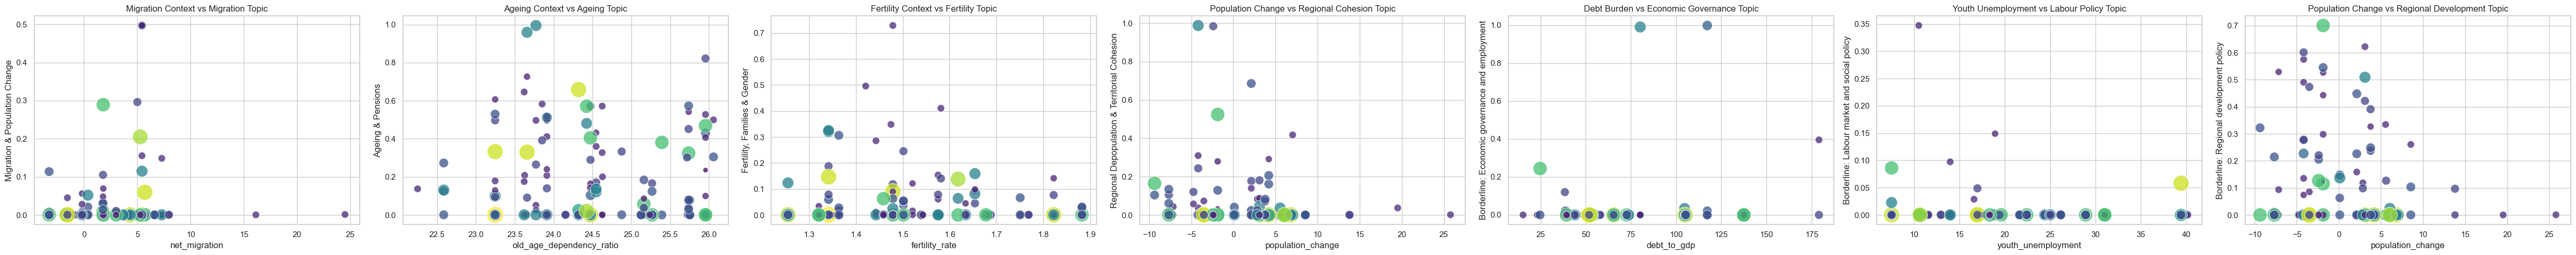

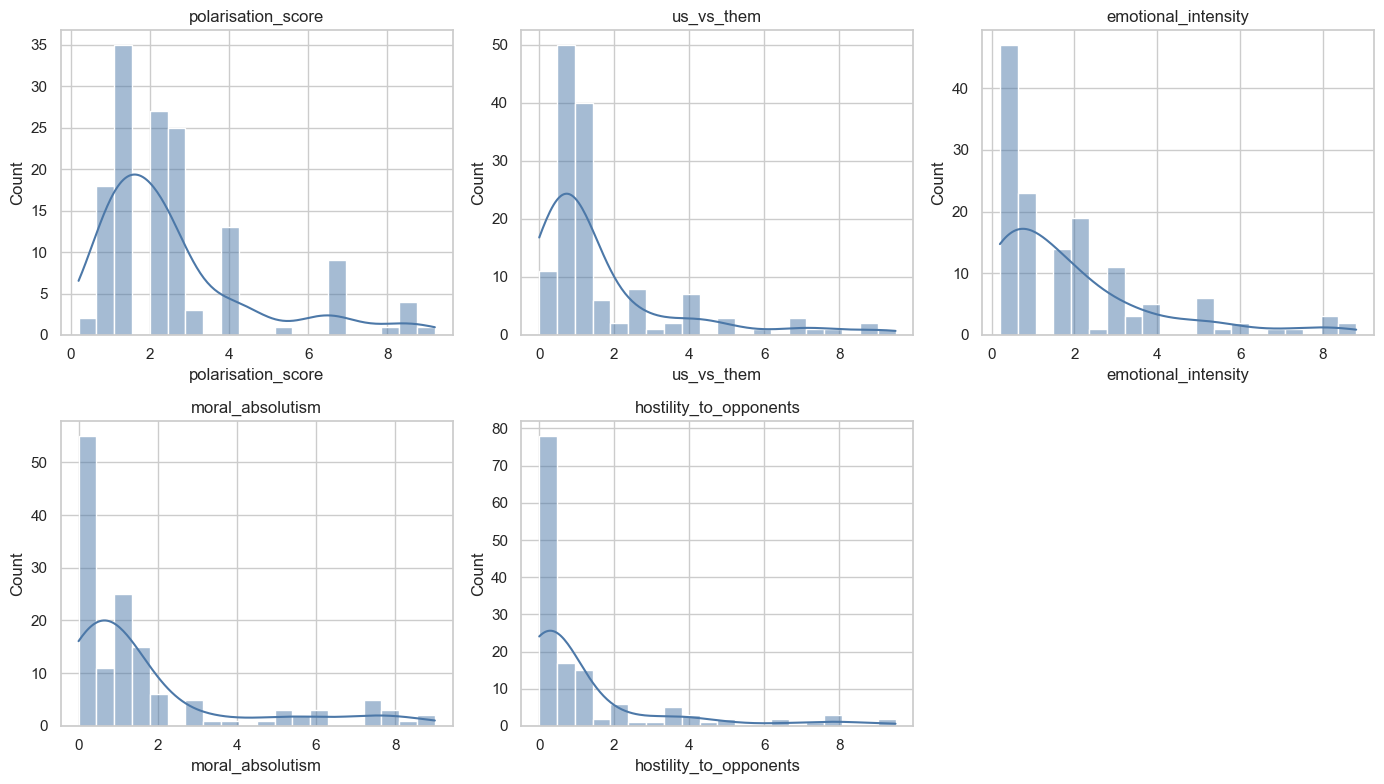

,mep_name_clean,country_clean,ep_group_clean,main_topic,polarisation_score
0,joachim stanis aw brudzinski,pl,ECR,Housing & Living Conditions,9.2
1,andrew henry william brons,gb,Unknown,Ageing & Pensions,8.5
2,christine anderson,de,ID/ENF/PfE,"Fertility, Families & Gender",8.5
3,maria lidia senra rodriguez,es,The Left/GUE-NGL,Ageing & Pensions,8.5
4,ukasz kohut,pl,S&D,Ageing & Pensions,8.5
5,tineke strik,nl,Greens–European Free Alliance,Migration & Population Change,8.0
6,martin schirdewan,de,The Left/GUE-NGL,Ageing & Pensions,6.5
7,bruno gollnisch,fr,Non-Inscrits,Ageing & Pensions,6.5
8,radan kanev,bg,EPP,Ageing & Pensions,6.5
9,pierfrancesco majorino,it,S&D,Regional Depopulation & Territorial Cohesion,6.5


,ep_group_clean,mean_polarisation_score,median_polarisation_score,n_obs
0,The Left/GUE-NGL,4.900000,4.00,5
1,ID/ENF/PfE,4.500000,4.00,3
2,Greens/EFA,3.750000,3.65,4
3,ECR,3.511111,2.50,9
4,Greens–European Free Alliance,3.400000,1.20,3
5,Renew/ALDE,2.862500,2.50,8
6,S&D,2.394286,2.00,35
7,EPP,2.175556,2.00,45
8,Unknown,2.047619,2.00,21



Party x Topic count table (ep_group_clean x dominant_topic):


dominant_topic,Ageing & Pensions,Borderline: Economic governance and employment,Borderline: Regional development policy,"Fertility, Families & Gender",Health & Care Services,Housing & Living Conditions,Migration & Population Change,Population Growth & Sustainability,Regional Depopulation & Territorial Cohesion,Youth & Future Generations
ep_group_clean,,,,,,,,,,
ECR,3,0,1,0,0,1,0,1,0,0
EPP,6,1,9,0,4,0,0,1,0,3
Greens/EFA,0,0,0,1,1,0,0,1,0,1
Renew/ALDE,2,0,0,0,1,1,0,0,1,0
S&D,7,0,1,1,0,0,1,0,1,1
Unknown,5,1,0,0,0,0,0,2,3,1


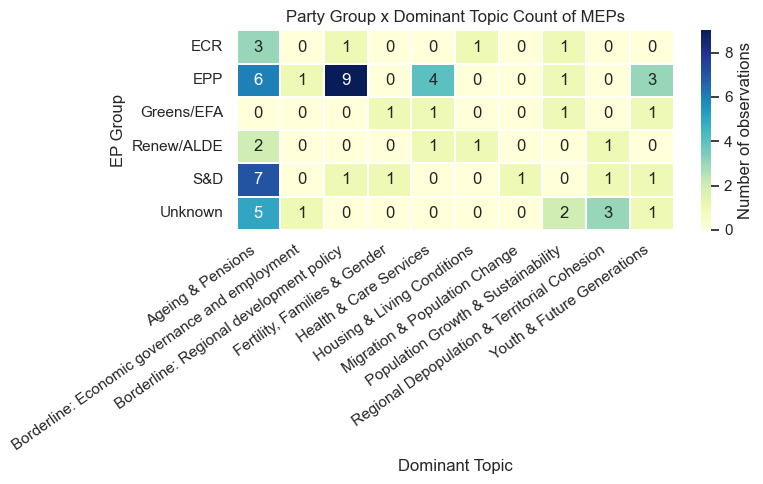


Party x Topic mean polarisation_score (blank = fewer than 2 obs):


dominant_topic,Ageing & Pensions,Borderline: Economic governance and employment,Borderline: Regional development policy,"Fertility, Families & Gender",Health & Care Services,Housing & Living Conditions,Migration & Population Change,Population Growth & Sustainability,Regional Depopulation & Territorial Cohesion,Youth & Future Generations
ep_group_clean,,,,,,,,,,
ECR,2.90,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EPP,2.15,NaN,2.46,NaN,1.8,NaN,NaN,NaN,NaN,2.5
Greens/EFA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Renew/ALDE,4.50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
S&D,2.90,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Unknown,1.28,NaN,NaN,NaN,NaN,NaN,NaN,1.1,1.9,NaN


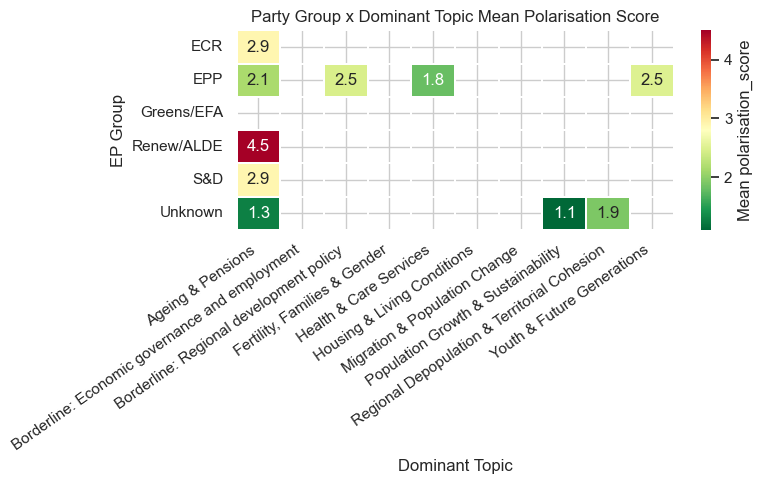

Descriptive section complete.


In [63]:



if "analysis_df" not in globals():

    raise RuntimeError("Please run the earlier analysis cells first so analysis_df exists.")



sns.set_theme(style="whitegrid", context="notebook")



FIGURE_OUTPUT_DIR = globals().get("FIGURE_OUTPUT_DIR", PROJECT_ROOT / "8 Final regression" / "figures")

FIGURE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)





def _compact_fig_name(filename):
    stem = Path(filename).stem.lower()
    stem = re.sub(r"[^a-z0-9]+", "_", stem).strip("_")
    token_map = {
        "descriptive": "desc", "polarisation": "pol", "correlation": "corr",
        "random": "rf", "forest": "rf", "association": "assoc", "strength": "str",
        "feature": "feat", "importance": "imp", "cluster": "cl", "country": "cty",
        "topic": "tp", "group": "grp", "party": "pty", "profile": "prof",
        "interaction": "int", "interactions": "ints", "composition": "comp",
        "prevalence": "prev", "outcome": "out", "outcomes": "outs",
        "distribution": "dist", "distributions": "dists", "heatmap": "hm",
        "scatter": "scat", "ranking": "rank", "silhouette": "sil",
        "high": "hi", "low": "lo", "absolute": "abs", "professional": "prof",
        "background": "bg",
    }
    parts = [token_map.get(p, p[:4]) for p in stem.split("_") if p]
    compact = "_".join(parts)
    compact = (compact[:48].rstrip("_") or "fig")
    return f"{compact}.png"

def save_figure(filename):
    plt.savefig(FIGURE_OUTPUT_DIR / _compact_fig_name(filename), dpi=300, bbox_inches="tight")





def first_existing(series_candidates):

    for candidate in series_candidates:

        if candidate in analysis_df.columns:

            return candidate

    return None





def numeric_series(column_name):

    return pd.to_numeric(analysis_df[column_name], errors="coerce") if column_name in analysis_df.columns else pd.Series(index=analysis_df.index, dtype=float)





outcome_vars = [

    "polarisation_score",

    "us_vs_them",

    "emotional_intensity",

    "moral_absolutism",

    "hostility_to_opponents",

]



direct_vars = [

    "age_approx_2020",

    "mep_tenure_approx_2020",

    "median_age",

    "old_age_dependency_ratio",

    "fertility_rate",

    "net_migration",

    "population_change",

    "youth_unemployment",

    "debt_to_gdp",

    "gdp_per_capita_index_eu27_100",

]



topic_vars = [

    "Ageing & Pensions",

    "Migration & Population Change",

    "Fertility & Family Formation",

    "Youth & Future Generations",

    "Housing & Living Conditions",

    "Health & Care Services",

    "Regional Depopulation",

    "Labour Force & Workforce",

    "Population Growth & Sustainability",

]



topic_vars = [c for c in topic_vars if c in analysis_df.columns]
topic_vars = list(dict.fromkeys(topic_vars + [
    c for c in analysis_df.columns
    if str(c).startswith("Borderline:") or c in ["Fertility, Families & Gender", "Regional Depopulation & Territorial Cohesion"]
]))

direct_vars = [c for c in direct_vars if c in analysis_df.columns]

outcome_vars = [c for c in outcome_vars if c in analysis_df.columns]



if not outcome_vars:

    raise RuntimeError("No polarisation outcome columns were found in analysis_df.")



profile_vars = list(dict.fromkeys(outcome_vars + direct_vars + topic_vars))



# 1) High vs low polarisation profile plot

if "polarisation_score" not in analysis_df.columns:

    raise RuntimeError("polarisation_score is required for the high/low profile plot.")



profile_df = analysis_df.copy()

score_rank = pd.to_numeric(profile_df["polarisation_score"], errors="coerce").rank(pct=True)

bottom_mask = score_rank <= 0.25

top_mask = score_rank >= 0.75



selected_group_means = []

for group_name, group_mask in {"Bottom 25%": bottom_mask, "Top 25%": top_mask}.items():

    group = profile_df.loc[group_mask, profile_vars].apply(pd.to_numeric, errors="coerce")

    means = group.mean(numeric_only=True)

    selected_group_means.append(means.rename(group_name))



high_low_profile = pd.concat(selected_group_means, axis=1).reindex(profile_vars)

high_low_profile = high_low_profile.dropna(how="all")



if not high_low_profile.empty:

    ax = high_low_profile.plot(kind="barh", figsize=(12, max(6, 0.35 * len(high_low_profile))), width=0.82, color=["#7f8c8d", "#c0392b"])

    ax.set_title("High vs Low Polarisation Profile (Top and Bottom Quartiles of polarisation_score)")

    ax.set_xlabel("Mean value")

    ax.set_ylabel("Variable")

    ax.legend(title="Group", loc="lower right")

    plt.tight_layout()

    save_figure("descriptive_high_vs_low_polarisation_profile.png")

    plt.show()



# 2) Topic composition by polarisation cluster

cluster_col = first_existing(["topic_polarisation_cluster", "polarisation_cluster", "cluster"])

if cluster_col is not None and topic_vars:

    cluster_topic_means = analysis_df.groupby(cluster_col)[topic_vars].mean(numeric_only=True)

    cluster_topic_norm = cluster_topic_means.div(cluster_topic_means.sum(axis=1).replace(0, np.nan), axis=0)

    cluster_topic_norm = cluster_topic_norm.fillna(0.0)



    plt.figure(figsize=(12, max(4, 0.45 * len(cluster_topic_norm))))

    sns.heatmap(cluster_topic_norm, cmap="YlGnBu", linewidths=0.3, cbar_kws={"label": "Within-cluster topic share"})

    plt.title("Topic Composition by Polarisation Cluster")

    plt.xlabel("Topic")

    plt.ylabel("Cluster")

    plt.tight_layout()

    save_figure("descriptive_topic_composition_by_cluster.png")

    plt.show()



# 3) EP group polarisation ranking, minimum 3 observations

ep_group_column = first_existing(["ep_group_clean", "ep_group_extracted"])

if ep_group_column is not None and "polarisation_score" in analysis_df.columns:

    ep_group_summary = (

        analysis_df.assign(polarisation_score=pd.to_numeric(analysis_df["polarisation_score"], errors="coerce"))

        .groupby(ep_group_column)

        .agg(mean_polarisation_score=("polarisation_score", "mean"), n_obs=("polarisation_score", "size"))

        .reset_index()

    )

    ep_group_summary = ep_group_summary[ep_group_summary["n_obs"] >= 3].sort_values("mean_polarisation_score", ascending=False)

    display(ep_group_summary)



    if not ep_group_summary.empty:

        plt.figure(figsize=(11, max(5, 0.35 * len(ep_group_summary))))

        sns.barplot(data=ep_group_summary, y=ep_group_column, x="mean_polarisation_score", color="#2c7fb8")

        plt.title("EP Group Polarisation Ranking (n >= 3)")

        plt.xlabel("Mean polarisation_score")

        plt.ylabel("EP group")

        plt.tight_layout()

        save_figure("descriptive_ep_group_polarisation_ranking.png")

        plt.show()



# 4) Topic prevalence by EP group heatmap

if ep_group_column is not None and topic_vars:

    ep_topic_means = analysis_df.groupby(ep_group_column)[topic_vars].mean(numeric_only=True)

    plt.figure(figsize=(12, max(5, 0.4 * len(ep_topic_means))))

    sns.heatmap(ep_topic_means, cmap="YlGnBu", linewidths=0.25, cbar_kws={"label": "Mean topic share"})

    plt.title("Topic Prevalence by EP Group")

    plt.xlabel("Topic")

    plt.ylabel("EP group")

    plt.tight_layout()

    save_figure("descriptive_topic_prevalence_by_ep_group.png")

    plt.show()



# 5) Outcome profile by EP group, using z-scored group means

if ep_group_column is not None:

    outcome_means = (

        analysis_df.assign(**{c: pd.to_numeric(analysis_df[c], errors="coerce") for c in outcome_vars if c in analysis_df.columns})

        .groupby(ep_group_column)[outcome_vars]

        .mean(numeric_only=True)

    )

    outcome_z = (outcome_means - outcome_means.mean(axis=0)) / outcome_means.std(axis=0).replace(0, np.nan)

    outcome_z = outcome_z.fillna(0.0)



    plt.figure(figsize=(10, max(5, 0.35 * len(outcome_z))))

    sns.heatmap(outcome_z, cmap="RdBu_r", center=0, linewidths=0.25, cbar_kws={"label": "z-scored group mean"})

    plt.title("Outcome Profile by EP Group (Z-scored Means)")

    plt.xlabel("Outcome")

    plt.ylabel("EP group")

    plt.tight_layout()

    save_figure("descriptive_outcome_profile_by_ep_group.png")

    plt.show()



# 6) Bubble plots showing interaction logic

bubble_specs = [

    ("net_migration", "Migration & Population Change", "Migration Context vs Migration Topic"),

    ("old_age_dependency_ratio", "Ageing & Pensions", "Ageing Context vs Ageing Topic"),

    ("fertility_rate", "Fertility, Families & Gender", "Fertility Context vs Fertility Topic"),

    ("population_change", "Regional Depopulation & Territorial Cohesion", "Population Change vs Regional Cohesion Topic"),

    ("debt_to_gdp", "Borderline: Economic governance and employment", "Debt Burden vs Economic Governance Topic"),

    ("youth_unemployment", "Borderline: Labour market and social policy", "Youth Unemployment vs Labour Policy Topic"),

    ("population_change", "Borderline: Regional development policy", "Population Change vs Regional Development Topic"),

]



bubble_cols = []

for x_col, y_col, title in bubble_specs:

    if x_col in analysis_df.columns and y_col in analysis_df.columns and "polarisation_score" in analysis_df.columns:

        bubble_cols.append((x_col, y_col, title))



if bubble_cols:

    fig, axes = plt.subplots(1, len(bubble_cols), figsize=(7 * len(bubble_cols), 5), squeeze=False)

    axes_flat = axes.flatten()

    bubble_size = pd.to_numeric(analysis_df["polarisation_score"], errors="coerce")

    valid_bubble_size = bubble_size.dropna()

    if valid_bubble_size.empty:

        bubble_scaled = pd.Series(100.0, index=analysis_df.index)

    else:

        size_min = float(valid_bubble_size.min())

        size_span = float(valid_bubble_size.max() - size_min)

        bubble_scaled = 50 + 450 * ((bubble_size - size_min) / (size_span if size_span else 1.0))

        bubble_scaled = bubble_scaled.clip(lower=50, upper=500)



    for idx, (x_col, y_col, title) in enumerate(bubble_cols):

        plot_df = analysis_df[[x_col, y_col, "polarisation_score"]].copy()

        plot_df[x_col] = pd.to_numeric(plot_df[x_col], errors="coerce")

        plot_df[y_col] = pd.to_numeric(plot_df[y_col], errors="coerce")

        plot_df["bubble_size"] = bubble_scaled

        plot_df = plot_df.dropna(subset=[x_col, y_col, "polarisation_score"])



        ax = axes_flat[idx]

        sns.scatterplot(

            data=plot_df,

            x=x_col,

            y=y_col,

            size="bubble_size",

            sizes=(50, 500),

            hue="polarisation_score",

            palette="viridis",

            alpha=0.75,

            ax=ax,

            legend=False,

        )

        ax.set_title(title)

        ax.set_xlabel(x_col)

        ax.set_ylabel(y_col)



    plt.tight_layout()

    save_figure("descriptive_bubble_interaction_plots.png")

    plt.show()



# 7) Distribution plots for all five polarisation outcomes

available_outcomes = [c for c in outcome_vars if c in analysis_df.columns]

if available_outcomes:

    fig, axes = plt.subplots(2, 3, figsize=(14, 8), squeeze=False)

    axes_flat = axes.flatten()

    for idx, outcome in enumerate(available_outcomes):

        values = pd.to_numeric(analysis_df[outcome], errors="coerce").dropna()

        sns.histplot(values, kde=True, ax=axes_flat[idx], color="#4c78a8", bins=20)

        axes_flat[idx].set_title(outcome)

        axes_flat[idx].set_xlabel(outcome)

        axes_flat[idx].set_ylabel("Count")

    for idx in range(len(available_outcomes), len(axes_flat)):

        axes_flat[idx].axis("off")

    plt.tight_layout()

    save_figure("descriptive_polarisation_outcome_distributions.png")

    plt.show()



# 8) Table of the top 10 most polarised cases

case_df = analysis_df.copy()

case_df["polarisation_score"] = pd.to_numeric(case_df["polarisation_score"], errors="coerce")

case_df = case_df.sort_values("polarisation_score", ascending=False)



mep_name_col = first_existing(["mep_name_clean", "name", "MEP", "full_name_extracted"])

country_col = first_existing(["country_clean", "Country", "country", "country_of_origin_extracted"])

ep_group_col = first_existing(["ep_group_clean", "ep_group_extracted", "ep_group"])

main_topic_col = None

if topic_vars:

    topic_subset = [c for c in topic_vars if c in case_df.columns]

    if topic_subset:

        case_df["main_topic"] = case_df[topic_subset].apply(pd.to_numeric, errors="coerce").idxmax(axis=1)

        main_topic_col = "main_topic"



columns_to_show = [c for c in [mep_name_col, country_col, ep_group_col, main_topic_col, "polarisation_score"] if c is not None and c in case_df.columns]

most_polarised_cases = case_df[columns_to_show].head(10).reset_index(drop=True)

display(most_polarised_cases)



# Optional compact summary tables for thesis drafting

ep_group_polarisation_table = None

if ep_group_column is not None and "polarisation_score" in analysis_df.columns:

    ep_group_polarisation_table = (

        analysis_df.assign(polarisation_score=pd.to_numeric(analysis_df["polarisation_score"], errors="coerce"))

        .groupby(ep_group_column)

        .agg(mean_polarisation_score=("polarisation_score", "mean"), median_polarisation_score=("polarisation_score", "median"), n_obs=("polarisation_score", "size"))

        .query("n_obs >= 3")

        .sort_values("mean_polarisation_score", ascending=False)

        .reset_index()

    )

    display(ep_group_polarisation_table)



# 9) Party group x dominant topic count heatmap

# and 10) Party group x dominant topic mean polarisation heatmap

_ep_col = "ep_group_clean" if "ep_group_clean" in analysis_df.columns else None

_topic_col = "dominant_topic" if "dominant_topic" in analysis_df.columns else ("dominant_cluster" if "dominant_cluster" in analysis_df.columns else None)

_score_col = "polarisation_score" if "polarisation_score" in analysis_df.columns else None



if _ep_col is None:

    print("Skipping party x topic heatmaps: ep_group_clean not found.")

elif _topic_col is None:

    print("Skipping party x topic heatmaps: neither dominant_topic nor dominant_cluster found.")

elif _score_col is None:

    print("Skipping party x topic heatmaps: polarisation_score not found.")

else:

    _pt_df = analysis_df[[_ep_col, _topic_col, _score_col]].copy()

    _pt_df[_score_col] = pd.to_numeric(_pt_df[_score_col], errors="coerce")

    _pt_df = _pt_df.dropna(subset=[_ep_col, _topic_col])

    _pt_df[_ep_col] = _pt_df[_ep_col].astype(str).str.strip()

    _pt_df[_topic_col] = _pt_df[_topic_col].astype(str).str.strip()

    _pt_df = _pt_df[_pt_df[_topic_col] != "Other"]



    # Filter EP groups to those with at least 3 total observations

    _ep_counts = _pt_df[_ep_col].value_counts()

    _valid_ep_groups = _ep_counts[_ep_counts >= 3].index.tolist()

    _pt_df = _pt_df[_pt_df[_ep_col].isin(_valid_ep_groups)]



    # Count table

    _count_pivot = (

        _pt_df.groupby([_ep_col, _topic_col])

        .size()

        .unstack(fill_value=0)

    )

    print(f"\nParty x Topic count table (ep_group_clean x {_topic_col}):")

    display(_count_pivot)



    if not _count_pivot.empty:

        _fig_h = max(5, 0.45 * len(_count_pivot))

        _fig_w = max(8, 0.7 * len(_count_pivot.columns))

        plt.figure(figsize=(_fig_w, _fig_h))

        sns.heatmap(

            _count_pivot,

            cmap="YlGnBu",

            linewidths=0.25,

            annot=True,

            fmt="d",

            cbar_kws={"label": "Number of observations"},

        )

        plt.title(f"Party Group x Dominant Topic Count of MEPs")

        plt.xlabel("Dominant Topic")

        plt.ylabel("EP Group")

        plt.xticks(rotation=35, ha="right")

        plt.tight_layout()

        save_figure("party_topic_count_heatmap.png")

        plt.show()



    # Mean polarisation table (blank cells where n < 2)

    _mean_pivot = (

        _pt_df.groupby([_ep_col, _topic_col])[_score_col]

        .mean()

        .unstack()

    )

    _n_pivot = (

        _pt_df.groupby([_ep_col, _topic_col])

        .size()

        .unstack(fill_value=0)

    )

    # Mask cells with fewer than 2 observations

    _mean_pivot_masked = _mean_pivot.where(_n_pivot >= 2)

    print(f"\nParty x Topic mean polarisation_score (blank = fewer than 2 obs):")

    display(_mean_pivot_masked.round(2))



    if not _mean_pivot_masked.empty:

        _fig_h2 = max(5, 0.45 * len(_mean_pivot_masked))

        _fig_w2 = max(8, 0.7 * len(_mean_pivot_masked.columns))

        plt.figure(figsize=(_fig_w2, _fig_h2))

        sns.heatmap(

            _mean_pivot_masked,

            cmap="RdYlGn_r",

            linewidths=0.25,

            annot=True,

            fmt=".1f",

            cbar_kws={"label": "Mean polarisation_score"},

        )

        plt.title("Party Group x Dominant Topic Mean Polarisation Score")

        plt.xlabel("Dominant Topic")

        plt.ylabel("EP Group")

        plt.xticks(rotation=35, ha="right")

        plt.tight_layout()

        save_figure("party_topic_polarisation_heatmap.png")

        plt.show()



print("Descriptive section complete.")

In [64]:
topic_vars = [
    c for c in [
        "Ageing & Pensions",
        "Migration & Population Change",
        "Fertility & Family Formation",
        "Youth & Future Generations",
        "Housing & Living Conditions",
        "Health & Care Services",
        "Regional Depopulation",
        "Labour Force & Workforce",
        "Population Growth & Sustainability",
    ]
    if c in analysis_df.columns
]
topic_vars = list(dict.fromkeys(topic_vars + [
    c for c in analysis_df.columns
    if str(c).startswith("Borderline:") or c in ["Fertility, Families & Gender", "Regional Depopulation & Territorial Cohesion"]
]))

topic_cluster_candidates = [
    c for c in analysis_df.columns
    if "cluster" in c.lower() and (
        "topic" in c.lower() or "polarisation" in c.lower() or "dominant" in c.lower()
    )
]

print("Detected topic-cluster columns:", topic_cluster_candidates)
print("Available topic columns:", topic_vars)

cluster_col = next(
    (c for c in ["topic_polarisation_cluster", "polarisation_cluster", "cluster"] if c in analysis_df.columns),
    None,
)
if cluster_col is None and topic_cluster_candidates:
    cluster_col = topic_cluster_candidates[0]
    print(f"Using fallback cluster column: {cluster_col}")
else:
    print(f"Using cluster column: {cluster_col}")

Detected topic-cluster columns: ['dominant_cluster']
Available topic columns: ['Ageing & Pensions', 'Migration & Population Change', 'Youth & Future Generations', 'Housing & Living Conditions', 'Health & Care Services', 'Population Growth & Sustainability', 'Borderline: Economic governance and employment', 'Borderline: Island regions and cohesion', 'Borderline: Labour market and social policy', 'Borderline: Regional development policy', 'Borderline: Youth / demographic future (weak signal)', 'Fertility, Families & Gender', 'Regional Depopulation & Territorial Cohesion']
Using fallback cluster column: dominant_cluster



Region: polarisation summary (n >= 5)


,Region,n_obs,mean_polarisation,median_polarisation,sd_polarisation
0,Western Europe,36,3.144444,2.0,2.283286
1,Southern Europe,36,2.488889,2.0,1.939187
2,Central & Eastern Europe,48,2.368750,2.0,1.825605
3,Northern Europe,9,2.266667,2.5,0.924662
4,Baltic,9,2.044444,1.2,1.740769


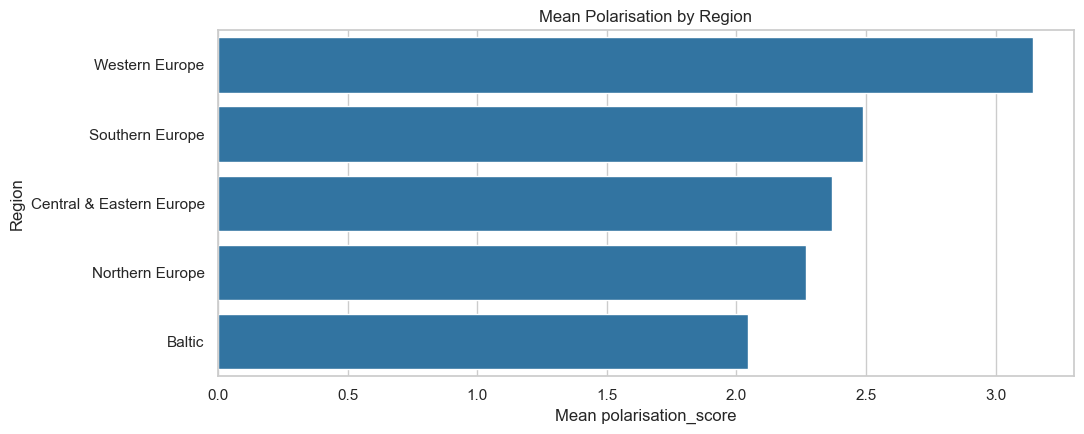

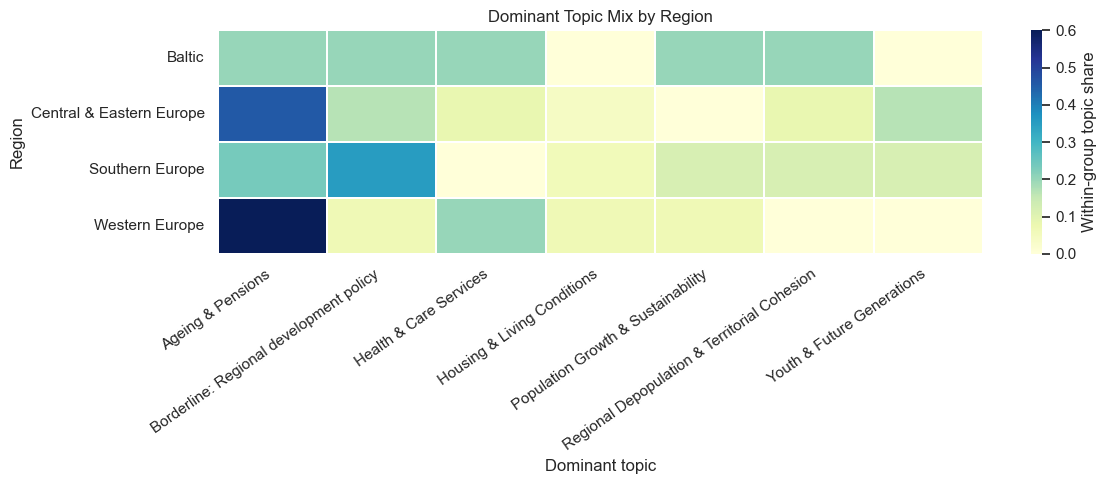

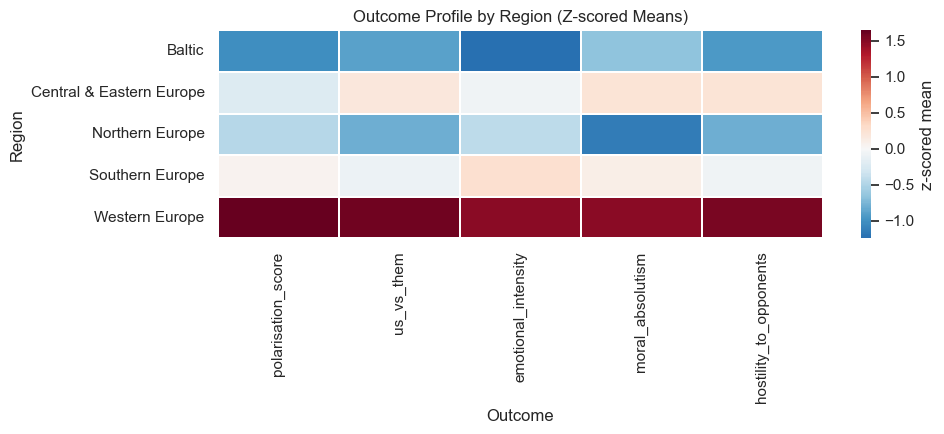


Professional Background: polarisation summary (n >= 5)


,Professional Background,n_obs,mean_polarisation,median_polarisation,sd_polarisation
0,Other / Unclear,7,4.028571,2.5,3.099309
1,Academia / Education,17,3.505882,2.5,2.523012
2,Politics / Public Administration,93,2.370968,2.0,1.624646
3,Business / Finance,8,1.975000,1.2,1.891900
4,Media / Journalism,9,1.666667,1.2,1.024695


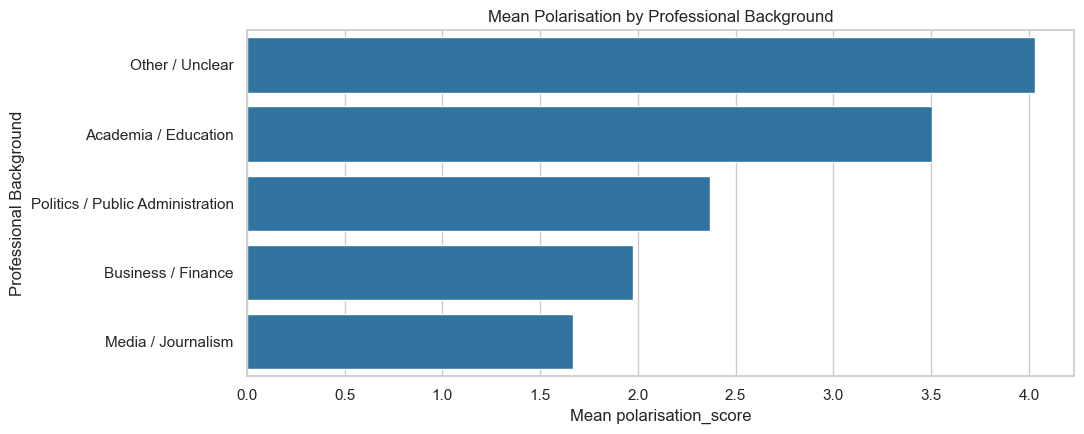

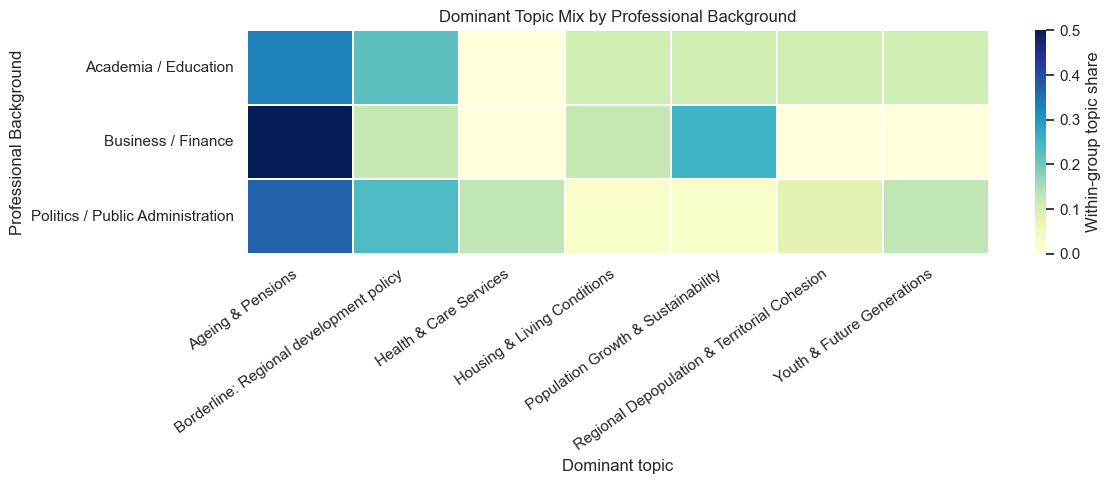

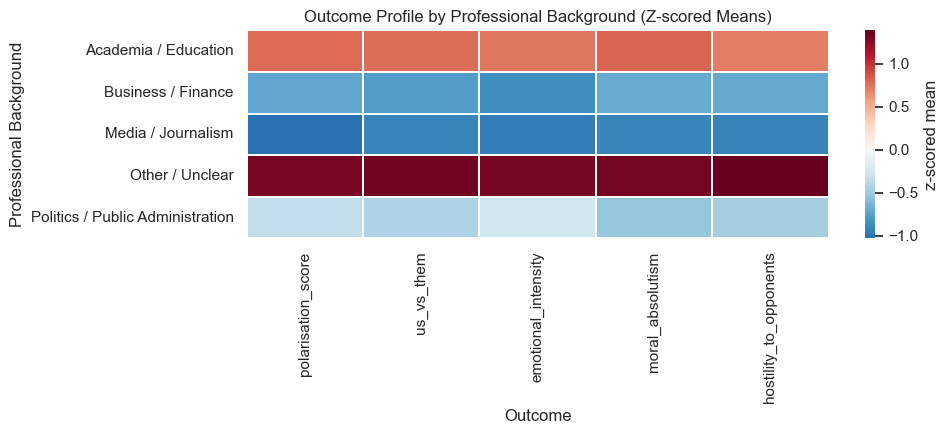

Skipping Age Group: column 'age_group' not found.
Skipping Tenure Group: column 'tenure_group' not found.
Skipping International Experience: not enough usable categories after min_n=3 filter.
Skipping Migration Background: not enough usable categories after min_n=3 filter.
Skipping Military Background: not enough usable categories after min_n=3 filter.
Extended characteristic-based descriptive analysis complete.


In [65]:



if "analysis_df" not in globals():

    raise RuntimeError("analysis_df is missing. Run the cleaning/model prep cells first.")



if "polarisation_score" not in analysis_df.columns:

    raise RuntimeError("polarisation_score is required for characteristic-based descriptive analysis.")



sns.set_theme(style="whitegrid", context="notebook")



FIGURE_OUTPUT_DIR = globals().get("FIGURE_OUTPUT_DIR", PROJECT_ROOT / "8 Final regression" / "figures")

FIGURE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)





def _compact_fig_name(filename):
    stem = Path(filename).stem.lower()
    stem = re.sub(r"[^a-z0-9]+", "_", stem).strip("_")
    token_map = {
        "descriptive": "desc", "polarisation": "pol", "correlation": "corr",
        "random": "rf", "forest": "rf", "association": "assoc", "strength": "str",
        "feature": "feat", "importance": "imp", "cluster": "cl", "country": "cty",
        "topic": "tp", "group": "grp", "party": "pty", "profile": "prof",
        "interaction": "int", "interactions": "ints", "composition": "comp",
        "prevalence": "prev", "outcome": "out", "outcomes": "outs",
        "distribution": "dist", "distributions": "dists", "heatmap": "hm",
        "scatter": "scat", "ranking": "rank", "silhouette": "sil",
        "high": "hi", "low": "lo", "absolute": "abs", "professional": "prof",
        "background": "bg",
    }
    parts = [token_map.get(p, p[:4]) for p in stem.split("_") if p]
    compact = "_".join(parts)
    compact = (compact[:48].rstrip("_") or "fig")
    return f"{compact}.png"

def save_figure_local(filename):
    plt.savefig(FIGURE_OUTPUT_DIR / _compact_fig_name(filename), dpi=300, bbox_inches="tight")





def safe_name(text):

    return re.sub(r"[^a-z0-9]+", "_", str(text).strip().lower()).strip("_")



SHORT_FIGURE_NAME_MAP = {

    "professional_background_clean": "prof_bg",

}



def prep_category_series(df, col):

    s = df[col].copy()

    if col.endswith("_flag"):

        s = pd.to_numeric(s, errors="coerce").map({1.0: "Yes", 0.0: "No"})

    s = s.astype("string").str.strip()

    s = s.replace({"": pd.NA, "nan": pd.NA, "None": pd.NA})

    return s





characteristics = [

    ("region_clean", "Region", 5),

    ("professional_background_clean", "Professional Background", 5),

    ("age_group", "Age Group", 5),

    ("tenure_group", "Tenure Group", 5),

    ("international_experience_flag", "International Experience", 3),

    ("migration_background_flag", "Migration Background", 3),

    ("military_background_flag", "Military Background", 3),

]



topic_col = "dominant_topic" if "dominant_topic" in analysis_df.columns else ("dominant_cluster" if "dominant_cluster" in analysis_df.columns else None)

outcomes = [

    c for c in [

        "polarisation_score",

        "us_vs_them",

        "emotional_intensity",

        "moral_absolutism",

        "hostility_to_opponents",

    ] if c in analysis_df.columns

]



characteristic_tables = {}



for col, label, min_n in characteristics:

    if col not in analysis_df.columns:

        print(f"Skipping {label}: column '{col}' not found.")

        continue



    work = analysis_df.copy()

    work["_score"] = pd.to_numeric(work["polarisation_score"], errors="coerce")

    work["_cat"] = prep_category_series(work, col)

    if topic_col is not None:

        work["_topic"] = work[topic_col].astype("string").str.strip()

        work["_topic"] = work["_topic"].replace({"": pd.NA, "nan": pd.NA, "None": pd.NA})



    work = work.dropna(subset=["_score", "_cat"])

    counts = work["_cat"].value_counts()

    valid_groups = counts[counts >= min_n].index

    work = work[work["_cat"].isin(valid_groups)]



    if work.empty or work["_cat"].nunique() < 2:

        print(f"Skipping {label}: not enough usable categories after min_n={min_n} filter.")

        continue



    summary = (

        work.groupby("_cat")["_score"]

        .agg(n_obs="size", mean_polarisation="mean", median_polarisation="median", sd_polarisation="std")

        .sort_values("mean_polarisation", ascending=False)

        .reset_index()

        .rename(columns={"_cat": label})

    )

    characteristic_tables[col] = summary



    print(f"\n{label}: polarisation summary (n >= {min_n})")

    display(summary)



    # Mean polarisation by characteristic level

    plt.figure(figsize=(11, max(4.5, 0.4 * len(summary))))

    ax = sns.barplot(data=summary, y=label, x="mean_polarisation", color="#1f77b4")

    ax.set_title(f"Mean Polarisation by {label}")

    ax.set_xlabel("Mean polarisation_score")

    ax.set_ylabel(label)

    plt.tight_layout()

    file_slug = SHORT_FIGURE_NAME_MAP.get(col, safe_name(col))

    save_figure_local(f"descriptive_polarisation_by_{file_slug}.png")

    plt.show()



    # Topic mix by characteristic level (row-normalized)

    if topic_col is not None and "_topic" in work.columns:

        topic_work = work.dropna(subset=["_topic"]).copy()

        topic_work = topic_work[topic_work["_topic"].astype(str).str.strip().ne("Other")]

        if not topic_work.empty:

            topic_count = pd.crosstab(topic_work["_cat"], topic_work["_topic"])

            topic_count = topic_count.loc[topic_count.sum(axis=1) >= min_n, topic_count.sum(axis=0) >= 3]

            if topic_count.shape[0] >= 2 and topic_count.shape[1] >= 2:

                topic_share = topic_count.div(topic_count.sum(axis=1), axis=0)

                plt.figure(figsize=(12, max(5, 0.45 * len(topic_share))))

                sns.heatmap(topic_share, cmap="YlGnBu", linewidths=0.25, cbar_kws={"label": "Within-group topic share"})

                plt.title(f"Dominant Topic Mix by {label}")

                plt.xlabel("Dominant topic")

                plt.ylabel(label)

                plt.xticks(rotation=35, ha="right")

                plt.tight_layout()

                save_figure_local(f"descriptive_topic_mix_by_{safe_name(col)}.png")

                plt.show()



    # Outcome profile by characteristic level (z-scored means)

    if len(outcomes) >= 2:

        profile = work.groupby("_cat")[outcomes].mean(numeric_only=True)

        profile = profile.loc[profile.index.intersection(valid_groups)]

        if profile.shape[0] >= 2:

            profile_z = (profile - profile.mean(axis=0)) / profile.std(axis=0).replace(0, np.nan)

            profile_z = profile_z.fillna(0.0)

            plt.figure(figsize=(10, max(4.5, 0.4 * len(profile_z))))

            sns.heatmap(profile_z, cmap="RdBu_r", center=0, linewidths=0.25, cbar_kws={"label": "z-scored mean"})

            plt.title(f"Outcome Profile by {label} (Z-scored Means)")

            plt.xlabel("Outcome")

            plt.ylabel(label)

            plt.tight_layout()

            save_figure_local(f"descriptive_outcome_profile_by_{safe_name(col)}.png")

            plt.show()



print("Extended characteristic-based descriptive analysis complete.")

In [31]:
print('analysis_df shape:', analysis_df.shape)

key_cols = [
    'polarisation_score',
    'ep_group_extracted',
    'ep_group_clean',
    'dominant_cluster',
    'topic_polarisation_cluster',
    'cluster',
]
for col in key_cols:
    if col in analysis_df.columns:
        s = analysis_df[col]
        print(f'{col}: non-null={int(s.notna().sum())}, unique_non_null={int(s.dropna().nunique())}')
    else:
        print(f'{col}: missing')

for col in ['Ageing & Pensions', 'Migration & Population Change', 'Youth & Future Generations', 'Housing & Living Conditions', 'Health & Care Services', 'Population Growth & Sustainability']:
    if col in analysis_df.columns:
        s = pd.to_numeric(analysis_df[col], errors='coerce')
        print(f'{col}: numeric_non_null={int(s.notna().sum())}, mean={s.mean():.4f} if s.notna().any() else None')


analysis_df shape: (0, 98)
polarisation_score: non-null=0, unique_non_null=0
ep_group_extracted: non-null=0, unique_non_null=0
ep_group_clean: missing
dominant_cluster: non-null=0, unique_non_null=0
topic_polarisation_cluster: missing
cluster: missing
Ageing & Pensions: numeric_non_null=0, mean=nan if s.notna().any() else None
Migration & Population Change: numeric_non_null=0, mean=nan if s.notna().any() else None
Youth & Future Generations: numeric_non_null=0, mean=nan if s.notna().any() else None
Housing & Living Conditions: numeric_non_null=0, mean=nan if s.notna().any() else None
Health & Care Services: numeric_non_null=0, mean=nan if s.notna().any() else None
Population Growth & Sustainability: numeric_non_null=0, mean=nan if s.notna().any() else None


In [32]:
print('polarisation_with_demography shape:', polarisation_with_demography.shape if 'polarisation_with_demography' in globals() else 'missing')
print('mep_only_polarisation_with_demography shape:', mep_only_polarisation_with_demography.shape if 'mep_only_polarisation_with_demography' in globals() else 'missing')

if 'polarisation_with_demography' in globals() and 'MEP' in polarisation_with_demography.columns:
    mep_raw = polarisation_with_demography['MEP']
    print('MEP non-null:', int(mep_raw.notna().sum()))
    print('MEP unique raw values:', mep_raw.dropna().astype(str).str.strip().str.upper().value_counts().head(10).to_dict())

if 'mep_only_polarisation_with_demography' in globals() and 'MEP' in mep_only_polarisation_with_demography.columns:
    print('MEP-only unique values:', mep_only_polarisation_with_demography['MEP'].dropna().astype(str).str.strip().str.upper().value_counts().head(10).to_dict())

polarisation_with_demography shape: (158, 98)
mep_only_polarisation_with_demography shape: (0, 98)
MEP non-null: 158
MEP unique raw values: {'1': 139, '0': 19}
MEP-only unique values: {}


## Interaction Analysis: Country Context and Topic Emphasis

This section adds a focused interaction analysis using standardized variables and block-wise model comparison.

Interpretation note: all estimates are correlational associations and should not be interpreted as causal effects.

In [51]:
# Standardise country and topic variables, then create interaction candidates.
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score

if "analysis_df" not in globals():
    raise RuntimeError("analysis_df is missing. Run the merge/cleaning cells first.")

TABLES_DIR = globals().get("TABLES_DIR", Path.cwd() / "outputs" / "tables")
FIGURES_DIR = globals().get("FIGURES_DIR", Path.cwd() / "outputs" / "figures")
TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

interaction_work_df = analysis_df.copy()


def _zscore_series(s: pd.Series) -> pd.Series:
    numeric = pd.to_numeric(s, errors="coerce")
    mean_v = numeric.mean(skipna=True)
    std_v = numeric.std(skipna=True, ddof=0)
    if pd.isna(std_v) or std_v == 0:
        # Keep missing values as missing; constant non-missing values become 0.
        return numeric - mean_v
    return (numeric - mean_v) / std_v


country_vars = [
    "old_age_dependency_ratio",
    "pension_expenditure_gdp",
    "employment_rate_55_64",
    "debt_to_gdp",
    "foreign_born_population_share",
    "net_migration",
    "fertility_rate",
    "youth_unemployment",
]

topic_alias_candidates = {
    "topic_share_ageing_pensions": [
        "Ageing & Pensions",
        "Ageing and Pensions",
        "topic_share_ageing_pensions",
    ],
    "topic_share_migration_population": [
        "Migration & Population Change",
        "Migration and Population Change",
        "topic_share_migration_population",
    ],
    "topic_share_fertility_family": [
        "Fertility Families & Gender",
        "Fertility, Families & Gender",
        "Fertility, Family & Gender",
        "topic_share_fertility_family",
    ],
    "topic_share_youth_future": [
        "Youth & Future Generations",
        "Youth and Future Generations",
        "topic_share_youth_future",
    ],
    "topic_share_fiscal_pensions": [
        "Borderline: Economic governance/employment",
        "Economic governance/employment",
        "topic_share_fiscal_pensions",
    ],
}


def _first_available(df: pd.DataFrame, candidates: list[str]) -> str | None:
    for c in candidates:
        if c in df.columns:
            return c
    return None


standardized_rows = []

for col in country_vars:
    if col in interaction_work_df.columns:
        z_col = f"z_{col}"
        interaction_work_df[z_col] = _zscore_series(interaction_work_df[col])
        standardized_rows.append(
            {
                "source_col": col,
                "z_col": z_col,
                "created": True,
                "n_non_null": int(interaction_work_df[z_col].notna().sum()),
                "mean_z": float(interaction_work_df[z_col].mean(skipna=True)) if interaction_work_df[z_col].notna().any() else np.nan,
                "std_z": float(interaction_work_df[z_col].std(skipna=True, ddof=0)) if interaction_work_df[z_col].notna().any() else np.nan,
            }
        )
    else:
        standardized_rows.append(
            {
                "source_col": col,
                "z_col": f"z_{col}",
                "created": False,
                "n_non_null": 0,
                "mean_z": np.nan,
                "std_z": np.nan,
            }
        )

resolved_topic_cols = {}
for canonical_name, candidates in topic_alias_candidates.items():
    src_col = _first_available(interaction_work_df, candidates)
    resolved_topic_cols[canonical_name] = src_col
    z_col = f"z_{canonical_name}"
    if src_col is not None:
        interaction_work_df[z_col] = _zscore_series(interaction_work_df[src_col])
        standardized_rows.append(
            {
                "source_col": src_col,
                "z_col": z_col,
                "created": True,
                "n_non_null": int(interaction_work_df[z_col].notna().sum()),
                "mean_z": float(interaction_work_df[z_col].mean(skipna=True)) if interaction_work_df[z_col].notna().any() else np.nan,
                "std_z": float(interaction_work_df[z_col].std(skipna=True, ddof=0)) if interaction_work_df[z_col].notna().any() else np.nan,
            }
        )
    else:
        standardized_rows.append(
            {
                "source_col": f"missing ({canonical_name})",
                "z_col": z_col,
                "created": False,
                "n_non_null": 0,
                "mean_z": np.nan,
                "std_z": np.nan,
            }
        )

country_interaction_specs = {
    "int_ageing_pension": ("z_old_age_dependency_ratio", "z_pension_expenditure_gdp"),
    "int_ageing_old_employment": ("z_old_age_dependency_ratio", "z_employment_rate_55_64"),
    "int_pension_debt": ("z_pension_expenditure_gdp", "z_debt_to_gdp"),
    "int_ageing_foreign_born": ("z_old_age_dependency_ratio", "z_foreign_born_population_share"),
    "int_ageing_youth_unemp": ("z_old_age_dependency_ratio", "z_youth_unemployment"),
    "int_fertility_migration": ("z_fertility_rate", "z_net_migration"),
}

topic_interaction_specs = {
    "int_topic_ageing_dependency": ("z_topic_share_ageing_pensions", "z_old_age_dependency_ratio"),
    "int_topic_ageing_pension_exp": ("z_topic_share_ageing_pensions", "z_pension_expenditure_gdp"),
    "int_topic_migration_foreign_born": ("z_topic_share_migration_population", "z_foreign_born_population_share"),
    "int_topic_migration_net_migration": ("z_topic_share_migration_population", "z_net_migration"),
    "int_topic_fertility_rate": ("z_topic_share_fertility_family", "z_fertility_rate"),
    "int_topic_youth_unemployment": ("z_topic_share_youth_future", "z_youth_unemployment"),
    "int_topic_fiscal_debt": ("z_topic_share_fiscal_pensions", "z_debt_to_gdp"),
}

created_interactions = []

for interaction_name, (lhs, rhs) in {**country_interaction_specs, **topic_interaction_specs}.items():
    if lhs in interaction_work_df.columns and rhs in interaction_work_df.columns:
        interaction_work_df[interaction_name] = interaction_work_df[lhs] * interaction_work_df[rhs]
        created = True
        n_non_null = int(interaction_work_df[interaction_name].notna().sum())
    else:
        created = False
        n_non_null = 0
    created_interactions.append(
        {
            "interaction": interaction_name,
            "lhs": lhs,
            "rhs": rhs,
            "created": created,
            "n_non_null": n_non_null,
            "group": "country_context" if interaction_name in country_interaction_specs else "topic_by_country",
        }
    )

standardization_diagnostics = pd.DataFrame(standardized_rows)
interaction_creation_table = pd.DataFrame(created_interactions)

display(standardization_diagnostics)
print("\nInteraction availability:")
display(interaction_creation_table)

skipped_topic_interactions = interaction_creation_table.loc[
    (interaction_creation_table["group"] == "topic_by_country")
    & (~interaction_creation_table["created"]),
    ["interaction", "lhs", "rhs"],
]
if not skipped_topic_interactions.empty:
    print("\nSkipped topic-by-country interactions (required standardized topic/share variable not available):")
    display(skipped_topic_interactions)

standardization_diagnostics.to_csv(TABLES_DIR / "interaction_standardization_diagnostics.csv", index=False)
interaction_creation_table.to_csv(TABLES_DIR / "interaction_created_columns.csv", index=False)

analysis_df = interaction_work_df
print("\nUpdated analysis_df with standardized and interaction columns:", analysis_df.shape)
print("Saved: interaction_standardization_diagnostics.csv, interaction_created_columns.csv")

,source_col,z_col,created,n_non_null,mean_z,std_z
0,old_age_dependency_ratio,z_old_age_dependency_ratio,True,139,2.926516e-15,1.0
1,pension_expenditure_gdp,z_pension_expenditure_gdp,False,0,NaN,NaN
2,employment_rate_55_64,z_employment_rate_55_64,True,134,-2.187305e-16,1.0
3,debt_to_gdp,z_debt_to_gdp,True,134,1.035656e-16,1.0
4,foreign_born_population_share,z_foreign_born_population_share,True,139,2.396165e-17,1.0
5,net_migration,z_net_migration,True,139,4.792330e-17,1.0
6,fertility_rate,z_fertility_rate,True,139,-1.453673e-16,1.0
7,youth_unemployment,z_youth_unemployment,True,134,-2.278443e-17,1.0
8,Ageing & Pensions,z_topic_share_ageing_pensions,True,139,-2.555909e-17,1.0
9,Migration & Population Change,z_topic_share_migration_population,True,139,5.750796e-17,1.0



Interaction availability:


,interaction,lhs,rhs,created,n_non_null,group
0,int_ageing_pension,z_old_age_dependency_ratio,z_pension_expenditure_gdp,False,0,country_context
1,int_ageing_old_employment,z_old_age_dependency_ratio,z_employment_rate_55_64,True,134,country_context
2,int_pension_debt,z_pension_expenditure_gdp,z_debt_to_gdp,False,0,country_context
3,int_ageing_foreign_born,z_old_age_dependency_ratio,z_foreign_born_population_share,True,139,country_context
4,int_ageing_youth_unemp,z_old_age_dependency_ratio,z_youth_unemployment,True,134,country_context
5,int_fertility_migration,z_fertility_rate,z_net_migration,True,139,country_context
6,int_topic_ageing_dependency,z_topic_share_ageing_pensions,z_old_age_dependency_ratio,True,139,topic_by_country
7,int_topic_ageing_pension_exp,z_topic_share_ageing_pensions,z_pension_expenditure_gdp,False,0,topic_by_country
8,int_topic_migration_foreign_born,z_topic_share_migration_population,z_foreign_born_population_share,True,139,topic_by_country
9,int_topic_migration_net_migration,z_topic_share_migration_population,z_net_migration,True,139,topic_by_country



Skipped topic-by-country interactions (required standardized topic/share variable not available):


,interaction,lhs,rhs
7,int_topic_ageing_pension_exp,z_topic_share_ageing_pensions,z_pension_expenditure_gdp
12,int_topic_fiscal_debt,z_topic_share_fiscal_pensions,z_debt_to_gdp



Updated analysis_df with standardized and interaction columns: (139, 127)
Saved: interaction_standardization_diagnostics.csv, interaction_created_columns.csv


In [52]:
# Block-wise interaction models (interpretable progression):
# Block 1: standardized country context
# Block 2: Block 1 + standardized topic shares
# Block 3: Block 2 + topic-by-country interactions

if "analysis_df" not in globals():
    raise RuntimeError("analysis_df is missing.")

outcomes = [
    c for c in [
        "polarisation_score",
        "us_vs_them",
        "emotional_intensity",
        "moral_absolutism",
        "hostility_to_opponents",
    ] if c in analysis_df.columns
]

country_main = [c for c in [
    "z_old_age_dependency_ratio",
    "z_pension_expenditure_gdp",
    "z_employment_rate_55_64",
    "z_debt_to_gdp",
    "z_foreign_born_population_share",
    "z_net_migration",
    "z_fertility_rate",
    "z_youth_unemployment",
] if c in analysis_df.columns]

topic_main = [c for c in [
    "z_topic_share_ageing_pensions",
    "z_topic_share_migration_population",
    "z_topic_share_fertility_family",
    "z_topic_share_youth_future",
    "z_topic_share_fiscal_pensions",
] if c in analysis_df.columns]

country_interactions = [
    c for c in [
        "int_ageing_pension",
        "int_ageing_old_employment",
        "int_pension_debt",
        "int_ageing_foreign_born",
        "int_ageing_youth_unemp",
        "int_fertility_migration",
    ] if c in analysis_df.columns
]

topic_interactions = [
    c for c in [
        "int_topic_ageing_dependency",
        "int_topic_ageing_pension_exp",
        "int_topic_migration_foreign_born",
        "int_topic_migration_net_migration",
        "int_topic_fertility_rate",
        "int_topic_youth_unemployment",
        "int_topic_fiscal_debt",
    ] if c in analysis_df.columns
]

categorical_controls = [c for c in ["ep_group_clean", "region_clean"] if c in analysis_df.columns]

block_specs = [
    ("block_1_country_context", country_main + country_interactions),
    ("block_2_plus_topic_main", country_main + country_interactions + topic_main),
    ("block_3_plus_topic_interactions", country_main + country_interactions + topic_main + topic_interactions),
]


def _fit_block(df: pd.DataFrame, outcome: str, predictors: list[str], controls: list[str]) -> tuple[dict, pd.DataFrame]:
    cols_needed = [outcome] + predictors + controls
    work = df[cols_needed].copy()
    work[outcome] = pd.to_numeric(work[outcome], errors="coerce")
    work = work.dropna(subset=[outcome])

    x_num = work[predictors].apply(pd.to_numeric, errors="coerce") if predictors else pd.DataFrame(index=work.index)
    if controls:
        x_cat = pd.get_dummies(work[controls].astype("string"), drop_first=True, dtype=float)
    else:
        x_cat = pd.DataFrame(index=work.index)

    X = pd.concat([x_num, x_cat], axis=1)
    model_df = pd.concat([work[[outcome]], X], axis=1).dropna()

    if model_df.empty or model_df.shape[0] < 25 or model_df.shape[1] < 3:
        return (
            {
                "n_rows": int(model_df.shape[0]),
                "n_features": int(max(model_df.shape[1] - 1, 0)),
                "cv_r2_mean": np.nan,
                "cv_r2_std": np.nan,
                "note": "insufficient complete-case rows for this block",
            },
            pd.DataFrame(columns=["feature", "coef", "abs_coef"]),
        )

    y = model_df[outcome]
    X_model = model_df.drop(columns=[outcome])

    n_splits = min(5, int(model_df.shape[0]))
    cv = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    lr = LinearRegression()
    scores = cross_val_score(lr, X_model, y, scoring="r2", cv=cv)

    lr.fit(X_model, y)
    coef_df = pd.DataFrame({
        "feature": X_model.columns,
        "coef": lr.coef_,
    })
    coef_df["abs_coef"] = coef_df["coef"].abs()

    return (
        {
            "n_rows": int(model_df.shape[0]),
            "n_features": int(X_model.shape[1]),
            "cv_r2_mean": float(np.mean(scores)),
            "cv_r2_std": float(np.std(scores)),
            "note": "Associational OLS with standardized predictors and controls",
        },
        coef_df,
    )


summary_rows = []
interaction_coef_rows = []
all_defined_interactions = set(country_interactions + topic_interactions)

for outcome in outcomes:
    for block_name, block_predictors in block_specs:
        block_predictors = [c for c in block_predictors if c in analysis_df.columns]
        fit_summary, coef_df = _fit_block(analysis_df, outcome, block_predictors, categorical_controls)

        summary_rows.append(
            {
                "outcome": outcome,
                "model_block": block_name,
                **fit_summary,
            }
        )

        if not coef_df.empty:
            inter_df = coef_df[coef_df["feature"].isin(all_defined_interactions)].copy()
            if not inter_df.empty:
                inter_df["outcome"] = outcome
                inter_df["model_block"] = block_name
                interaction_coef_rows.append(inter_df[["outcome", "model_block", "feature", "coef", "abs_coef"]])

interaction_block_summary = pd.DataFrame(summary_rows)
interaction_block_coefs = (
    pd.concat(interaction_coef_rows, axis=0, ignore_index=True)
    if interaction_coef_rows else pd.DataFrame(columns=["outcome", "model_block", "feature", "coef", "abs_coef"])
)

interaction_block_summary = interaction_block_summary.sort_values(["outcome", "model_block"]).reset_index(drop=True)
if not interaction_block_coefs.empty:
    interaction_block_coefs = interaction_block_coefs.sort_values(["outcome", "model_block", "feature"]).reset_index(drop=True)

print("Block-wise model comparison (correlational interpretation):")
display(interaction_block_summary)

if not interaction_block_coefs.empty:
    print("\nInteraction coefficients by block:")
    display(interaction_block_coefs)
else:
    print("\nNo interaction coefficients available (likely due missing required columns in this run).")

interaction_block_summary.to_csv(TABLES_DIR / "interaction_block_model_summary.csv", index=False)
interaction_block_coefs.to_csv(TABLES_DIR / "interaction_block_coefficients.csv", index=False)

print("Saved: interaction_block_model_summary.csv, interaction_block_coefficients.csv")

Block-wise model comparison (correlational interpretation):


,outcome,model_block,n_rows,n_features,cv_r2_mean,cv_r2_std,note
0,emotional_intensity,block_1_country_context,134,29,-0.263996,0.287137,Associational OLS with standardized predictors...
1,emotional_intensity,block_2_plus_topic_main,134,33,-0.382925,0.377762,Associational OLS with standardized predictors...
2,emotional_intensity,block_3_plus_topic_interactions,134,38,-0.586954,0.336054,Associational OLS with standardized predictors...
3,hostility_to_opponents,block_1_country_context,134,29,-0.331935,0.530937,Associational OLS with standardized predictors...
4,hostility_to_opponents,block_2_plus_topic_main,134,33,-0.555982,0.686957,Associational OLS with standardized predictors...
5,hostility_to_opponents,block_3_plus_topic_interactions,134,38,-0.467179,0.329908,Associational OLS with standardized predictors...
6,moral_absolutism,block_1_country_context,134,29,-0.402532,0.408310,Associational OLS with standardized predictors...
7,moral_absolutism,block_2_plus_topic_main,134,33,-0.515112,0.478627,Associational OLS with standardized predictors...
8,moral_absolutism,block_3_plus_topic_interactions,134,38,-0.818827,0.582283,Associational OLS with standardized predictors...
9,polarisation_score,block_1_country_context,134,29,-0.351243,0.301261,Associational OLS with standardized predictors...



Interaction coefficients by block:


,outcome,model_block,feature,coef,abs_coef
0,emotional_intensity,block_1_country_context,int_ageing_foreign_born,0.012435,0.012435
1,emotional_intensity,block_1_country_context,int_ageing_old_employment,-0.291393,0.291393
2,emotional_intensity,block_1_country_context,int_ageing_youth_unemp,-0.101104,0.101104
3,emotional_intensity,block_1_country_context,int_fertility_migration,-0.108065,0.108065
4,emotional_intensity,block_2_plus_topic_main,int_ageing_foreign_born,0.103089,0.103089
...,...,...,...,...,...
80,us_vs_them,block_3_plus_topic_interactions,int_topic_ageing_dependency,0.185747,0.185747
81,us_vs_them,block_3_plus_topic_interactions,int_topic_fertility_rate,-0.766742,0.766742
82,us_vs_them,block_3_plus_topic_interactions,int_topic_migration_foreign_born,1.958746,1.958746
83,us_vs_them,block_3_plus_topic_interactions,int_topic_migration_net_migration,-0.457072,0.457072


Saved: interaction_block_model_summary.csv, interaction_block_coefficients.csv


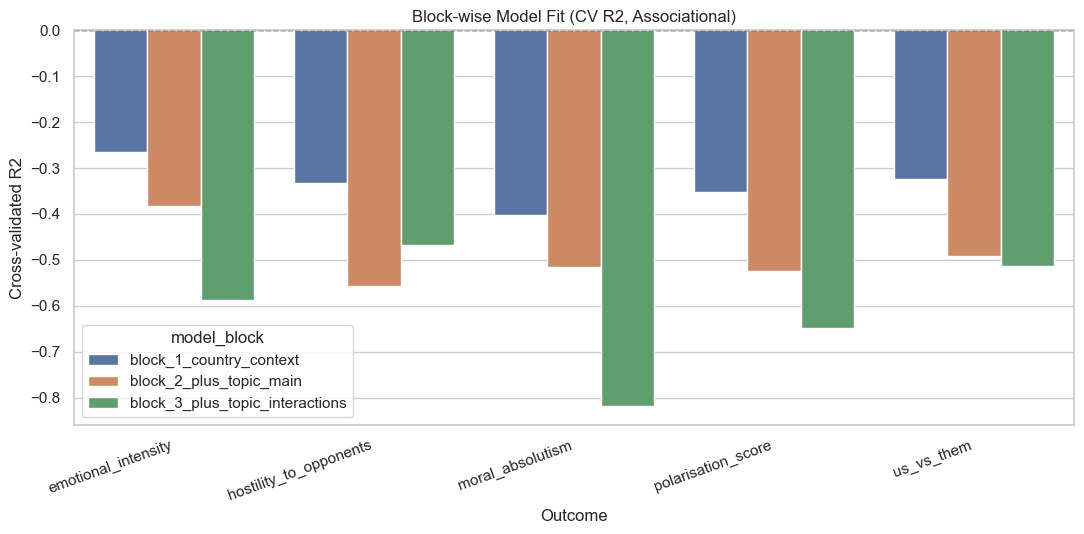

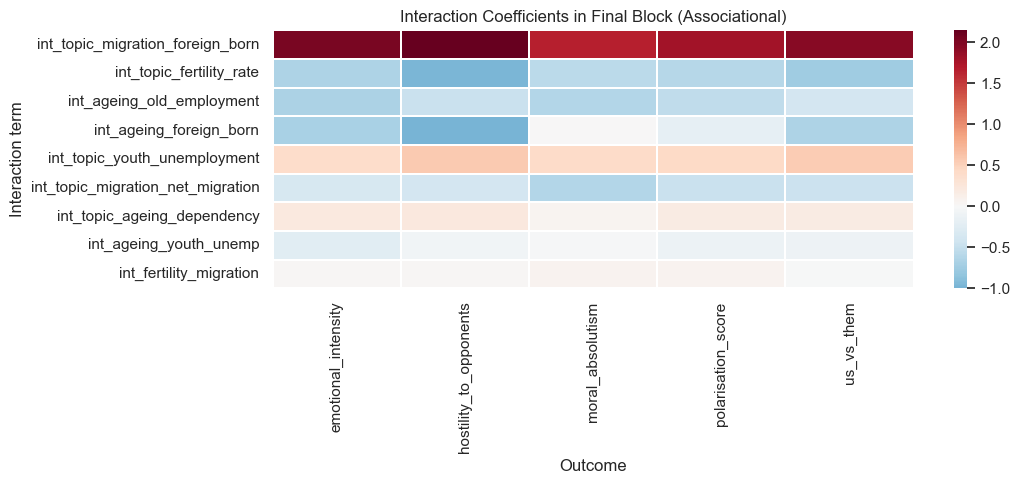

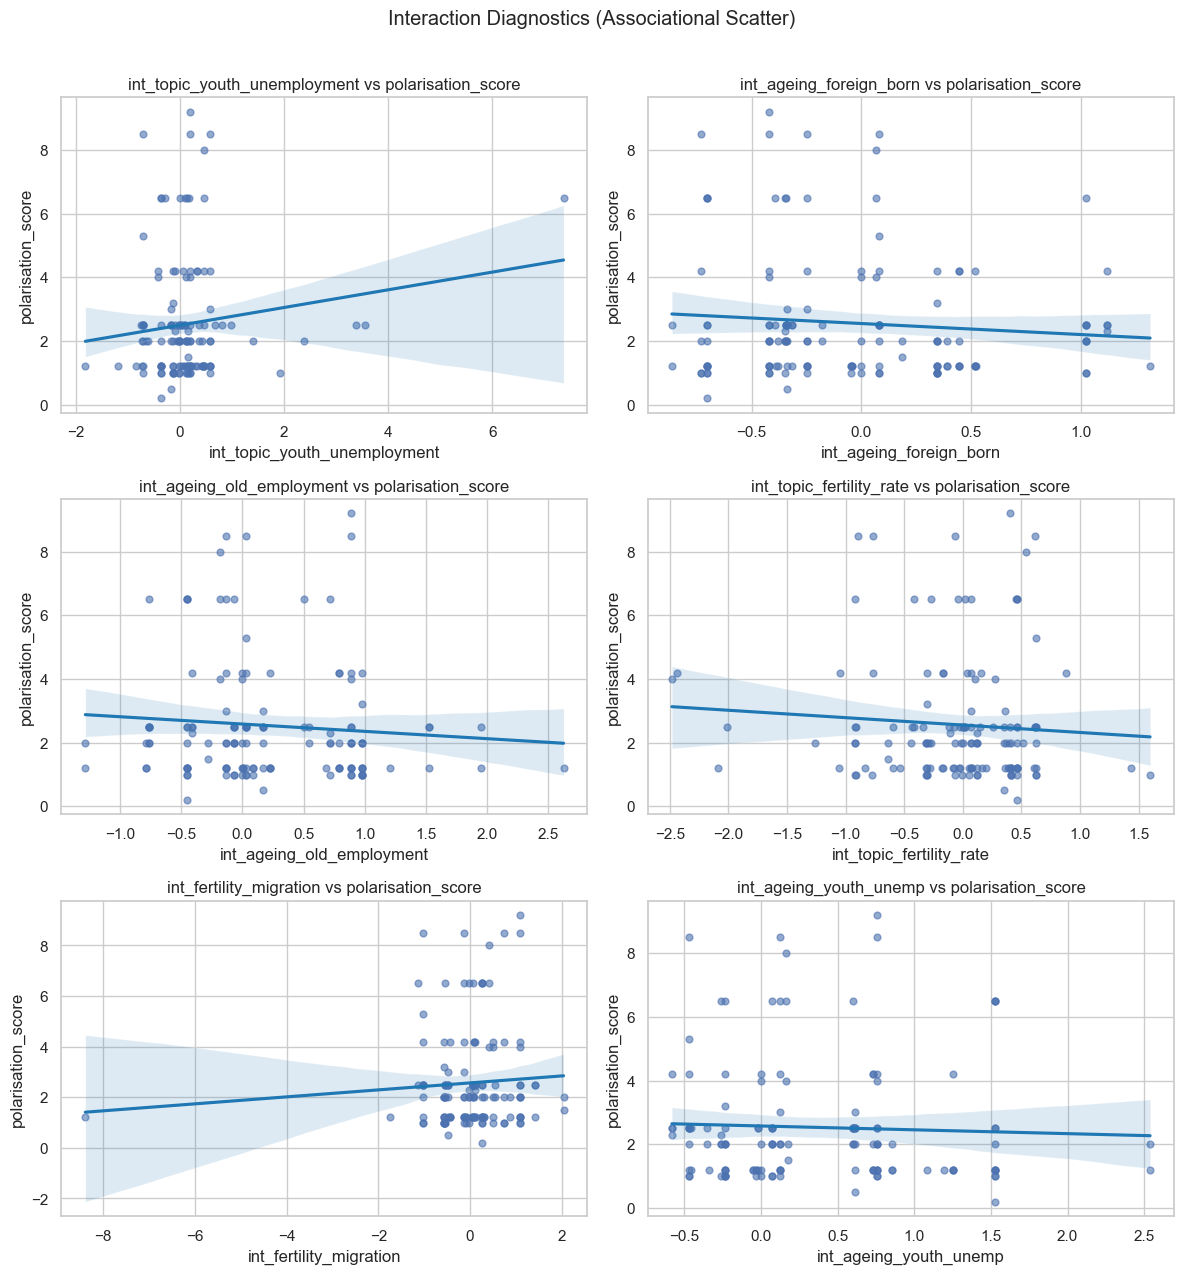

Saved figures: interaction_block_cv_r2.png, interaction_coefficients_heatmap.png, interaction_scatter_diagnostics.png


In [66]:
# Interaction diagnostics figures
if "interaction_block_summary" not in globals():
    raise RuntimeError("Run the interaction model block first.")

sns.set_theme(style="whitegrid", context="notebook")

# 1) CV R2 by block and outcome
plot_summary = interaction_block_summary.dropna(subset=["cv_r2_mean"]).copy()
if not plot_summary.empty:
    plt.figure(figsize=(11, 5.5))
    sns.barplot(
        data=plot_summary,
        x="outcome",
        y="cv_r2_mean",
        hue="model_block",
        errorbar=None,
    )
    plt.axhline(0.0, color="black", linestyle="--", linewidth=1)
    plt.title("Block-wise Model Fit (CV R2, Associational)")
    plt.xlabel("Outcome")
    plt.ylabel("Cross-validated R2")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "interaction_block_cv_r2.png", dpi=300, bbox_inches="tight")
    plt.show()

# 2) Heatmap of interaction coefficients in the final block
if "interaction_block_coefs" in globals() and not interaction_block_coefs.empty:
    heat_df = interaction_block_coefs[
        interaction_block_coefs["model_block"].eq("block_3_plus_topic_interactions")
    ].copy()
    if not heat_df.empty:
        heat_pivot = heat_df.pivot_table(
            index="feature",
            columns="outcome",
            values="coef",
            aggfunc="mean",
        )
        heat_pivot = heat_pivot.dropna(how="all")
        if not heat_pivot.empty:
            # Keep the most informative interactions for readability.
            order = heat_pivot.abs().mean(axis=1).sort_values(ascending=False).head(12).index
            heat_pivot = heat_pivot.loc[order]

            plt.figure(figsize=(11, max(5, 0.45 * len(heat_pivot))))
            sns.heatmap(heat_pivot, cmap="RdBu_r", center=0, linewidths=0.25)
            plt.title("Interaction Coefficients in Final Block (Associational)")
            plt.xlabel("Outcome")
            plt.ylabel("Interaction term")
            plt.tight_layout()
            plt.savefig(FIGURES_DIR / "interaction_coefficients_heatmap.png", dpi=300, bbox_inches="tight")
            plt.show()

# 3) Scatter diagnostics for top available interactions vs polarisation_score
if "polarisation_score" in analysis_df.columns and "interaction_creation_table" in globals():
    available_ints = interaction_creation_table.loc[
        interaction_creation_table["created"], "interaction"
    ].tolist()
    if available_ints:
        ranked = []
        for col in available_ints:
            pair = analysis_df[[col, "polarisation_score"]].copy()
            pair[col] = pd.to_numeric(pair[col], errors="coerce")
            pair["polarisation_score"] = pd.to_numeric(pair["polarisation_score"], errors="coerce")
            pair = pair.dropna()
            if len(pair) >= 20:
                corr = pair[col].corr(pair["polarisation_score"])
                ranked.append((col, abs(corr) if pd.notna(corr) else 0.0, len(pair)))

        top_interactions = [x[0] for x in sorted(ranked, key=lambda t: t[1], reverse=True)[:6]]
        if top_interactions:
            n = len(top_interactions)
            ncols = 2
            nrows = int(np.ceil(n / ncols))
            fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 4.2 * nrows), squeeze=False)
            axes_flat = axes.flatten()
            for i, inter_col in enumerate(top_interactions):
                pair = analysis_df[[inter_col, "polarisation_score"]].copy()
                pair[inter_col] = pd.to_numeric(pair[inter_col], errors="coerce")
                pair["polarisation_score"] = pd.to_numeric(pair["polarisation_score"], errors="coerce")
                pair = pair.dropna()
                ax = axes_flat[i]
                sns.regplot(data=pair, x=inter_col, y="polarisation_score", scatter_kws={"alpha": 0.6, "s": 24}, line_kws={"color": "#1f77b4"}, ax=ax)
                ax.set_title(f"{inter_col} vs polarisation_score")
                ax.set_xlabel(inter_col)
                ax.set_ylabel("polarisation_score")
            for j in range(n, len(axes_flat)):
                axes_flat[j].axis("off")
            fig.suptitle("Interaction Diagnostics (Associational Scatter)", y=1.01)
            fig.tight_layout()
            fig.savefig(FIGURES_DIR / "interaction_scatter_diagnostics.png", dpi=300, bbox_inches="tight")
            plt.show()

print("Saved figures: interaction_block_cv_r2.png, interaction_coefficients_heatmap.png, interaction_scatter_diagnostics.png")

## Exploratory interaction screening across polarisation and emotion outcomes

This section is exploratory and hypothesis-generating. The interaction heat maps screen many possible associations between topic emphasis, MEP characteristics, country context, and polarisation/emotion outcomes. These models are correlational and should not be interpreted as causal evidence. Because many interactions are tested, the heat maps are used to identify patterns for discussion rather than to confirm definitive effects.

c:\Users\Gebruiker\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:2014: RuntimeWarning: divide by zero encountered in divide
  self.het_scale = (self.wresid / (1 - h))**2
c:\Users\Gebruiker\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:2014: RuntimeWarning: divide by zero encountered in divide
  self.het_scale = (self.wresid / (1 - h))**2
c:\Users\Gebruiker\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:2014: RuntimeWarning: divide by zero encountered in divide
  self.het_scale = (self.wresid / (1 - h))**2
c:\Users\Gebruiker\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:2014: RuntimeWarning: divide by zero encountered in divide
  self.het_scale = (self.wresid / (1 - h))**2
c:\Users\Gebruiker\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:2014: RuntimeWarning: divide by zero encountered in divide
  self.het_scale = (self.wresid / (1 - h))**2
c:\Users\Gebruiker\anaconda3\Lib\site-package

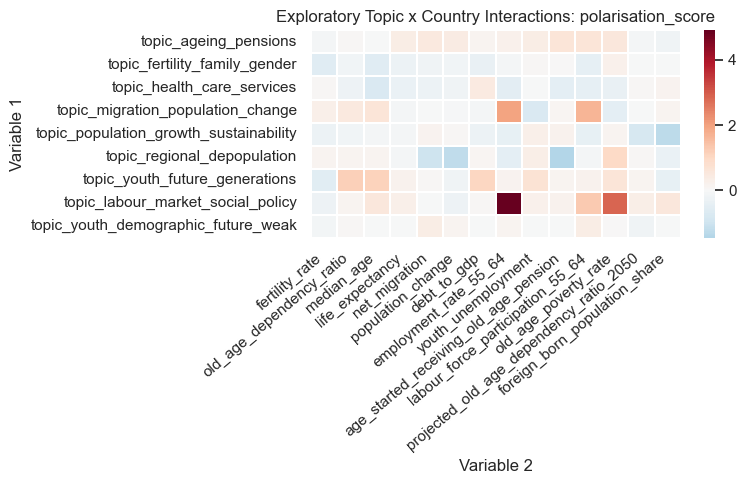

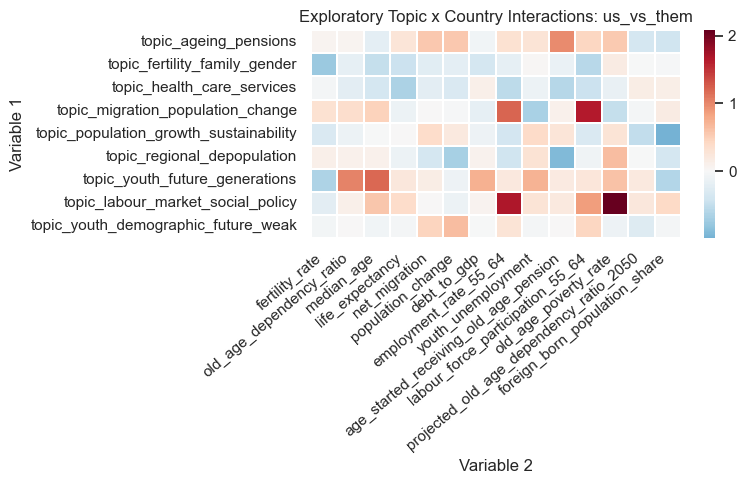

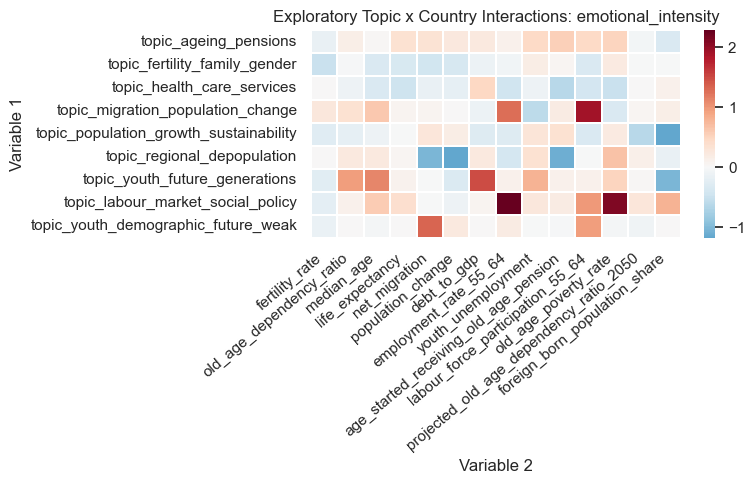

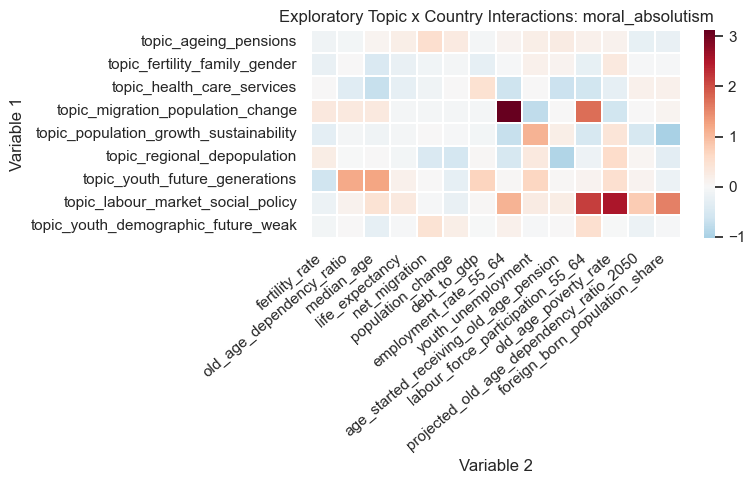

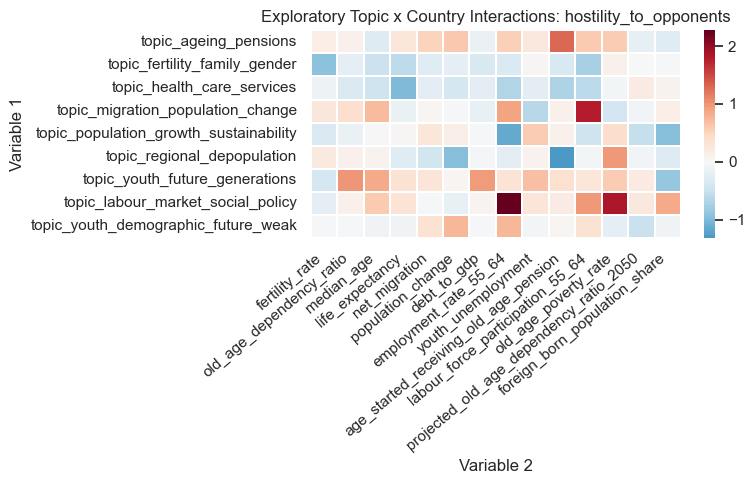

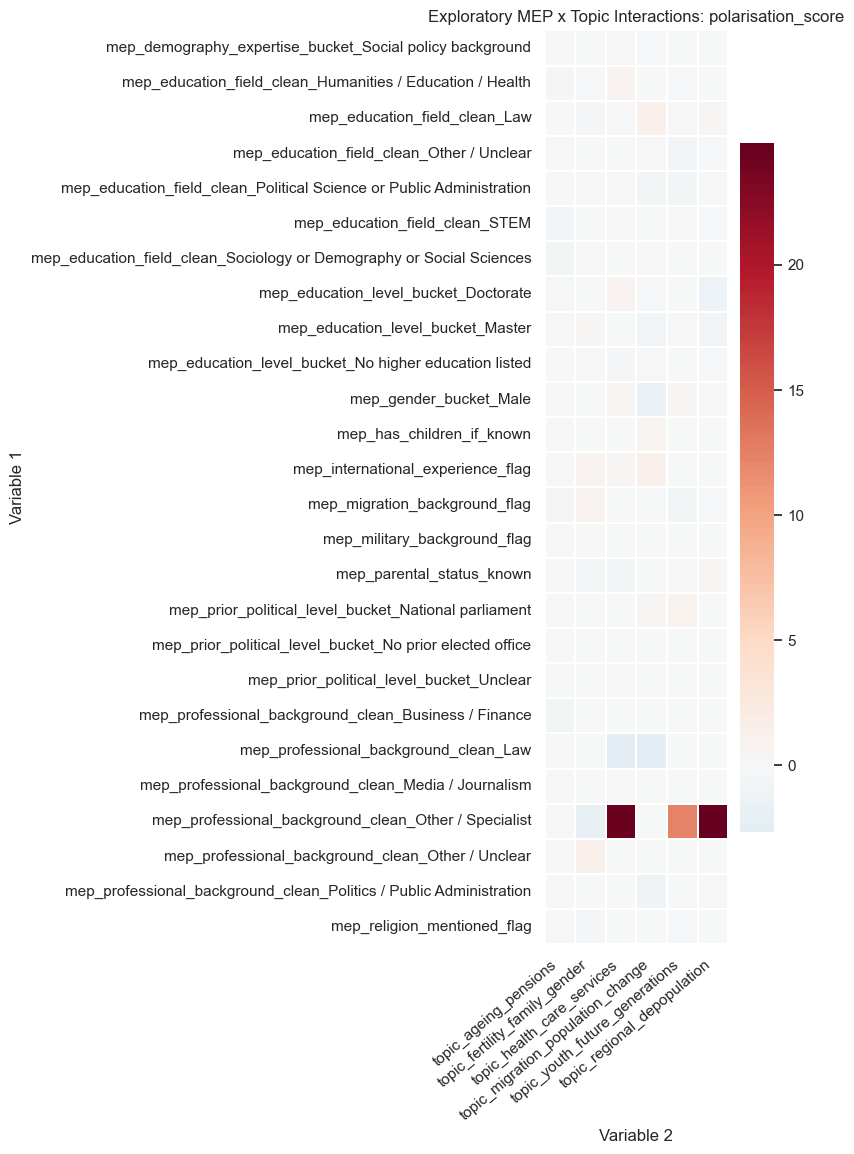

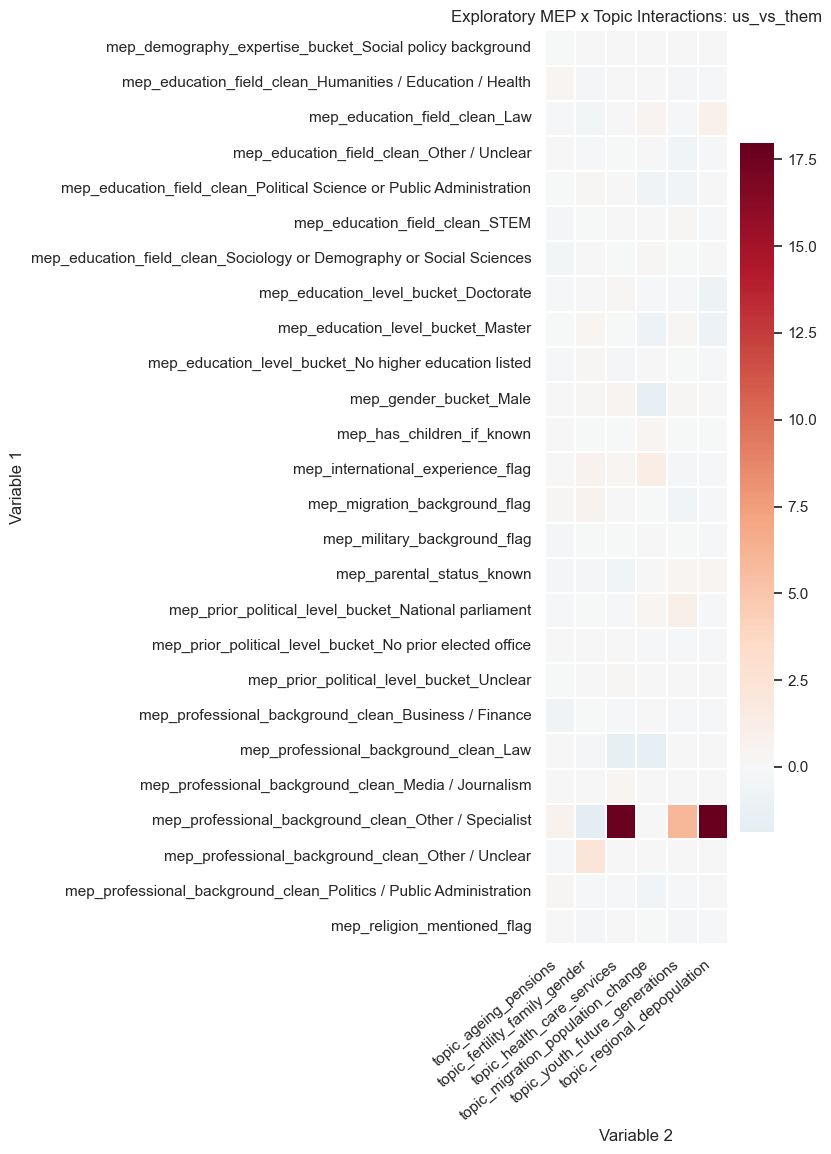

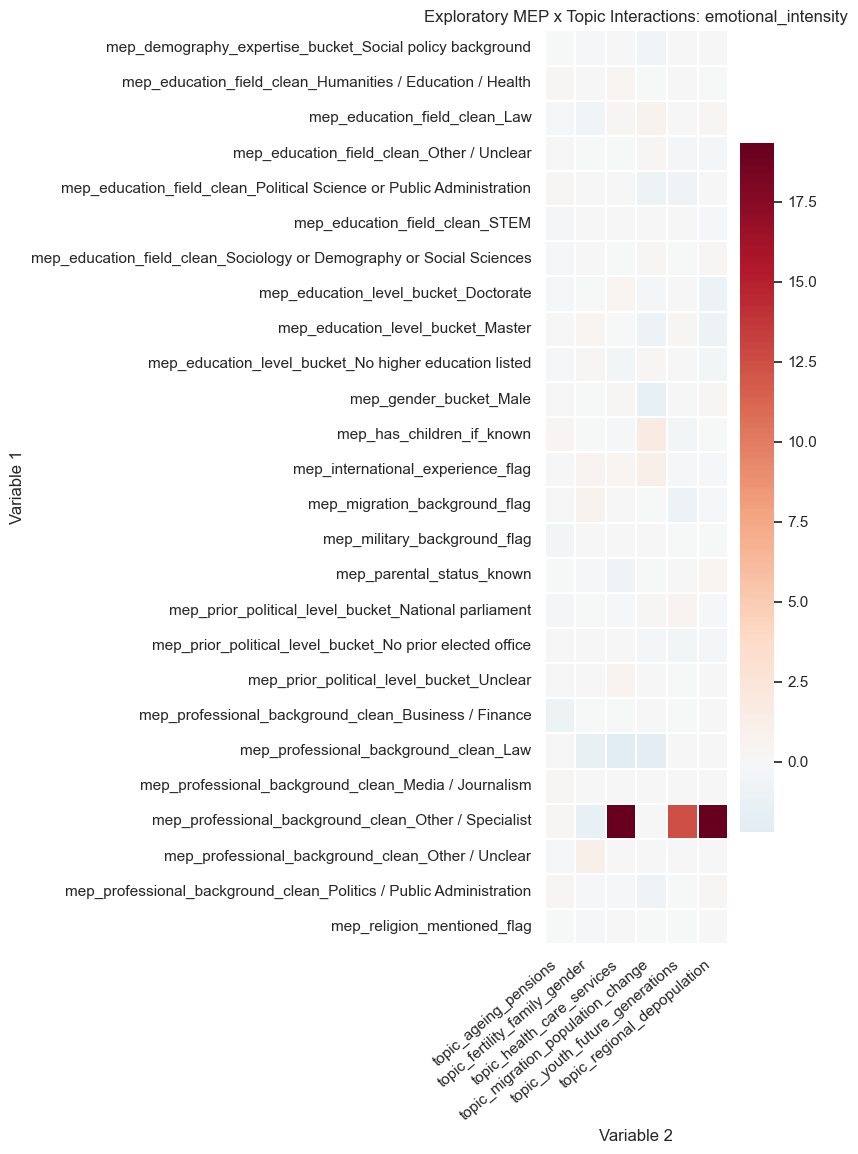

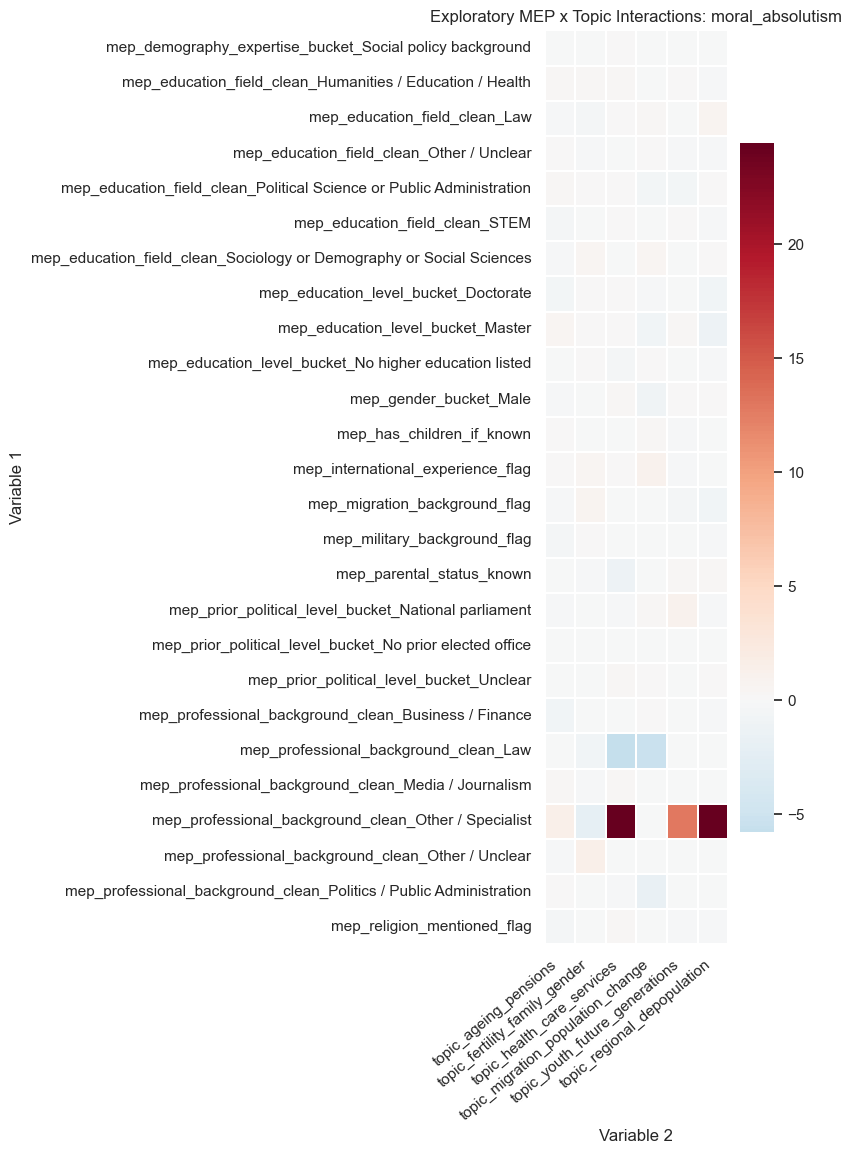

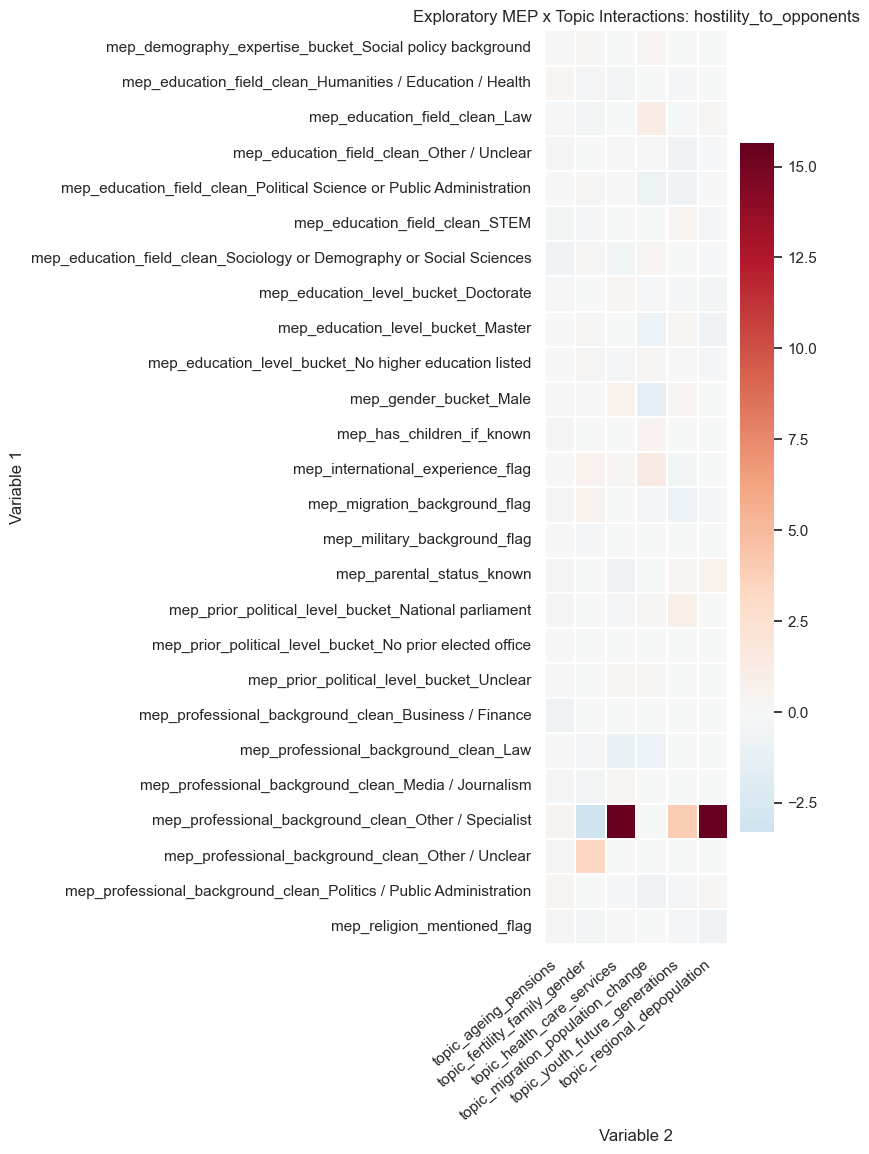

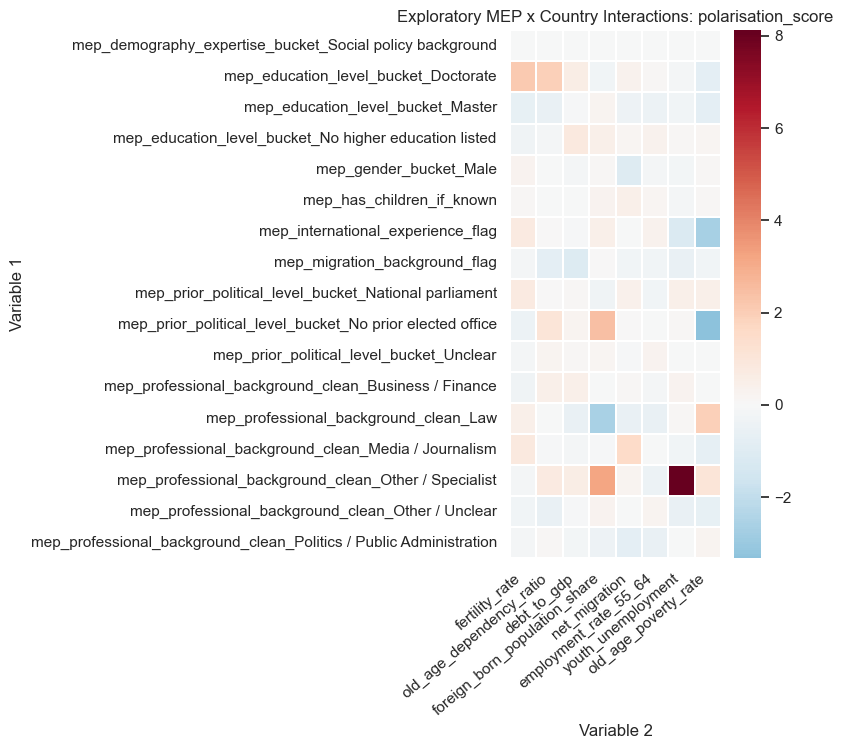

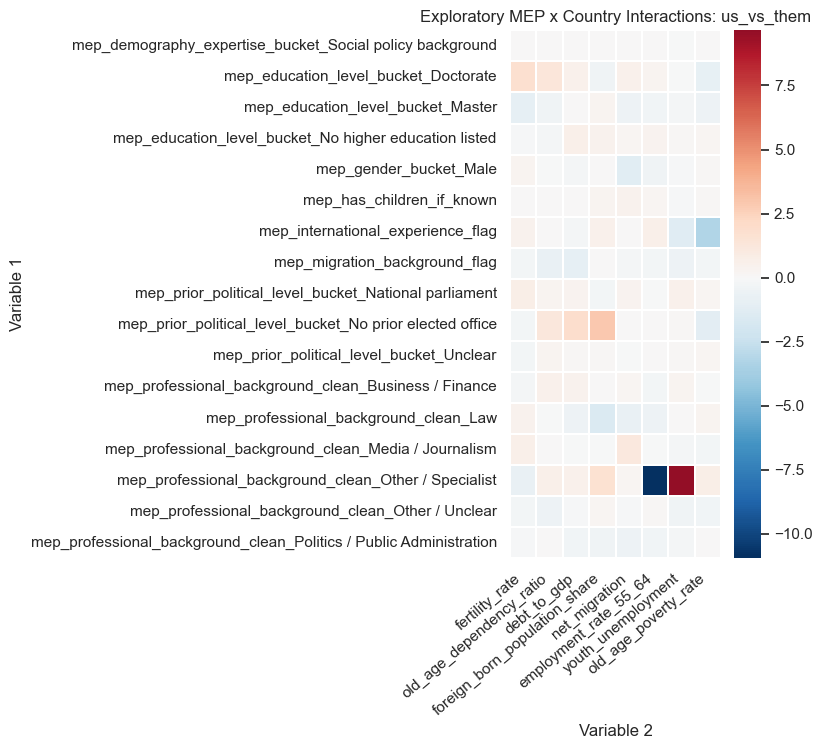

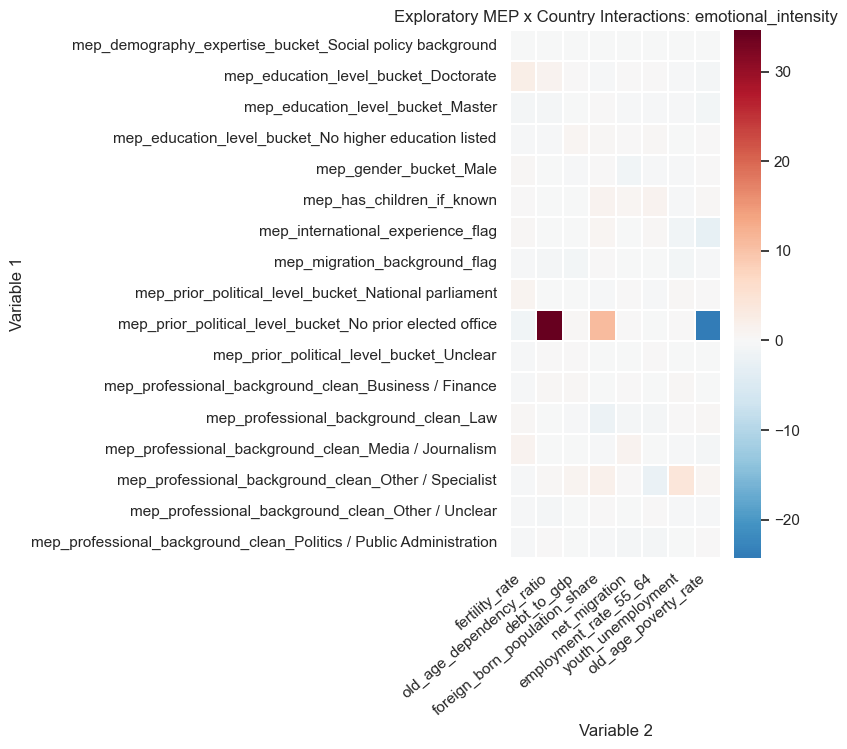

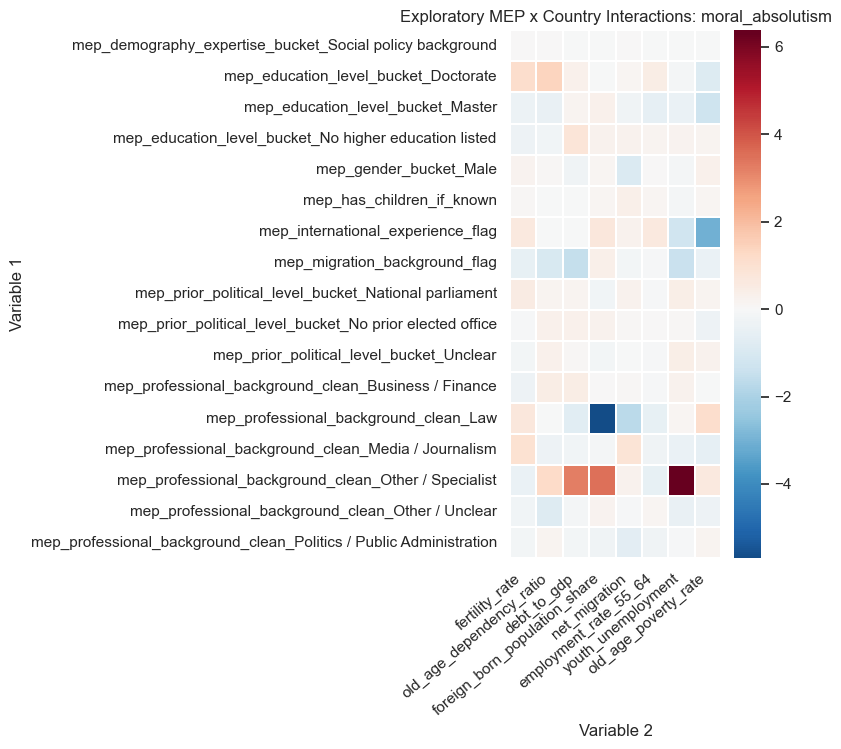

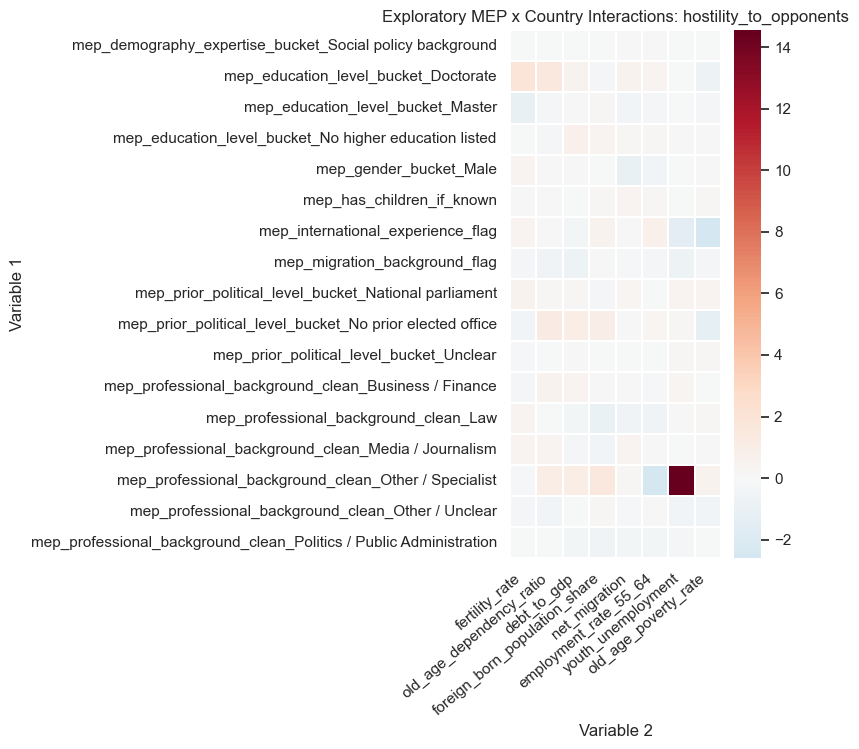

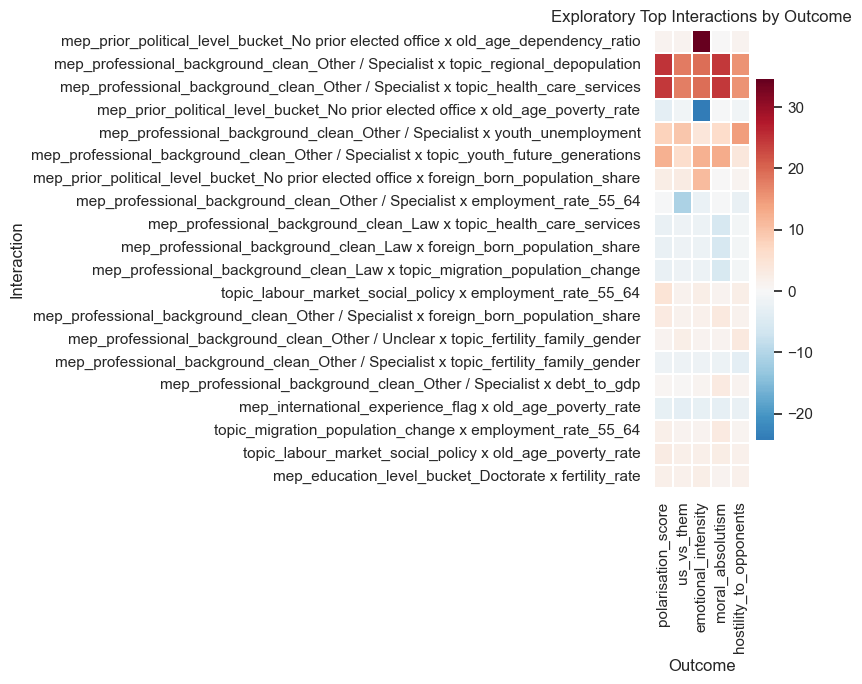

Exploratory screening complete (hypothesis-generating only).
Detected outcomes: ['polarisation_score', 'us_vs_them', 'emotional_intensity', 'moral_absolutism', 'hostility_to_opponents']
Attempted models: 2090
Successful models: 2090
Skipped/error models: 0


,outcome_variable,interaction_family,variable_1,variable_2,interaction_name,coefficient,standard_error,p_value,ci_lower,ci_upper,n_observations,adjusted_r2,model_status,warning,raw_significant_5pct,p_value_fdr,fdr_significant_10pct,exploratory_only,signed_score
0,polarisation_score,topic_x_country,topic_ageing_pensions,fertility_rate,topic_ageing_pensions x fertility_rate,-0.039651,0.184303,0.829660,-0.400878,0.321577,139,0.120336,ok,fixed effects skipped due limited sample size,False,1.0,False,True,-0.081100
1,polarisation_score,topic_x_country,topic_ageing_pensions,old_age_dependency_ratio,topic_ageing_pensions x old_age_dependency_ratio,0.031257,0.139872,0.823168,-0.242886,0.305401,139,0.120036,ok,fixed effects skipped due limited sample size,False,1.0,False,True,0.084512
2,polarisation_score,topic_x_country,topic_ageing_pensions,median_age,topic_ageing_pensions x median_age,-0.003641,0.142011,0.979547,-0.281978,0.274697,139,0.113985,ok,fixed effects skipped due limited sample size,False,1.0,False,True,-0.008975
3,polarisation_score,topic_x_country,topic_ageing_pensions,life_expectancy,topic_ageing_pensions x life_expectancy,0.149282,0.188764,0.429039,-0.220689,0.519252,139,0.121678,ok,fixed effects skipped due limited sample size,False,1.0,False,True,0.367504
4,polarisation_score,topic_x_country,topic_ageing_pensions,net_migration,topic_ageing_pensions x net_migration,0.242589,0.243051,0.318232,-0.233782,0.718960,139,0.122505,ok,fixed effects skipped due limited sample size,False,1.0,False,True,0.497256
5,polarisation_score,topic_x_country,topic_ageing_pensions,population_change,topic_ageing_pensions x population_change,0.159863,0.185875,0.389757,-0.204445,0.524171,139,0.118698,ok,fixed effects skipped due limited sample size,False,1.0,False,True,0.409207
6,polarisation_score,topic_x_country,topic_ageing_pensions,debt_to_gdp,topic_ageing_pensions x debt_to_gdp,0.058096,0.168748,0.730639,-0.272644,0.388835,134,0.131911,ok,fixed effects skipped due limited sample size,False,1.0,False,True,0.136297
7,polarisation_score,topic_x_country,topic_ageing_pensions,employment_rate_55_64,topic_ageing_pensions x employment_rate_55_64,0.094442,0.160876,0.557173,-0.220870,0.409754,134,0.137195,ok,fixed effects skipped due limited sample size,False,1.0,False,True,0.254010
8,polarisation_score,topic_x_country,topic_ageing_pensions,youth_unemployment,topic_ageing_pensions x youth_unemployment,0.252003,0.310873,0.417578,-0.357296,0.861302,134,0.150146,ok,fixed effects skipped due limited sample size,False,1.0,False,True,0.379263
9,polarisation_score,topic_x_country,topic_ageing_pensions,age_started_receiving_old_age_pension,topic_ageing_pensions x age_started_receiving_...,0.239366,0.199668,0.230598,-0.151976,0.630707,134,0.160006,ok,fixed effects skipped due limited sample size,False,1.0,False,True,0.637145


,interaction_family,interaction_name,outcome_variable,coefficient,p_value,p_value_fdr,signed_score,n_observations,interpretation_note
1681,topic_x_country,topic_ageing_pensions x age_started_receiving_...,hostility_to_opponents,0.397994,0.050151,0.911447,1.299717,134,"Exploratory, correlational interaction signal;..."
427,topic_x_country,topic_ageing_pensions x age_started_receiving_...,us_vs_them,0.344176,0.105133,1.000000,0.978262,134,"Exploratory, correlational interaction signal;..."
928,topic_x_country,topic_youth_future_generations x youth_unemplo...,emotional_intensity,0.307605,0.160946,1.000000,0.793319,134,"Exploratory, correlational interaction signal;..."
510,topic_x_country,topic_youth_future_generations x youth_unemplo...,us_vs_them,0.462079,0.188671,1.000000,0.724295,134,"Exploratory, correlational interaction signal;..."
92,topic_x_country,topic_youth_future_generations x youth_unemplo...,polarisation_score,0.328318,0.193823,1.000000,0.712595,134,"Exploratory, correlational interaction signal;..."
1764,topic_x_country,topic_youth_future_generations x youth_unemplo...,hostility_to_opponents,0.524233,0.207548,1.000000,0.682880,134,"Exploratory, correlational interaction signal;..."
1346,topic_x_country,topic_youth_future_generations x youth_unemplo...,moral_absolutism,0.344421,0.216296,1.000000,0.664952,134,"Exploratory, correlational interaction signal;..."
9,topic_x_country,topic_ageing_pensions x age_started_receiving_...,polarisation_score,0.239366,0.230598,1.000000,0.637145,134,"Exploratory, correlational interaction signal;..."
845,topic_x_country,topic_ageing_pensions x age_started_receiving_...,emotional_intensity,0.209030,0.287274,1.000000,0.541704,134,"Exploratory, correlational interaction signal;..."
1263,topic_x_country,topic_ageing_pensions x age_started_receiving_...,moral_absolutism,0.164276,0.562968,1.000000,0.249516,134,"Exploratory, correlational interaction signal;..."


In [ ]:
# Exploratory interaction screening (separate from main analysis).
# This block is intentionally hypothesis-generating and correlational.


if "analysis_df" not in globals():
    raise RuntimeError("analysis_df is missing. Run the main pipeline cells first.")

TABLES_DIR = globals().get("TABLES_DIR", Path.cwd() / "outputs" / "tables")
FIGURES_DIR = globals().get("FIGURES_DIR", Path.cwd() / "outputs" / "figures")
TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

expl_df = analysis_df.copy()

# --- Topic aliases (keep original columns, add code-friendly duplicates) ---
topic_alias_map = {
    "Ageing & Pensions": "topic_ageing_pensions",
    "Fertility, Families & Gender": "topic_fertility_family_gender",
    "Health & Care Services": "topic_health_care_services",
    "Migration & Population Change": "topic_migration_population_change",
    "Population Growth & Sustainability": "topic_population_growth_sustainability",
    "Regional Depopulation & Territorial Cohesion": "topic_regional_depopulation",
    "Youth & Future Generations": "topic_youth_future_generations",
    "Borderline: Labour market and social policy": "topic_labour_market_social_policy",
    "Borderline: Youth / demographic future (weak signal)": "topic_youth_demographic_future_weak",
}

expl_warnings = []
for original_col, alias_col in topic_alias_map.items():
    if original_col in expl_df.columns:
        expl_df[alias_col] = pd.to_numeric(expl_df[original_col], errors="coerce")
    else:
        expl_warnings.append(f"Missing topic column skipped: {original_col}")

# --- Outcome variables (confidence intentionally excluded as a main outcome) ---
outcome_candidates = [
    "polarisation_score",
    "us_vs_them",
    "emotional_intensity",
    "moral_absolutism",
    "hostility_to_opponents",
]
detected_outcomes = [c for c in outcome_candidates if c in expl_df.columns]

if not detected_outcomes:
    raise RuntimeError("No requested outcome variables available for exploratory screening.")

# --- Family variable lists ---
family1_topics = [
    "topic_ageing_pensions",
    "topic_fertility_family_gender",
    "topic_health_care_services",
    "topic_migration_population_change",
    "topic_population_growth_sustainability",
    "topic_regional_depopulation",
    "topic_youth_future_generations",
    "topic_labour_market_social_policy",
    "topic_youth_demographic_future_weak",
]

family1_country = [
    "fertility_rate",
    "old_age_dependency_ratio",
    "median_age",
    "life_expectancy",
    "net_migration",
    "population_change",
    "debt_to_gdp",
    "employment_rate_55_64",
    "youth_unemployment",
    "age_started_receiving_old_age_pension",
    "labour_force_participation_55_64",
    "old_age_poverty_rate",
    "projected_old_age_dependency_ratio_2050",
    "foreign_born_population_share",
]

family2_mep = [
    "gender_bucket",
    "education_level_bucket",
    "education_field_clean",
    "professional_background_clean",
    "migration_background_flag",
    "international_experience_flag",
    "military_background_flag",
    "parental_status_known",
    "has_children_if_known",
    "religion_mentioned_flag",
    "prior_political_level_bucket",
    "demography_expertise_bucket",
]

family2_topics = [
    "topic_ageing_pensions",
    "topic_fertility_family_gender",
    "topic_health_care_services",
    "topic_migration_population_change",
    "topic_youth_future_generations",
    "topic_regional_depopulation",
]

family3_mep = [
    "gender_bucket",
    "education_level_bucket",
    "professional_background_clean",
    "migration_background_flag",
    "international_experience_flag",
    "has_children_if_known",
    "prior_political_level_bucket",
    "demography_expertise_bucket",
]

family3_country = [
    "fertility_rate",
    "old_age_dependency_ratio",
    "debt_to_gdp",
    "foreign_born_population_share",
    "net_migration",
    "employment_rate_55_64",
    "youth_unemployment",
    "old_age_poverty_rate",
]

# --- Helpers ---
def _safe_slug(text: str) -> str:
    text = str(text).strip().lower()
    text = "".join(ch if (ch.isalnum() or ch == "_") else "_" for ch in text)
    while "__" in text:
        text = text.replace("__", "_")
    return text.strip("_") or "x"


def _to_binary_if_possible(series: pd.Series):
    s = series.copy()
    if pd.api.types.is_numeric_dtype(s):
        s_num = pd.to_numeric(s, errors="coerce")
        uniq = sorted([v for v in s_num.dropna().unique().tolist()])
        if len(uniq) == 2 and set(uniq).issubset({0, 1}):
            return s_num, True
        return s_num, False

    s_str = s.astype("string").str.strip().str.lower()
    map_dict = {
        "yes": 1, "y": 1, "true": 1, "1": 1,
        "no": 0, "n": 0, "false": 0, "0": 0,
    }
    mapped = s_str.map(map_dict)
    uniq = sorted([v for v in mapped.dropna().unique().tolist()])
    if len(uniq) == 2 and set(uniq).issubset({0, 1}):
        return mapped.astype(float), True
    return s, False


def _zscore(series: pd.Series) -> pd.Series:
    x = pd.to_numeric(series, errors="coerce")
    mu = x.mean(skipna=True)
    sd = x.std(skipna=True, ddof=0)
    if pd.isna(sd) or sd == 0:
        return x - mu
    return (x - mu) / sd


def _prepare_continuous_var(df: pd.DataFrame, col: str, missing_threshold: float = 0.75):
    if col not in df.columns:
        return None, f"missing column: {col}"
    x = pd.to_numeric(df[col], errors="coerce")
    miss = x.isna().mean()
    uniq = x.dropna().nunique()
    if miss > missing_threshold:
        return None, f"too much missingness ({miss:.2%}): {col}"
    if uniq < 2:
        return None, f"fewer than two unique values: {col}"
    z_col = f"z_{col}"
    df[z_col] = _zscore(x)
    return z_col, None


# Prepare standardized country/topic vars
continuous_candidates = sorted(set(family1_topics + family1_country + family3_country + [
    "n_relevant_speeches", "n_documents", "confidence"
]))

standardized_map = {}
for col in continuous_candidates:
    new_col, warn = _prepare_continuous_var(expl_df, col)
    if new_col is not None:
        standardized_map[col] = new_col
    elif warn is not None:
        expl_warnings.append(warn)

# Prepare MEP variables (binary keep; >2 categories to dummies, drop first)
mep_model_cols = {}
for mep_col in sorted(set(family2_mep + family3_mep)):
    if mep_col not in expl_df.columns:
        expl_warnings.append(f"missing MEP variable: {mep_col}")
        mep_model_cols[mep_col] = []
        continue

    raw = expl_df[mep_col]
    maybe_bin, is_binary = _to_binary_if_possible(raw)
    if is_binary:
        model_col = f"mep_{mep_col}"
        expl_df[model_col] = pd.to_numeric(maybe_bin, errors="coerce")
        if expl_df[model_col].dropna().nunique() >= 2:
            mep_model_cols[mep_col] = [model_col]
        else:
            mep_model_cols[mep_col] = []
            expl_warnings.append(f"binary MEP variable has <2 unique values: {mep_col}")
        continue

    cat = raw.astype("string").str.strip()
    cat = cat.replace({"": pd.NA, "nan": pd.NA, "None": pd.NA})
    nunique = cat.dropna().nunique()
    if nunique < 2:
        mep_model_cols[mep_col] = []
        expl_warnings.append(f"categorical MEP variable has <2 unique values: {mep_col}")
        continue

    dummies = pd.get_dummies(cat, prefix=f"mep_{mep_col}", drop_first=True, dtype=float)
    if dummies.shape[1] == 0:
        mep_model_cols[mep_col] = []
        expl_warnings.append(f"no dummies created (drop_first) for: {mep_col}")
        continue

    expl_df = pd.concat([expl_df, dummies], axis=1)
    mep_model_cols[mep_col] = dummies.columns.tolist()

# Controls (continuous standardized controls, plus optional confidence)
control_cols = [c for c in [
    standardized_map.get("n_relevant_speeches"),
    standardized_map.get("n_documents"),
    standardized_map.get("confidence"),
] if c is not None]

# Optional fixed effects columns
fe_candidates = [c for c in ["country_clean_final", "ep_group_clean"] if c in expl_df.columns]


# --- Regression engine ---
def _fit_single_interaction(
    df: pd.DataFrame,
    outcome: str,
    x1_col: str,
    x2_col: str,
    interaction_family: str,
    var1_label: str,
    var2_label: str,
    min_n: int = 35,
):
    warning_msgs = []

    use_cols = [outcome, x1_col, x2_col] + control_cols + fe_candidates
    work = df[use_cols].copy()
    work[outcome] = pd.to_numeric(work[outcome], errors="coerce")

    # Ensure x terms are numeric where possible.
    work[x1_col] = pd.to_numeric(work[x1_col], errors="coerce")
    work[x2_col] = pd.to_numeric(work[x2_col], errors="coerce")

    # FE kept as categorical strings.
    for fe_col in fe_candidates:
        work[fe_col] = work[fe_col].astype("string").str.strip()
        work[fe_col] = work[fe_col].replace({"": pd.NA, "nan": pd.NA, "None": pd.NA})

    work = work.dropna(subset=[outcome, x1_col, x2_col] + control_cols)

    if work.shape[0] < min_n:
        return {
            "outcome_variable": outcome,
            "interaction_family": interaction_family,
            "variable_1": var1_label,
            "variable_2": var2_label,
            "interaction_name": f"{var1_label} x {var2_label}",
            "coefficient": np.nan,
            "standard_error": np.nan,
            "p_value": np.nan,
            "ci_lower": np.nan,
            "ci_upper": np.nan,
            "n_observations": int(work.shape[0]),
            "adjusted_r2": np.nan,
            "model_status": "skipped",
            "warning": f"too few observations (<{min_n})",
        }

    X = work[[x1_col, x2_col] + control_cols].copy()
    inter_col = f"int__{_safe_slug(x1_col)}__{_safe_slug(x2_col)}"
    X[inter_col] = X[x1_col] * X[x2_col]

    # Optional FE if stable (enough rows per dummy burden)
    fe_used = []
    if fe_candidates:
        fe_dummies_all = []
        for fe_col in fe_candidates:
            valid_fe = work[fe_col].dropna().nunique()
            if valid_fe >= 2:
                d = pd.get_dummies(work[fe_col], prefix=f"fe_{fe_col}", drop_first=True, dtype=float)
                if d.shape[1] > 0:
                    fe_dummies_all.append(d)
        if fe_dummies_all:
            fe_mat = pd.concat(fe_dummies_all, axis=1)
            prospective_k = X.shape[1] + fe_mat.shape[1] + 1
            if work.shape[0] >= max(45, 4 * prospective_k):
                X = pd.concat([X, fe_mat], axis=1)
                fe_used = fe_mat.columns.tolist()
            else:
                warning_msgs.append("fixed effects skipped due limited sample size")

    # Final complete-case matrix
    model_df = pd.concat([work[[outcome]], X], axis=1).dropna()
    n_obs = int(model_df.shape[0])

    if n_obs < min_n:
        return {
            "outcome_variable": outcome,
            "interaction_family": interaction_family,
            "variable_1": var1_label,
            "variable_2": var2_label,
            "interaction_name": f"{var1_label} x {var2_label}",
            "coefficient": np.nan,
            "standard_error": np.nan,
            "p_value": np.nan,
            "ci_lower": np.nan,
            "ci_upper": np.nan,
            "n_observations": n_obs,
            "adjusted_r2": np.nan,
            "model_status": "skipped",
            "warning": "too few complete cases after controls/FE",
        }

    y = model_df[outcome]
    X_model = sm.add_constant(model_df.drop(columns=[outcome]), has_constant="add")

    try:
        fit = sm.OLS(y, X_model).fit(cov_type="HC3")
        if inter_col not in fit.params.index:
            return {
                "outcome_variable": outcome,
                "interaction_family": interaction_family,
                "variable_1": var1_label,
                "variable_2": var2_label,
                "interaction_name": f"{var1_label} x {var2_label}",
                "coefficient": np.nan,
                "standard_error": np.nan,
                "p_value": np.nan,
                "ci_lower": np.nan,
                "ci_upper": np.nan,
                "n_observations": n_obs,
                "adjusted_r2": float(fit.rsquared_adj) if np.isfinite(fit.rsquared_adj) else np.nan,
                "model_status": "error",
                "warning": "interaction term dropped/singular",
            }

        ci = fit.conf_int().loc[inter_col]
        if fe_used:
            warning_msgs.append("fixed effects included")

        return {
            "outcome_variable": outcome,
            "interaction_family": interaction_family,
            "variable_1": var1_label,
            "variable_2": var2_label,
            "interaction_name": f"{var1_label} x {var2_label}",
            "coefficient": float(fit.params[inter_col]),
            "standard_error": float(fit.bse[inter_col]),
            "p_value": float(fit.pvalues[inter_col]),
            "ci_lower": float(ci.iloc[0]),
            "ci_upper": float(ci.iloc[1]),
            "n_observations": n_obs,
            "adjusted_r2": float(fit.rsquared_adj) if np.isfinite(fit.rsquared_adj) else np.nan,
            "model_status": "ok",
            "warning": " | ".join(warning_msgs) if warning_msgs else "",
        }
    except Exception as ex:
        return {
            "outcome_variable": outcome,
            "interaction_family": interaction_family,
            "variable_1": var1_label,
            "variable_2": var2_label,
            "interaction_name": f"{var1_label} x {var2_label}",
            "coefficient": np.nan,
            "standard_error": np.nan,
            "p_value": np.nan,
            "ci_lower": np.nan,
            "ci_upper": np.nan,
            "n_observations": n_obs,
            "adjusted_r2": np.nan,
            "model_status": "error",
            "warning": f"model error: {str(ex)[:180]}",
        }


# --- Build interaction attempts ---
attempt_specs = []

# Family 1: topic x country
for t in family1_topics:
    t_col = standardized_map.get(t)
    if t_col is None:
        continue
    for c in family1_country:
        c_col = standardized_map.get(c)
        if c_col is None:
            continue
        attempt_specs.append(("topic_x_country", t, c, t_col, c_col))

# Family 2: mep background x topic
for m in family2_mep:
    m_cols = mep_model_cols.get(m, [])
    if not m_cols:
        continue
    for t in family2_topics:
        t_col = standardized_map.get(t)
        if t_col is None:
            continue
        for mc in m_cols:
            attempt_specs.append(("mep_x_topic", mc, t, mc, t_col))

# Family 3: mep background x country
for m in family3_mep:
    m_cols = mep_model_cols.get(m, [])
    if not m_cols:
        continue
    for c in family3_country:
        c_col = standardized_map.get(c)
        if c_col is None:
            continue
        for mc in m_cols:
            attempt_specs.append(("mep_x_country", mc, c, mc, c_col))

# --- Run all models (one interaction per model per outcome) ---
rows = []
for out in detected_outcomes:
    for fam, v1_label, v2_label, x1_col, x2_col in attempt_specs:
        rows.append(_fit_single_interaction(
            df=expl_df,
            outcome=out,
            x1_col=x1_col,
            x2_col=x2_col,
            interaction_family=fam,
            var1_label=v1_label,
            var2_label=v2_label,
        ))

results_df = pd.DataFrame(rows)

# Multiple-testing diagnostics
results_df["raw_significant_5pct"] = results_df["p_value"].lt(0.05)
results_df["p_value_fdr"] = np.nan
results_df["fdr_significant_10pct"] = False

mask_ok = results_df["p_value"].notna() & results_df["model_status"].eq("ok")
if mask_ok.any():
    _, p_adj, _, _ = multipletests(results_df.loc[mask_ok, "p_value"].values, alpha=0.10, method="fdr_bh")
    results_df.loc[mask_ok, "p_value_fdr"] = p_adj
    results_df.loc[mask_ok, "fdr_significant_10pct"] = results_df.loc[mask_ok, "p_value_fdr"].lt(0.10)

results_df["exploratory_only"] = True

# Signed interaction score: sign(coef) * -log10(p)
safe_p = pd.to_numeric(results_df["p_value"], errors="coerce").clip(lower=1e-300)
results_df["signed_score"] = np.sign(pd.to_numeric(results_df["coefficient"], errors="coerce")) * (-np.log10(safe_p))
results_df.loc[results_df["coefficient"].isna() | results_df["p_value"].isna(), "signed_score"] = np.nan

# Save full results
all_outcomes_path = TABLES_DIR / "exploratory_interaction_screening_all_outcomes.csv"
results_df.to_csv(all_outcomes_path, index=False)

# --- Heatmaps ---
sns.set_theme(style="white", context="notebook")

figure_paths = []


def _save_heatmap(df_sub, rows_order, cols_order, title, out_path):
    if df_sub.empty:
        return False
    piv = df_sub.pivot_table(index="variable_1", columns="variable_2", values="signed_score", aggfunc="mean")
    # Keep intended order where present
    r_keep = [r for r in rows_order if r in piv.index]
    c_keep = [c for c in cols_order if c in piv.columns]
    if not r_keep or not c_keep:
        return False
    piv = piv.loc[r_keep, c_keep]
    if piv.dropna(how="all").empty:
        return False

    plt.figure(figsize=(max(8, 0.55 * len(c_keep)), max(5, 0.45 * len(r_keep))))
    sns.heatmap(piv, cmap="RdBu_r", center=0, linewidths=0.25)
    plt.title(title)
    plt.xlabel("Variable 2")
    plt.ylabel("Variable 1")
    plt.xticks(rotation=40, ha="right")
    plt.tight_layout()
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    figure_paths.append(str(out_path))
    return True


# Compact outcome slugs
outcome_short = {
    "polarisation_score": "pol",
    "us_vs_them": "uvt",
    "emotional_intensity": "emo",
    "moral_absolutism": "mor",
    "hostility_to_opponents": "hos",
}

# Family 1 heatmaps
for out in detected_outcomes:
    sub = results_df[(results_df["outcome_variable"] == out) & (results_df["interaction_family"] == "topic_x_country") & (results_df["model_status"] == "ok")]
    fname = f"expl_hm_tc_{outcome_short.get(out, _safe_slug(out)[:4])}.png"
    _save_heatmap(
        sub,
        rows_order=family1_topics,
        cols_order=family1_country,
        title=f"Exploratory Topic x Country Interactions: {out}",
        out_path=FIGURES_DIR / fname,
    )

# Family 2 heatmaps (rows may be dummies)
fam2_rows = sorted(results_df.loc[results_df["interaction_family"].eq("mep_x_topic"), "variable_1"].dropna().unique().tolist())
for out in detected_outcomes:
    sub = results_df[(results_df["outcome_variable"] == out) & (results_df["interaction_family"] == "mep_x_topic") & (results_df["model_status"] == "ok")]
    fname = f"expl_hm_mt_{outcome_short.get(out, _safe_slug(out)[:4])}.png"
    _save_heatmap(
        sub,
        rows_order=fam2_rows,
        cols_order=family2_topics,
        title=f"Exploratory MEP x Topic Interactions: {out}",
        out_path=FIGURES_DIR / fname,
    )

# Family 3 heatmaps (rows may be dummies)
fam3_rows = sorted(results_df.loc[results_df["interaction_family"].eq("mep_x_country"), "variable_1"].dropna().unique().tolist())
for out in detected_outcomes:
    sub = results_df[(results_df["outcome_variable"] == out) & (results_df["interaction_family"] == "mep_x_country") & (results_df["model_status"] == "ok")]
    fname = f"expl_hm_mc_{outcome_short.get(out, _safe_slug(out)[:4])}.png"
    _save_heatmap(
        sub,
        rows_order=fam3_rows,
        cols_order=family3_country,
        title=f"Exploratory MEP x Country Interactions: {out}",
        out_path=FIGURES_DIR / fname,
    )

# Outcome-comparison heatmap (top 20 by absolute signed_score across outcomes)
ok_scores = results_df[results_df["model_status"].eq("ok")].copy()
if not ok_scores.empty:
    agg = ok_scores.groupby("interaction_name", as_index=False)["signed_score"].apply(lambda s: np.nanmax(np.abs(s.values)) if s.notna().any() else np.nan)
    agg = agg.rename(columns={"signed_score": "max_abs_signed_score"}).sort_values("max_abs_signed_score", ascending=False)
    top20_names = agg["interaction_name"].head(20).tolist()

    top_by_outcome = ok_scores[ok_scores["interaction_name"].isin(top20_names)].copy()
    top_by_outcome_tbl = top_by_outcome[[
        "interaction_family", "interaction_name", "outcome_variable", "coefficient", "p_value", "p_value_fdr", "signed_score", "n_observations"
    ]].sort_values(["interaction_name", "outcome_variable"])
    top_by_outcome_path = TABLES_DIR / "exploratory_top_interactions_by_outcome.csv"
    top_by_outcome_tbl.to_csv(top_by_outcome_path, index=False)

    piv = top_by_outcome.pivot_table(index="interaction_name", columns="outcome_variable", values="signed_score", aggfunc="mean")
    # Keep top20 order and present outcomes
    keep_rows = [r for r in top20_names if r in piv.index]
    keep_cols = [c for c in detected_outcomes if c in piv.columns]
    if keep_rows and keep_cols:
        piv = piv.loc[keep_rows, keep_cols]
        plt.figure(figsize=(max(8, 1.2 * len(keep_cols)), max(6, 0.35 * len(keep_rows))))
        sns.heatmap(piv, cmap="RdBu_r", center=0, linewidths=0.25)
        plt.title("Exploratory Top Interactions by Outcome")
        plt.xlabel("Outcome")
        plt.ylabel("Interaction")
        plt.tight_layout()
        top_hm_path = FIGURES_DIR / "expl_hm_top_by_out.png"
        plt.savefig(top_hm_path, dpi=300, bbox_inches="tight")
        plt.show()
        figure_paths.append(str(top_hm_path))
else:
    top_by_outcome_tbl = pd.DataFrame(columns=[
        "interaction_family", "interaction_name", "outcome_variable", "coefficient", "p_value", "p_value_fdr", "signed_score", "n_observations"
    ])
    top_by_outcome_path = TABLES_DIR / "exploratory_top_interactions_by_outcome.csv"
    top_by_outcome_tbl.to_csv(top_by_outcome_path, index=False)

# Ranked top interactions table with prioritisation
priority_pairs = [
    "topic_ageing_pensions x old_age_dependency_ratio",
    "topic_ageing_pensions x age_started_receiving_old_age_pension",
    "topic_ageing_pensions x projected_old_age_dependency_ratio_2050",
    "topic_migration_population_change x foreign_born_population_share",
    "topic_migration_population_change x net_migration",
    "topic_fertility_family_gender x fertility_rate",
    "topic_youth_future_generations x youth_unemployment",
    "mep_migration_background_flag x topic_migration_population_change",
    "mep_has_children_if_known x topic_fertility_family_gender",
    "demography_expertise_bucket x topic_ageing_pensions",
]

ranked = results_df[results_df["model_status"].eq("ok")].copy()
ranked["priority_flag"] = ranked["interaction_name"].isin(priority_pairs)
ranked = ranked.sort_values(["priority_flag", "signed_score"], ascending=[False, False])
ranked = ranked[[
    "interaction_family",
    "interaction_name",
    "outcome_variable",
    "coefficient",
    "p_value",
    "p_value_fdr",
    "signed_score",
    "n_observations",
]].head(120)
ranked["interpretation_note"] = "Exploratory, correlational interaction signal; not causal evidence."

ranked_path = TABLES_DIR / "exploratory_top_interactions_ranked.csv"
ranked.to_csv(ranked_path, index=False)

# Store summary objects for final print cell
exploratory_summary = {
    "detected_outcomes": detected_outcomes,
    "n_attempted_models": int(len(rows)),
    "n_successful_models": int(results_df["model_status"].eq("ok").sum()),
    "n_skipped_models": int(results_df["model_status"].isin(["skipped", "error"]).sum()),
    "tables_saved": [
        str(all_outcomes_path),
        str(top_by_outcome_path),
        str(ranked_path),
    ],
    "figures_saved": figure_paths,
    "warnings": expl_warnings,
}

# Display small diagnostics previews
print("Exploratory screening complete (hypothesis-generating only).")
print("Detected outcomes:", detected_outcomes)
print("Attempted models:", exploratory_summary["n_attempted_models"])
print("Successful models:", exploratory_summary["n_successful_models"])
print("Skipped/error models:", exploratory_summary["n_skipped_models"])

if expl_warnings:
    print("\nWarnings (first 20):")
    for w in expl_warnings[:20]:
        print("-", w)

display(results_df.head(10))
display(ranked.head(15))

Interpretation notes for the exploratory heat maps:

- Positive signed scores indicate positive interaction coefficients with stronger statistical signal.
- Negative signed scores indicate negative interaction coefficients with stronger statistical signal.
- Values near zero indicate weak or no evidence.
- FDR-adjusted p-values are included because many interactions are screened.
- Only theoretically meaningful and robust interactions should be discussed in the paper.

In [ ]:
# Concise exploratory section summary (final requirement)
if "exploratory_summary" not in globals():
    raise RuntimeError("exploratory_summary is missing. Run the exploratory screening cell above first.")

print("Detected outcome variables:", exploratory_summary.get("detected_outcomes", []))
print("Number of interactions attempted:", exploratory_summary.get("n_attempted_models", 0))
print("Number of successful models:", exploratory_summary.get("n_successful_models", 0))
print("Number of skipped models:", exploratory_summary.get("n_skipped_models", 0))
print("Output tables saved:")
for p in exploratory_summary.get("tables_saved", []):
    print("-", p)
print("Output figures saved:")
for p in exploratory_summary.get("figures_saved", []):
    print("-", p)
print("Warning: results are exploratory and hypothesis-generating, not causal evidence.")